# Typology-Guided Multilingual Image Captioning — O2 FiLM Notebook
## Setup and Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Paths
Update the variables below if your Drive structure differs.

In [ ]:
import os

# ── Root ──────────────────────────────────────────────────────────────────────
DRIVE_ROOT    = "/content/drive/MyDrive/MLP Project/MLP Group"

# ── Project directories ───────────────────────────────────────────────────────
PROJECT_DIR   = f"{DRIVE_ROOT}/mlp_project"
DATASET_DIR   = f"{PROJECT_DIR}/datasets"
CHECKPOINT_DIR = f"{DRIVE_ROOT}/checkpoints"
XM3600_DIR    = f"{PROJECT_DIR}/xm3600"

# ── Feature files ─────────────────────────────────────────────────────────────
MULTILINGUAL_FEATURES = f"{PROJECT_DIR}/multilingual_features.pt"
XM3600_FEATURES       = f"{PROJECT_DIR}/xm3600_features.pt"

# ── Checkpoints ───────────────────────────────────────────────────────────────
CKPT_O1       = f"{CHECKPOINT_DIR}/best_multilingual.pt"       # O1 lang_embedding
CKPT_O2       = f"{CHECKPOINT_DIR}/best_multilingual_film.pt"  # O2 FiLM

# ── Prediction subsets (for length truncation experiment) ─────────────────────
O1_PREDS_FILE = f"{CHECKPOINT_DIR}/o1_preds_subset.json"
O2_PREDS_FILE = f"{CHECKPOINT_DIR}/o2_preds_subset.json"

# ── Azerbaijani custom dataset ────────────────────────────────────────────────
# Update path if loading from Kaggle input instead
AZ_CSV        = f"{DATASET_DIR}/xm3600_azerbaijani_full_checked.csv"

In [ ]:
import json, os
import pandas as pd

base = DATASET_DIR

results = []

# Turkish
with open(f"{base}/turkish/tasviret8k_captions.json", "r", encoding="utf-8") as f:
    data = json.load(f)
results.append(("Turkish", len(data["images"]), sum(len(img["sentences"]) for img in data["images"]), "Flickr8k"))

# Arabic
with open(f"{base}/arabic/Flickr8k.arabic.full.txt", "r", encoding="utf-8") as f:
    lines = [l.strip() for l in f if l.strip()]
ar_files = set(l.split("\t")[0].split("#")[0] for l in lines if "\t" in l)
results.append(("Arabic", len(ar_files), len(lines), "Flickr8k"))

# Bengali
df = pd.read_csv(f"{base}/bengali/BAN-Cap_captiondata.csv")
bn_files = set(df["caption_id"].apply(lambda x: x.split("#")[0]))
results.append(("Bengali", len(bn_files), len(df), "Flickr8k"))

# English
en_total = 0
for split in ["train", "val", "test"]:
    with open(f"{base}/english/{split}.en", "r") as f:
        en_total += len(f.readlines())
results.append(("English", "~31K (Flickr30k)", en_total, "Flickr30k"))

# German
de_total = 0
for split in ["train", "val", "test"]:
    with open(f"{base}/german/{split}.de", "r") as f:
        de_total += len(f.readlines())
results.append(("German", "~31K (Flickr30k)", de_total, "Flickr30k"))

# Ukrainian
uk_total = 0
for fname in ["train.json", "test_2016_flickr.json", "test_2017_flickr.json"]:
    with open(f"{base}/ukrainian/{fname}", "r") as f:
        uk_total += sum(1 for line in f if line.strip())
results.append(("Ukrainian", "~31K (Flickr30k)", uk_total, "Flickr30k"))

# Vietnamese
vi_imgs = 0
vi_caps = 0
for split in ["train", "dev", "test"]:
    with open(f"{base}/vietnamese/vi_{split}.json", "r") as f:
        data = json.load(f)
    vi_imgs += len(data)
    vi_caps += sum(len(v["captions"]) for v in data.values())
results.append(("Vietnamese", vi_imgs, vi_caps, "UIT-OpenViIC"))

# Print
print(f"{'Language':<12} {'Images':>14} {'Captions':>10} {'Source':<15}")
print("-" * 55)
total_caps = 0
for lang, imgs, caps, src in results:
    print(f"{lang:<12} {str(imgs):>14} {caps:>10} {src:<15}")
    total_caps += caps
print("-" * 55)
print(f"{'TOTAL':<12} {'':>14} {total_caps:>10}")

Language             Images   Captions Source         
-------------------------------------------------------
Turkish                8000      16037 Flickr8k       
Arabic                 8091      24274 Flickr8k       
Bengali                8091      40455 Flickr8k       
English      ~31K (Flickr30k)      31014 Flickr30k      
German       ~31K (Flickr30k)      31014 Flickr30k      
Ukrainian    ~31K (Flickr30k)      31000 Flickr30k      
Vietnamese            13100      61241 UIT-OpenViIC   
-------------------------------------------------------
TOTAL                           235035


In [ ]:
### Verify files exist before proceeding

checks = {
    "O1 checkpoint":          CKPT_O1,
    "O2 checkpoint":          CKPT_O2,
    "Multilingual features":  MULTILINGUAL_FEATURES,
    "XM3600 features":        XM3600_FEATURES,
    "Azerbaijani CSV":        AZ_CSV,
}

all_ok = True
for name, path in checks.items():
    exists = os.path.exists(path)
    size   = f"{os.path.getsize(path)/1e9:.2f} GB" if exists else "not found"
    status = "found" if exists else "missing"
    print(f"{status} {name:<28} {size}")
    if not exists:
        all_ok = False

print()
print("All files present — ready to proceed." if all_ok else
      "Missing files above — update paths before continuing.")

found O1 checkpoint                3.88 GB
found O2 checkpoint                3.88 GB
found Multilingual features        5.13 GB
found XM3600 features              0.35 GB
missing Azerbaijani CSV              not found

Missing files above — update paths before continuing.


## Dataset Loader

Writes `multilingual_dataset.py` to the working directory.
This file is imported later during training to load all 7 language datasets.
Run this cell before the training cell.

In [ ]:
%%writefile multilingual_dataset.py

"""
Multilingual Dataset Loader for Task 1 — Typology-Agnostic Baseline

Loads all 7 language datasets from Google Drive, unifies them into a common
format, and provides a PyTorch Dataset compatible with the training pipeline
from english_model_lora.py.

Each sample: (image_path, caption, language_code)

Languages:
  1. English   (en) — Multi30k, Flickr30k images
  2. German    (de) — Multi30k, Flickr30k images
  3. Ukrainian (uk) — Multi30k-uk, Flickr30k images
  4. Arabic    (ar) — Flickr8k Arabic, Flickr8k images
  5. Turkish   (tr) — TasvirEt, Flickr8k images
  6. Bengali   (bn) — BAN-Cap, Flickr8k images
  7. Vietnamese(vi) — UIT-OpenViIC, own images

Usage in Colab:
    from multilingual_dataset import load_all_datasets, MultilingualCaptionDataset

    samples = load_all_datasets(base_path="/content/drive/MyDrive/mlp_project/datasets")
    dataset = MultilingualCaptionDataset(samples, tokenizer, max_length=64)
"""

import json
import os
import pandas as pd
from torch.utils.data import Dataset


# ── Language prompt prefixes (used by mT5 to know which language to generate) ─
LANG_PREFIXES = {
    "en": "English: ",
    "de": "German: ",
    "uk": "Ukrainian: ",
    "ar": "Arabic: ",
    "tr": "Turkish: ",
    "bn": "Bengali: ",
    "vi": "Vietnamese: ",
}


def load_english(base_path):
    """Load English Multi30k captions. Returns list of (image_path, caption, 'en')."""
    samples = []
    img_dir = os.path.join(base_path, "images", "flickr30k")

    # Multi30k uses line number = image index
    # We need the image filename list — Multi30k images are named by their Flickr ID
    # The image order file maps line numbers to filenames
    # For Multi30k, images are ordered — line 0 = first image, etc.
    # We'll load the image filenames from the directory sorted, matching Multi30k order

    # Multi30k provides a separate file for image order, but we don't have it
    # Instead, we use the Flickr30k standard: train_images.txt etc.
    # For now, load captions and pair with image index (to be resolved during feature precompute)

    for split in ["train", "val", "test"]:
        caption_file = os.path.join(base_path, "english", f"{split}.en")
        with open(caption_file, "r", encoding="utf-8") as f:
            for line_idx, line in enumerate(f):
                caption = line.strip()
                if caption:
                    # Image path will be resolved later using Multi30k image order
                    samples.append({
                        "image_source": "flickr30k",
                        "image_id": f"multi30k_{split}_{line_idx}",
                        "caption": caption,
                        "lang": "en",
                    })

    print(f"  English: {len(samples)} samples loaded")
    return samples


def load_german(base_path):
    """Load German Multi30k captions."""
    samples = []

    for split in ["train", "val", "test"]:
        caption_file = os.path.join(base_path, "german", f"{split}.de")
        with open(caption_file, "r", encoding="utf-8") as f:
            for line_idx, line in enumerate(f):
                caption = line.strip()
                if caption:
                    samples.append({
                        "image_source": "flickr30k",
                        "image_id": f"multi30k_{split}_{line_idx}",
                        "caption": caption,
                        "lang": "de",
                    })

    print(f"  German: {len(samples)} samples loaded")
    return samples


def load_ukrainian(base_path):
    """Load Ukrainian Multi30k-uk captions (JSONL format)."""
    samples = []

    files = ["train.json", "test_2016_flickr.json", "test_2017_flickr.json"]
    split_names = ["train", "test2016", "test2017"]

    for fname, split_name in zip(files, split_names):
        filepath = os.path.join(base_path, "ukrainian", fname)
        with open(filepath, "r", encoding="utf-8") as f:
            for line_idx, line in enumerate(f):
                line = line.strip()
                if not line:
                    continue
                item = json.loads(line)
                uk_caption = item.get("uk", "")
                if uk_caption:
                    samples.append({
                        "image_source": "flickr30k",
                        "image_id": f"multi30k_{split_name}_{line_idx}",
                        "caption": uk_caption,
                        "lang": "uk",
                    })

    print(f"  Ukrainian: {len(samples)} samples loaded")
    return samples


def load_arabic(base_path):
    """Load Arabic Flickr8k captions. Format: filename#N<tab>caption"""
    samples = []

    filepath = os.path.join(base_path, "arabic", "Flickr8k.arabic.full.txt")
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or "\t" not in line:
                continue
            parts = line.split("\t", 1)
            img_id = parts[0].split("#")[0]  # e.g. "1000268201_693b08cb0e.jpg"
            caption = parts[1]
            samples.append({
                "image_source": "flickr8k",
                "image_id": img_id,
                "caption": caption,
                "lang": "ar",
            })

    print(f"  Arabic: {len(samples)} samples loaded")
    return samples


def load_turkish(base_path):
    """Load Turkish TasvirEt captions. JSON with images list."""
    samples = []

    filepath = os.path.join(base_path, "turkish", "tasviret8k_captions.json")
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

    for img in data["images"]:
        filename = img["filename"]
        for sent in img["sentences"]:
            caption = sent["raw"]
            samples.append({
                "image_source": "flickr8k",
                "image_id": filename,
                "caption": caption,
                "lang": "tr",
            })

    print(f"  Turkish: {len(samples)} samples loaded")
    return samples


def load_bengali(base_path):
    """Load Bengali BAN-Cap captions. CSV with caption_id, english_caption, bengali_caption."""
    samples = []

    filepath = os.path.join(base_path, "bengali", "BAN-Cap_captiondata.csv")
    df = pd.read_csv(filepath)

    for _, row in df.iterrows():
        img_id = row["caption_id"].split("#")[0]
        caption = row["bengali_caption"]
        if pd.notna(caption) and str(caption).strip():
            samples.append({
                "image_source": "flickr8k",
                "image_id": img_id,
                "caption": str(caption).strip(),
                "lang": "bn",
            })

    print(f"  Bengali: {len(samples)} samples loaded")
    return samples


def load_vietnamese(base_path):
    """Load Vietnamese UIT-OpenViIC captions. JSON with filename -> {captions: [...]}."""
    samples = []

    for split in ["train", "dev", "test"]:
        filepath = os.path.join(base_path, "vietnamese", f"vi_{split}.json")
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)

        for filename, entry in data.items():
            for caption in entry["captions"]:
                samples.append({
                    "image_source": "vietnamese",
                    "image_id": filename,
                    "caption": caption,
                    "lang": "vi",
                })

    print(f"  Vietnamese: {len(samples)} samples loaded")
    return samples


def load_all_datasets(base_path):
    """
    Load all 7 language datasets and return a unified list of samples.

    Each sample is a dict:
        {
            "image_source": "flickr8k" | "flickr30k" | "vietnamese",
            "image_id": str,   # filename or multi30k index
            "caption": str,
            "lang": str,       # ISO code: en, de, uk, ar, tr, bn, vi
        }
    """
    print("Loading all datasets...")

    all_samples = []
    all_samples.extend(load_english(base_path))
    all_samples.extend(load_german(base_path))
    all_samples.extend(load_ukrainian(base_path))
    all_samples.extend(load_arabic(base_path))
    all_samples.extend(load_turkish(base_path))
    all_samples.extend(load_bengali(base_path))
    all_samples.extend(load_vietnamese(base_path))

    # Summary
    print(f"\n{'='*50}")
    print(f"TOTAL: {len(all_samples)} samples across 7 languages")
    print(f"{'='*50}")

    lang_counts = {}
    for s in all_samples:
        lang_counts[s["lang"]] = lang_counts.get(s["lang"], 0) + 1
    for lang, count in sorted(lang_counts.items()):
        print(f"  {lang}: {count:>6} samples")

    return all_samples


def get_image_path(sample, base_path):
    """
    Resolve the full image path for a sample.

    For flickr8k/vietnamese: image_id is the actual filename.
    For flickr30k (multi30k): needs the image order file (handled separately).
    """
    source = sample["image_source"]
    img_id = sample["image_id"]

    if source == "flickr8k":
        return os.path.join(base_path, "images", "flickr8k", img_id)
    elif source == "vietnamese":
        return os.path.join(base_path, "images", "vietnamese", img_id)
    elif source == "flickr30k":
        # Multi30k images need special handling — see build_multi30k_image_map()
        return None  # resolved later
    return None


def build_multi30k_image_map(base_path):
    """
    Build a mapping from multi30k line indices to Flickr30k image filenames.

    Multi30k images are ordered — we need the image order file.
    This is typically train_images.txt, val_images.txt, test_images.txt
    with one filename per line.

    If these files don't exist, we'll need to download them separately.
    Returns: dict mapping "multi30k_{split}_{line_idx}" -> "filename.jpg"
    """
    img_map = {}
    img_dir = os.path.join(base_path, "images", "flickr30k")

    # Try to load image order files
    for split, order_file in [("train", "train_images.txt"),
                               ("val", "val_images.txt"),
                               ("test", "test_images.txt")]:
        order_path = os.path.join(base_path, "flickr30k_order", order_file)
        if os.path.exists(order_path):
            with open(order_path, "r") as f:
                for line_idx, line in enumerate(f):
                    fname = line.strip()
                    if fname:
                        key = f"multi30k_{split}_{line_idx}"
                        img_map[key] = os.path.join(img_dir, fname)

    if not img_map:
        print("  Multi30k image order files not found!")
        print("  Need to download train_images.txt, val_images.txt, test_images.txt")
        print("  from https://github.com/multi30k/dataset/tree/master/data/task1/image_splits/")

    return img_map


class MultilingualCaptionDataset(Dataset):
    """
    PyTorch Dataset for multilingual captioning.

    Each item returns:
        - image_path (str): full path to the image file
        - caption (str): caption text with language prefix
        - lang (str): language code
    """
    def __init__(self, samples, add_lang_prefix=True):
        self.samples = samples
        self.add_lang_prefix = add_lang_prefix

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        caption = sample["caption"]
        lang = sample["lang"]

        if self.add_lang_prefix:
            caption = LANG_PREFIXES[lang] + caption

        return {
            "image_source": sample["image_source"],
            "image_id": sample["image_id"],
            "caption": caption,
            "lang": lang,
        }


# ── Quick test ────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    import sys

    base = sys.argv[1] if len(sys.argv) > 1 else "/content/drive/MyDrive/mlp_project/datasets"

    if not os.path.exists(base):
        print(f"Path not found: {base}")
        print("Usage: python multilingual_dataset.py /path/to/datasets")
        sys.exit(1)

    samples = load_all_datasets(base)

    # Show a few samples per language
    print("\nSample captions:")
    shown = set()
    for s in samples:
        if s["lang"] not in shown:
            shown.add(s["lang"])
            prefix = LANG_PREFIXES[s["lang"]]
            print(f"  [{s['lang']}] {prefix}{s['caption'][:80]}...")
        if len(shown) == 7:
            break


Writing multilingual_dataset.py


In [ ]:
from multilingual_dataset import load_all_datasets
samples = load_all_datasets(base)

Loading all datasets...
  English: 31014 samples loaded
  German: 31014 samples loaded
  Ukrainian: 31000 samples loaded
  Arabic: 24273 samples loaded
  Turkish: 16037 samples loaded
  Bengali: 40455 samples loaded
  Vietnamese: 61241 samples loaded

TOTAL: 235034 samples across 7 languages
  ar:  24273 samples
  bn:  40455 samples
  de:  31014 samples
  en:  31014 samples
  tr:  16037 samples
  uk:  31000 samples
  vi:  61241 samples


In [ ]:
from multilingual_dataset import get_image_path, build_multi30k_image_map

# Build Multi30k image mapping
img_map = build_multi30k_image_map(base)
print(f"Multi30k image map: {len(img_map)} entries")


# Test each language - check if images actually exist
import random
random.seed(42)

errors = []
for lang in ["en", "de", "uk", "ar", "tr", "bn", "vi"]:
    lang_samples = [s for s in samples if s["lang"] == lang]
    test_samples = random.sample(lang_samples, min(20, len(lang_samples)))

    missing = 0
    for s in test_samples:
        if s["image_source"] == "flickr30k":
            path = img_map.get(s["image_id"])
        else:
            path = get_image_path(s, base)

        if path is None or not os.path.exists(path):
            missing += 1
            if missing <= 2:
                print(f"  [{lang}] missing: {s['image_id']} → {path}")

    status = "found" if missing == 0 else f"{missing}/20 missing"
    print(f"  {lang}: {status}")
    if missing > 0:
        errors.append(lang)

if not errors:
    print("\n All image mappings verified! Ready for feature precomputation.")
else:
    print(f"\n Issues found for: {errors}")

Multi30k image map: 31014 entries
  en: found
  de: found
  uk: found
  ar: found
  tr: found
  bn: found
  vi: found

 All image mappings verified! Ready for feature precomputation.


### GPU and environment

In [ ]:
import os
import gc
import torch

# GPU info
!nvidia-smi

# Clear any leftover GPU memory from previous runs
gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name} | VRAM: {props.total_memory / 1e9:.1f} GB")

Fri Mar 27 02:10:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             48W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# Verify required checkpoints exist before running anything
CHECKPOINT_O1   = "/content/drive/MyDrive/MLP Project/MLP Group/checkpoints/best_multilingual.pt"
CHECKPOINT_O2   = "/content/drive/MyDrive/MLP Project/MLP Group/checkpoints/best_multilingual_film.pt"
FEATURE_FILE    = "/content/drive/MyDrive/MLP Project/MLP Group/mlp_project/multilingual_features.pt"
XM3600_FEATURES = "/content/drive/MyDrive/MLP Project/MLP Group/mlp_project/xm3600_features.pt"

for name, path in [
    ("O1 checkpoint",    CHECKPOINT_O1),
    ("O2 checkpoint",    CHECKPOINT_O2),
    ("Train features",   FEATURE_FILE),
    ("XM3600 features",  XM3600_FEATURES),
]:
    exists = os.path.exists(path)
    size   = f"{os.path.getsize(path)/1e9:.1f} GB" if exists else ""
    print(f"{'found' if exists else 'not found'} {name:<20} {size}")

found O1 checkpoint        3.9 GB
found O2 checkpoint        3.9 GB
found Train features       5.1 GB
found XM3600 features      0.4 GB


## Dependencies

In [ ]:
import subprocess

subprocess.run(["pip", "install", "lang2vec",       "-q"], check=True)
subprocess.run(["pip", "install", "pycocoevalcap",  "-q"], check=True)
subprocess.run(["pip", "install", "peft",           "-q"], check=True)

print("Dependencies installed")

Dependencies installed


## Typological Vectors (URIEL)

Extracts 103-dimensional syntax feature vectors for all training languages
using the `lang2vec` library (URIEL database, WALS-derived).

Missing values (`'--'`) are filled using the `syntax_knn` fallback.
Vectors are z-score normalised across training languages.

`mean` and `std` from this cell are reused when computing zero-shot
language vectors — run this cell before any zero-shot evaluation.
"""

In [ ]:
# ── Typology Vectors ──────────────────────────────────────────────────
import torch
import subprocess
subprocess.run(["pip", "install", "lang2vec", "-q"], check=True)

import lang2vec.lang2vec as l2v
import numpy as np

TYPO_LANGS = ["en", "de", "uk", "ar", "tr", "bn", "vi"]

def get_raw(lang, fs):
    """Get raw feature vector for a single language — may contain '--' strings."""
    return l2v.get_features([lang], fs)[lang]

def build_typology_matrix(langs):
    """
    Follows build_matrix.py exactly:
      - Primary: syntax_average (real observed WALS values)
      - Fallback per dimension: syntax_knn where syntax_average == '--'
    Returns clean float32 matrix (len(langs), 103) — guaranteed no NaNs.
    """
    mat             = []
    fallback_counts = {}

    for lang in langs:
        avg = get_raw(lang, "syntax_average")
        knn = get_raw(lang, "syntax_knn")
        vec        = []
        n_fallback = 0

        for a, k in zip(avg, knn):
            if a == '--':
                vec.append(float(k))   # knn fallback for this dimension
                n_fallback += 1
            else:
                vec.append(float(a))   # real observed value

        mat.append(vec)
        fallback_counts[lang] = n_fallback

    mat = np.array(mat, dtype=np.float32)   # (7, 103) — clean floats

    assert not np.isnan(mat).any(), "NaNs remain — unexpected"
    assert not np.isinf(mat).any(), "Infs remain — unexpected"

    return mat, fallback_counts


print("\n── Step 1: Typology Vectors " + "─" * 42)
print("  Building matrix (syntax_average + syntax_knn fallback)...")
typo_matrix_raw, fallback_counts = build_typology_matrix(TYPO_LANGS)
TYPO_DIM = typo_matrix_raw.shape[1]   # 103

# Print fallback report — mirrors build_matrix.py output
print(f"\n  Matrix shape: {typo_matrix_raw.shape} | NaNs: {np.isnan(typo_matrix_raw).any()}")
print(f"\n  {'Lang':<6} {'Observed':>10}  {'KNN fallback':>12}")
print(f"  {'─'*32}")
for lang in TYPO_LANGS:
    fb  = fallback_counts[lang]
    obs = TYPO_DIM - fb
    bar = "█" * (fb // 3)
    print(f"  {lang:<6} {obs:>7}/{TYPO_DIM}   {fb:>7}/{TYPO_DIM}  {bar}")

# Z-score normalise per feature dimension across the 7 languages
mean             = typo_matrix_raw.mean(axis=0)
std              = typo_matrix_raw.std(axis=0) + 1e-8
typo_matrix_norm = (typo_matrix_raw - mean) / std

# Map lang -> fixed normalised tensor
LANG_TYPO_VECS = {
    lang: torch.tensor(typo_matrix_norm[i], dtype=torch.float32)
    for i, lang in enumerate(TYPO_LANGS)
}

# Sanity check — cosine similarity to English
def cosine_sim(a, b):
    return float(torch.nn.functional.cosine_similarity(
        a.unsqueeze(0), b.unsqueeze(0)
    ))

print(f"URIEL vectors computed for {len(LANG_TYPO_VECS)} languages")
print(f"Vector dim: {typo_matrix_norm.shape[1]}")
print(f"\n  Cosine similarity to English (Germanic langs should be closest):")
en_vec = LANG_TYPO_VECS["en"]
for lang in ["de", "uk", "ar", "tr", "bn", "vi"]:
    sim = cosine_sim(en_vec, LANG_TYPO_VECS[lang])
    bar = "█" * int((sim + 1) * 10)
    print(f"    en–{lang}  {sim:+.3f}  {bar}")


── Step 1: Typology Vectors ──────────────────────────────────────────
  Building matrix (syntax_average + syntax_knn fallback)...

  Matrix shape: (7, 103) | NaNs: False

  Lang     Observed  KNN fallback
  ────────────────────────────────
  en         103/103         0/103  
  de          87/103        16/103  █████
  uk          77/103        26/103  ████████
  ar          98/103         5/103  █
  tr          89/103        14/103  ████
  bn          52/103        51/103  █████████████████
  vi          93/103        10/103  ███
URIEL vectors computed for 7 languages
Vector dim: 103

  Cosine similarity to English (Germanic langs should be closest):
    en–de  +0.441  ██████████████
    en–uk  +0.192  ███████████
    en–ar  -0.300  ███████
    en–tr  -0.440  █████
    en–bn  -0.345  ██████
    en–vi  +0.089  ██████████


## Model Architecture

Defines all model components:
- `ProjectionMLP`  — bridges BLIP-2 Q-Former output (768-dim) to mT5 input space
- `FiLMGenerator`  — maps URIEL vector (103-dim) to (γ, β) modulation parameters
- `encode_with_lang_film`  — forward pass for seen languages (training + eval)
- `encode_zero_shot_film`  — forward pass for zero-shot languages (eval only)
- `encode_zero_shot`       — Variant A: no FiLM, forced_bos only

In [ ]:
import torch.nn as nn

class ProjectionMLP(nn.Module):
    """
    Projects BLIP-2 Q-Former features (768-dim) into mT5 input space (768-dim).
    Architecture: Linear → GELU → LayerNorm → Linear
    """
    def __init__(self, in_dim=768, out_dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.GELU(),
            nn.LayerNorm(out_dim),
            nn.Linear(out_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class FiLMGenerator(nn.Module):
    """
    Maps a URIEL typological vector to FiLM modulation parameters (γ, β).

    Architecture: Linear(103→128) → ReLU → Linear(128→1536)
    Output split: γ = out[:, :768],  β = out[:, 768:]

    Identity initialisation: at epoch 0, γ=1 and β=0 everywhere,
    so FiLM starts as an exact no-op (equivalent to O1 baseline).

    gamma_max and beta_max clamp outputs to keep modulated features
    within the original feature distribution of the frozen backbone.
    Derived from measured feature stats: mean=0.004, std=1.551.
      gamma_max = 3.0   (3σ / σ_features — features stay within 3σ range)
      beta_max  = 1.55  (shift ≤ 1σ)
    NOTE: clamping was NOT applied in the O2 training run reported here.
    It is included as the recommended fix for future constrained runs.
    """
    def __init__(self, uriel_dim=103, hidden_dim=128, out_dim=768,
                 gamma_max=None, beta_max=None):
        super().__init__()
        self.gamma_max = gamma_max  # set to 3.0 for constrained run
        self.beta_max  = beta_max   # set to 1.55 for constrained run
        self.net = nn.Sequential(
            nn.Linear(uriel_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim * 2),
        )
        # Identity initialisation
        nn.init.zeros_(self.net[-1].weight)
        nn.init.constant_(self.net[-1].bias[:out_dim], 1.0)   # γ → 1
        nn.init.zeros_(self.net[-1].bias[out_dim:])             # β → 0

    def forward(self, uriel):
        out   = self.net(uriel)
        gamma = out[:, :768]
        beta  = out[:, 768:]
        if self.gamma_max is not None:
            gamma = gamma.clamp(0.0, self.gamma_max)
        if self.beta_max is not None:
            beta = beta.clamp(-self.beta_max, self.beta_max)
        return gamma, beta

## Forward Pass Helpers

Three encode functions covering all inference modes:
- `encode_with_lang_film` — seen languages (lang_embedding + FiLM + visual features)
- `encode_zero_shot_film` — zero-shot Variant B (FiLM only, no lang_embedding)
- `encode_zero_shot`      — zero-shot Variant A (no FiLM, no lang_embedding)

All return encoder input of shape (B, 33, 768) for seen languages,
or (B, 32, 768) for zero-shot (no lang_embedding token prepended).

In [ ]:
def encode_with_lang_film(features, lang_ids):
    """
    Seen language inference — used during training and seen-language eval.

    Args:
        features : (B, 32, 768) — raw BLIP-2 Q-Former features
        lang_ids : (B,)         — integer language IDs (0-6)
    Returns:
        encoder_input : (B, 33, 768)
            position 0    = lang_embedding token
            positions 1-32 = FiLM-modulated projected visual features
    """
    projected = projection(features)                         # (B, 32, 768)

    # Build URIEL batch from lang_ids
    uriel_batch = torch.stack([
        LANG_TYPO_VECS[ID_TO_LANG[lid.item()]]
        for lid in lang_ids
    ]).to(device)                                            # (B, 103)

    # FiLM modulation
    gamma, beta = film_generator(uriel_batch)                # (B, 768)
    projected   = gamma.unsqueeze(1) * projected + \
                  beta.unsqueeze(1)                          # (B, 32, 768)

    # Prepend frozen lang_embedding
    lang_emb = lang_embedding(lang_ids).unsqueeze(1)         # (B, 1, 768)
    return torch.cat([lang_emb, projected], dim=1)           # (B, 33, 768)


def encode_zero_shot_film(features, lang):
    """
    Zero-shot Variant B — FiLM conditioned on target language URIEL vector.
    No lang_embedding (language unseen during training).
    Used with forced_bos_token_id at generation time.

    Args:
        features : (B, 32, 768) — raw BLIP-2 Q-Former features
        lang     : str          — ISO language code (must be in LANG_TYPO_VECS)
    Returns:
        encoder_input : (B, 32, 768)  — no lang_embedding token
    """
    projected   = projection(features)                       # (B, 32, 768)
    uriel_vec   = LANG_TYPO_VECS[lang].unsqueeze(0)          # (1, 103)
    uriel_batch = uriel_vec.expand(features.shape[0], -1).to(device)
    gamma, beta = film_generator(uriel_batch)                # (B, 768)
    projected   = gamma.unsqueeze(1) * projected + \
                  beta.unsqueeze(1)                          # (B, 32, 768)
    return projected


def encode_zero_shot(features):
    """
    Zero-shot Variant A — no FiLM, no lang_embedding.
    Baseline zero-shot: raw projected features + forced_bos only.

    Args:
        features : (B, 32, 768) — raw BLIP-2 Q-Former features
    Returns:
        encoder_input : (B, 32, 768)
    """
    return projection(features)                              # (B, 32, 768)

## Training — O2 FiLM

Trains the FiLMGenerator only. All other components are frozen.

Starting point: O1 checkpoint (best_multilingual.pt)
  - ProjectionMLP  ← loaded and frozen
  - mT5 + LoRA     ← loaded and frozen
  - lang_embedding ← loaded and frozen
  - FiLMGenerator  ← identity-initialised, only trainable component

Input to mT5 encoder: [lang_embedding | γ⊙projected + β] — shape (B, 33, 768)
Labels: "Deutsch: Ein Mann..." etc. — language prefix kept in labels

Training config:
  Epochs:    10
  LR:        1e-4  (CosineAnnealingLR)
  Batch:     16
  Optimizer: AdamW (weight_decay=1e-2)
  Grad clip: max_norm=1.0 on FiLMGenerator parameters only
  Sampler:   WeightedRandomSampler — balanced across 7 languages

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import get_peft_model, LoraConfig, TaskType
from tqdm import tqdm

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name} | VRAM: {props.total_memory / 1e9:.1f} GB")

# ── Language config ───────────────────────────────────────────────────────────
LANG_TO_ID = {"en": 0, "de": 1, "uk": 2, "ar": 3, "tr": 4, "bn": 5, "vi": 6}
ID_TO_LANG = {v: k for k, v in LANG_TO_ID.items()}
NUM_LANGS  = len(LANG_TO_ID)

LANG_PREFIXES = {
    "en": "English: ",
    "de": "Deutsch:",
    "ar": "العربية:",
    "vi": "Việt:",
    "tr": "Türk:",
    "bn": "বাংলা:",
    "uk": "Укр:",
}

# ── 1. Load precomputed features ──────────────────────────────────────────────
print("\n── 1. Load Precomputed Features ─────────────────────────────────────")
assert os.path.exists(MULTILINGUAL_FEATURES), \
    f"Not found: {MULTILINGUAL_FEATURES}"

saved        = torch.load(MULTILINGUAL_FEATURES, weights_only=False)
all_features = saved["features"]        # (52205, 32, 768)
image_ids    = saved["image_ids"]
image_id_to_feat_idx = {iid: i for i, iid in enumerate(image_ids)}
print(f"  {len(image_ids):,} image features | shape: {all_features.shape}")
assert not torch.isnan(all_features).any(), "NaN detected in features"
print("  Feature health check passed")

# ── 2. Load multilingual dataset ──────────────────────────────────────────────
print("\n── 2. Load Multilingual Dataset ──────────────────────────────────────")
from multilingual_dataset import load_all_datasets, build_multi30k_image_map

all_samples = load_all_datasets(DATASET_DIR)
img_map     = build_multi30k_image_map(DATASET_DIR)

resolved_samples = []
skipped = 0
for s in all_samples:
    img_id = s["image_id"]
    if img_id not in image_id_to_feat_idx:
        skipped += 1
        continue
    lang = s["lang"]
    resolved_samples.append({
        "feat_idx": image_id_to_feat_idx[img_id],
        "caption":  LANG_PREFIXES[lang] + s["caption"],
        "lang":     lang,
        "lang_id":  LANG_TO_ID[lang],
    })

print(f"  Resolved: {len(resolved_samples):,} samples (skipped {skipped})")
for lang, count in sorted(
    {s["lang"]: 0 for s in resolved_samples}.items()
):
    count = sum(1 for s in resolved_samples if s["lang"] == lang)
    print(f"    {lang}: {count:>6,}")

# ── 3. Load mT5 + LoRA ────────────────────────────────────────────────────────
print("\n── 3. Load mT5-base + LoRA ───────────────────────────────────────────")
mt5_tokenizer = AutoTokenizer.from_pretrained("google/mt5-base")
mt5_model     = AutoModelForSeq2SeqLM.from_pretrained("google/mt5-base").to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=16, lora_alpha=32, lora_dropout=0.1,
    target_modules=["q", "v"],
)
mt5_model = get_peft_model(mt5_model, lora_config)
mt5_model.print_trainable_parameters()

# ── 4. Initialise model components ────────────────────────────────────────────
print("\n── 4. Initialise Model Components ───────────────────────────────────")
projection     = ProjectionMLP().to(device)
lang_embedding = nn.Embedding(NUM_LANGS, 768).to(device)
film_generator = FiLMGenerator(uriel_dim=103).to(device)

print(f"  ProjectionMLP params:  {sum(p.numel() for p in projection.parameters()):,}")
print(f"  LangEmbedding params:  {sum(p.numel() for p in lang_embedding.parameters()):,}")
print(f"  FiLMGenerator params:  {sum(p.numel() for p in film_generator.parameters()):,}")

# ── 5. Load O1 checkpoint ─────────────────────────────────────────────────────
print("\n── 5. Load O1 Checkpoint ─────────────────────────────────────────────")
assert os.path.exists(CKPT_O1), f"Not found: {CKPT_O1}"

ckpt = torch.load(CKPT_O1, weights_only=True, map_location=device)
projection.load_state_dict(ckpt["projection"])
mt5_model.load_state_dict(ckpt["lora"])
lang_embedding.load_state_dict(ckpt["lang_embedding"])
print(f"  Loaded from: {CKPT_O1}")

# Freeze everything — only FiLMGenerator trains
for p in projection.parameters():     p.requires_grad = False
for p in mt5_model.parameters():      p.requires_grad = False
for p in lang_embedding.parameters(): p.requires_grad = False

frozen    = (sum(p.numel() for p in projection.parameters()) +
             sum(p.numel() for p in mt5_model.parameters()) +
             sum(p.numel() for p in lang_embedding.parameters()))
trainable = sum(p.numel() for p in film_generator.parameters())
print(f"  Frozen params:    {frozen:,}")
print(f"  Trainable params: {trainable:,} (FiLMGenerator only)")

# ── 6. Image-level train/val split ────────────────────────────────────────────
print("\n── 6. Train/Val Split (image-level, no leakage) ─────────────────────")
all_feat_idxs    = [s["feat_idx"] for s in resolved_samples]
unique_feat_idxs = sorted(set(all_feat_idxs))

g    = torch.Generator().manual_seed(42)
perm = torch.randperm(len(unique_feat_idxs), generator=g).tolist()
shuffled = [unique_feat_idxs[i] for i in perm]

split          = int(0.9 * len(shuffled))
train_feat_set = set(shuffled[:split])
val_feat_set   = set(shuffled[split:])

train_indices = [i for i, s in enumerate(resolved_samples)
                 if s["feat_idx"] in train_feat_set]
val_indices   = [i for i, s in enumerate(resolved_samples)
                 if s["feat_idx"] in val_feat_set]

train_imgs = {resolved_samples[i]["feat_idx"] for i in train_indices}
val_imgs   = {resolved_samples[i]["feat_idx"] for i in val_indices}
assert len(train_imgs & val_imgs) == 0, "IMAGE LEAKAGE DETECTED"
print(f"  Train: {len(train_imgs):,} images, {len(train_indices):,} samples")
print(f"  Val:   {len(val_imgs):,} images, {len(val_indices):,} samples")
print("  No image overlap")

# ── 7. Dataset and DataLoaders ────────────────────────────────────────────────
print("\n── 7. Dataset and DataLoaders ────────────────────────────────────────")

class MultilingualPrecomputedDataset(Dataset):
    def __init__(self, samples, features, tokenizer, max_length=64):
        self.samples    = samples
        self.features   = features
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s       = self.samples[idx]
        feature = self.features[s["feat_idx"]]   # (32, 768)
        labels  = self.tokenizer(
            s["caption"],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)
        return feature, labels, s["lang_id"]

full_dataset  = MultilingualPrecomputedDataset(
    resolved_samples, all_features, mt5_tokenizer
)
train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
val_dataset   = torch.utils.data.Subset(full_dataset, val_indices)

# Balanced sampler — weight inversely proportional to language frequency
train_lang_counts = {}
for idx in train_indices:
    lang = resolved_samples[idx]["lang"]
    train_lang_counts[lang] = train_lang_counts.get(lang, 0) + 1

sample_weights = [
    1.0 / train_lang_counts[resolved_samples[i]["lang"]]
    for i in train_indices
]
min_lang_count    = min(train_lang_counts.values())
samples_per_epoch = NUM_LANGS * min_lang_count

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=samples_per_epoch,
    replacement=True,
)
train_loader = DataLoader(
    train_dataset, batch_size=16, sampler=sampler,
    num_workers=2, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=16, shuffle=False,
    num_workers=2, pin_memory=True,
)
print(f"  ~{min_lang_count:,} samples/language/epoch")
print(f"  Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# ── 8. Caption preview helper ─────────────────────────────────────────────────
preview_samples = {}
for idx in val_dataset.indices:
    s    = resolved_samples[idx]
    lang = s["lang"]
    if lang not in preview_samples:
        preview_samples[lang] = []
    if len(preview_samples[lang]) < 2:
        preview_samples[lang].append(idx)

def preview_captions(epoch_label="untrained"):
    projection.eval(); mt5_model.eval()
    lang_embedding.eval(); film_generator.eval()
    print(f"\n  ── Caption preview [{epoch_label}] ───────────────────────────")
    for lang in sorted(preview_samples.keys()):
        for idx in preview_samples[lang]:
            s       = resolved_samples[idx]
            feature = all_features[s["feat_idx"]].unsqueeze(0).to(device)
            lid     = torch.tensor([s["lang_id"]], device=device)
            with torch.no_grad():
                enc = encode_with_lang_film(feature, lid)
                out = mt5_model.generate(
                    inputs_embeds=enc,
                    max_new_tokens=50,
                    num_beams=4,
                )
            pred = mt5_tokenizer.decode(out[0], skip_special_tokens=True)
            print(f"  [{lang}] PRED: {pred}")
            print(f"         REF:  {s['caption'][:100]}")
    print()

# ── 9. Training and validation loops ─────────────────────────────────────────
def train_epoch(loader, optimizer):
    projection.eval(); mt5_model.eval()
    lang_embedding.eval()        # frozen — keep in eval mode
    film_generator.train()
    total_loss = total_gnorm = 0.0

    for features, labels, lang_ids in tqdm(loader, desc="Train", leave=False):
        features = features.to(device)
        labels   = labels.to(device)
        lang_ids = lang_ids.to(device)

        encoder_input   = encode_with_lang_film(features, lang_ids)
        labels_for_loss = labels.clone()
        labels_for_loss[labels_for_loss == mt5_tokenizer.pad_token_id] = -100

        loss = mt5_model(
            inputs_embeds=encoder_input,
            labels=labels_for_loss,
        ).loss

        if torch.isnan(loss) or torch.isinf(loss):
            raise RuntimeError(f"NaN/Inf loss detected")

        optimizer.zero_grad()
        loss.backward()
        gnorm = torch.nn.utils.clip_grad_norm_(
            film_generator.parameters(), max_norm=1.0
        )
        optimizer.step()

        total_loss  += loss.item()
        total_gnorm += gnorm.item()

    return total_loss / len(loader), total_gnorm / len(loader)


@torch.no_grad()
def val_epoch(loader):
    projection.eval(); mt5_model.eval()
    lang_embedding.eval(); film_generator.eval()
    total_loss = 0.0

    for features, labels, lang_ids in tqdm(loader, desc="Val", leave=False):
        features = features.to(device)
        labels   = labels.to(device)
        lang_ids = lang_ids.to(device)

        encoder_input   = encode_with_lang_film(features, lang_ids)
        labels_for_loss = labels.clone()
        labels_for_loss[labels_for_loss == mt5_tokenizer.pad_token_id] = -100

        loss = mt5_model(
            inputs_embeds=encoder_input,
            labels=labels_for_loss,
        ).loss
        total_loss += loss.item()

    return total_loss / len(loader)

# ── 10. Training loop ─────────────────────────────────────────────────────────
EPOCHS = 10
LR     = 1e-4

optimizer = torch.optim.AdamW(
    film_generator.parameters(), lr=LR, weight_decay=1e-2
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS
)

start_epoch   = 0
best_val_loss = float("inf")

preview_captions(epoch_label=f"epoch {start_epoch} — before training")

for epoch in range(start_epoch, EPOCHS):
    train_loss, gnorm = train_epoch(train_loader, optimizer)
    val_loss          = val_epoch(val_loader)
    scheduler.step()

    print(
        f"Epoch {epoch+1:2d}/{EPOCHS} | "
        f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
        f"GradNorm: {gnorm:.3f} | lr: {scheduler.get_last_lr()[0]:.2e}"
    )

    # Monitor FiLM — track γ growth per epoch
    film_generator.eval()
    with torch.no_grad():
        for lang in ["ar", "de", "bn"]:
            uv = LANG_TYPO_VECS[lang].unsqueeze(0).to(device)
            gamma, beta = film_generator(uv)
            print(f"    [{lang}] γ mean={gamma.mean():.4f} "
                  f"std={gamma.std():.4f} | "
                  f"β mean={beta.mean():.4f}")

    # Save latest checkpoint (for resume)
    torch.save(
        {
            "projection":     projection.state_dict(),
            "film_generator": film_generator.state_dict(),
            "lora":           mt5_model.state_dict(),
            "lang_embedding": lang_embedding.state_dict(),
            "epoch":          epoch + 1,
            "train_loss":     train_loss,
            "val_loss":       val_loss,
            "best_val_loss":  best_val_loss,
        },
        os.path.join(CHECKPOINT_DIR, "latest_checkpoint_film.pt"),
    )

    # Save best checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "projection":     projection.state_dict(),
                "film_generator": film_generator.state_dict(),
                "lora":           mt5_model.state_dict(),
                "lang_embedding": lang_embedding.state_dict(),
                "epoch":          epoch + 1,
                "val_loss":       val_loss,
            },
            CKPT_O2,
        )
        print(f"  Best model saved (val_loss={val_loss:.4f})")

    if (epoch + 1) % 2 == 0 or epoch == EPOCHS - 1:
        preview_captions(epoch_label=f"epoch {epoch+1}")

print(f"\nTraining complete | Best val loss: {best_val_loss:.4f}")
print(f"   Checkpoint: {CKPT_O2}")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB | VRAM: 42.4 GB

── 1. Load Precomputed Features ──────────────────────────────────────
  52205 image features, shape: torch.Size([52205, 32, 768])
  Feature health check passed

── 2. Load Multilingual Dataset ──────────────────────────────────────
Loading all datasets...
  English: 31014 samples loaded
  German: 31014 samples loaded
  Ukrainian: 31000 samples loaded
  Arabic: 24273 samples loaded
  Turkish: 16037 samples loaded
  Bengali: 40455 samples loaded
  Vietnamese: 61241 samples loaded

TOTAL: 235034 samples across 7 languages
  ar:  24273 samples
  bn:  40455 samples
  de:  31014 samples
  en:  31014 samples
  tr:  16037 samples
  uk:  31000 samples
  vi:  61241 samples
  Resolved: 233034 samples (skipped 2000)
    ar:  24273
    bn:  40455
    de:  31014
    en:  31014
    tr:  16037
    uk:  29000
    vi:  61241

── 3. Load mT5-base + LoRA ───────────────────────────────────────────


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


trainable params: 1,769,472 || all params: 968,342,784 || trainable%: 0.1827

── 4. Projection MLP + Language Embedding ────────────────────────────
  FiLM params: 211,456
  Projection params: 1,182,720
  Lang embedding params: 5,376 (7 languages x 768 dim)

── 5. Load Multilingual Checkpoint ────────────────────────────────────────


Error during conversion: ReadTimeout('The read operation timed out')


...

Epoch  1/5 | Train: 1.9409 | Val: 1.9432 | GradNorm: 0.135 | lr: 9.05e-05
    FiLM [ar] γ mean=1.0146 std=0.3969 | β mean=-0.0110 std=0.7380
    FiLM [de] γ mean=1.0424 std=0.4092 | β mean=-0.0087 std=0.9088
    FiLM [bn] γ mean=1.0108 std=0.4220 | β mean=-0.0375 std=0.8434
  Saved best model (val_loss=1.9432)


Epoch  2/5 | Train: 1.9346 | Val: 1.9414 | GradNorm: 0.142 | lr: 6.55e-05
    FiLM [ar] γ mean=1.2026 std=0.5289 | β mean=-0.0116 std=1.0380
    FiLM [de] γ mean=1.3166 std=0.5556 | β mean=-0.0002 std=1.2676
    FiLM [bn] γ mean=1.2310 std=0.5896 | β mean=-0.0515 std=1.3100
  Saved best model (val_loss=1.9414)

  ── Caption preview [epoch 2] ────────────────────────────
  [ar] PRED: Arabic: كلب أسود يركض في الماء
       REF:  Arabic: كلب يقفز في الماء
  [ar] PRED: Arabic: كلب أسود يركض في الماء
       REF:  Arabic: الكلب الاسود يمر عبر الماء
  [bn] PRED: Bengali: একটি কুকুর পানিতে দৌাচ্ছে
       REF:  Bengali: একটি কালো কুকুর পানির কিনারায় দৌড়াচ্ছে ।
  [bn] PRED: Bengali: একটি কুকুর পানিতে দৌাচ্ছে
       REF:  Bengali: একটি কালো কুকুর তার গলার বাধাবুলি নিয়ে সাগরের পানিতে খেলা করছে
  [de] PRED: German: Ein Mann in einem weißen Hemd steht auf einem Fenster.
       REF:  German: Ein Mann in einem blauen Hemd steht auf einer Leiter und putzt ein Fenster.
  [de] PRED: German: Ein Mann in 

Epoch  3/5 | Train: 1.9368 | Val: 1.9396 | GradNorm: 0.141 | lr: 3.45e-05
    FiLM [ar] γ mean=1.4211 std=0.6584 | β mean=-0.0089 std=1.3352
    FiLM [de] γ mean=1.6837 std=0.7633 | β mean=0.0008 std=1.7805
    FiLM [bn] γ mean=1.4969 std=0.7421 | β mean=-0.0590 std=1.7242
  Saved best model (val_loss=1.9396)


Epoch  4/5 | Train: 1.9335 | Val: 1.9383 | GradNorm: 0.143 | lr: 9.55e-06
    FiLM [ar] γ mean=1.5650 std=0.7455 | β mean=-0.0147 std=1.5389
    FiLM [de] γ mean=1.9245 std=0.8992 | β mean=-0.0062 std=2.1157
    FiLM [bn] γ mean=1.7102 std=0.8823 | β mean=-0.0693 std=2.1249
  Saved best model (val_loss=1.9383)

  ── Caption preview [epoch 4] ────────────────────────────
  [ar] PRED: Arabic: كلب أسود يركض في الماء
       REF:  Arabic: كلب يقفز في الماء
  [ar] PRED: Arabic: كلب أسود يركض في الماء
       REF:  Arabic: الكلب الاسود يمر عبر الماء
  [bn] PRED: Bengali: একটি কুকুর পানিতে দৌাচ্ছে
       REF:  Bengali: একটি কালো কুকুর পানির কিনারায় দৌড়াচ্ছে ।
  [bn] PRED: Bengali: একটি কুকুর পানিতে দৌাচ্ছে
       REF:  Bengali: একটি কালো কুকুর তার গলার বাধাবুলি নিয়ে সাগরের পানিতে খেলা করছে
  [de] PRED: German: Ein Mann in einem weißen Hemd steht auf einem Fenster.
       REF:  German: Ein Mann in einem blauen Hemd steht auf einer Leiter und putzt ein Fenster.
  [de] PRED: German: Ein Mann in 

Epoch  5/5 | Train: 1.9342 | Val: 1.9379 | GradNorm: 0.145 | lr: 0.00e+00
    FiLM [ar] γ mean=1.6058 std=0.7696 | β mean=-0.0177 std=1.6033
    FiLM [de] γ mean=1.9878 std=0.9281 | β mean=-0.0077 std=2.2145
    FiLM [bn] γ mean=1.7628 std=0.9141 | β mean=-0.0749 std=2.2246
  Saved best model (val_loss=1.9379)

  ── Caption preview [epoch 5] ────────────────────────────
  [ar] PRED: Arabic: كلب أسود يركض في الماء
       REF:  Arabic: كلب يقفز في الماء
  [ar] PRED: Arabic: كلب أسود يركض في الماء
       REF:  Arabic: الكلب الاسود يمر عبر الماء
  [bn] PRED: Bengali: একটি কুকুর পানিতে দৌাচ্ছে
       REF:  Bengali: একটি কালো কুকুর পানির কিনারায় দৌড়াচ্ছে ।
  [bn] PRED: Bengali: একটি কুকুর পানিতে দৌাচ্ছে
       REF:  Bengali: একটি কালো কুকুর তার গলার বাধাবুলি নিয়ে সাগরের পানিতে খেলা করছে
  [de] PRED: German: Ein Mann in einem weißen Hemd steht auf einem Fenster.
       REF:  German: Ein Mann in einem blauen Hemd steht auf einer Leiter und putzt ein Fenster.
  [de] PRED: German: Ein Mann in 

## Load O2 Checkpoint for Evaluation

Loads the trained O2 FiLM checkpoint for all evaluation cells below.
Run this cell (instead of the training cell) if you already have a
trained checkpoint and only want to run evaluation.

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import get_peft_model, LoraConfig, TaskType

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── Language config ───────────────────────────────────────────────────────────
LANG_TO_ID = {"en": 0, "de": 1, "uk": 2, "ar": 3, "tr": 4, "bn": 5, "vi": 6}
ID_TO_LANG = {v: k for k, v in LANG_TO_ID.items()}
NUM_LANGS  = len(LANG_TO_ID)

# ── mT5 + LoRA ────────────────────────────────────────────────────────────────
mt5_tokenizer = AutoTokenizer.from_pretrained("google/mt5-base")
mt5_model     = AutoModelForSeq2SeqLM.from_pretrained("google/mt5-base").to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=16, lora_alpha=32, lora_dropout=0.1,
    target_modules=["q", "v"],
)
mt5_model = get_peft_model(mt5_model, lora_config)

# ── Model components ──────────────────────────────────────────────────────────
projection     = ProjectionMLP().to(device)
lang_embedding = nn.Embedding(NUM_LANGS, 768).to(device)
film_generator = FiLMGenerator(uriel_dim=103).to(device)

# ── Load checkpoint ───────────────────────────────────────────────────────────
assert os.path.exists(CKPT_O2), f"Not found: {CKPT_O2}"

ckpt = torch.load(CKPT_O2, weights_only=True, map_location=device)
projection.load_state_dict(ckpt["projection"])
mt5_model.load_state_dict(ckpt["lora"])
lang_embedding.load_state_dict(ckpt["lang_embedding"])
film_generator.load_state_dict(ckpt["film_generator"])

projection.eval()
mt5_model.eval()
lang_embedding.eval()
film_generator.eval()

print(f" O2 checkpoint loaded from {CKPT_O2}")
print(f" Saved at epoch {ckpt['epoch']} | val_loss={ckpt['val_loss']:.4f}")

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

...

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 116, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 95, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 71, in get_conversion_pr_reference
    spawn_conversion(token, private, model_id)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 47, in spawn_con

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ O2 checkpoint loaded from /content/drive/MyDrive/MLP Project/MLP Group/checkpoints/best_multilingual_film.pt
   Saved at epoch 5 | val_loss=1.9379


## XM3600 Evaluation Dataset

Downloads XM3600 (if not already cached), loads image features,
and builds reference caption dictionaries for all 17 languages
(7 seen + 10 zero-shot).

In [ ]:
from huggingface_hub import snapshot_download
import os

xm3600_path = "/content/drive/MyDrive/xm3600"
os.makedirs(xm3600_path, exist_ok=True)

print("Downloading XM3600...")
snapshot_download(
    repo_id="floschne/xm3600",
    repo_type="dataset",
    local_dir=xm3600_path,
)

data_dir = os.path.join(xm3600_path, "data")
files = os.listdir(data_dir)
# files = os.listdir("/root/.cache/huggingface/datasets/floschne___xm3600/data")
print(f"Done! {len(files)} files")

# Check our target languages exist
targets = ["en", "de", "uk", "ar", "tr", "bn", "vi", "nl", "cs", "pl", "he", "hu", "te", "hi", "id", "mi", "sw"]
for lang in targets:
    found = any(f.startswith(f"{lang}-") for f in files)
    print(f"  {lang}: {'found' if found else 'missing'}")

Fetching 38 files:   0%|          | 0/38 [00:00<?, ?it/s]

Done! 36 files
  en: found
  de: found
  uk: found
  ar: found
  tr: found
  bn: found
  vi: found
  nl: found
  cs: found
  pl: found
  he: found
  hu: found
  te: found
  hi: found
  id: found
  mi: found
  sw: found


In [ ]:
import os
from datasets import load_dataset, Image as HFImage

XM3600_DATA = f"{xm3600_path}/data"

SEEN_LANGS = ["en", "de", "uk", "ar", "tr", "bn", "vi"]
ZERO_SHOT_LANGS = ["nl", "cs", "pl", "he", "hu", "te", "hi", "id", "mi", "sw"]
ALL_LANGS = SEEN_LANGS + ZERO_SHOT_LANGS

# Load images from English split
print("Loading XM3600 images...")
ds_en = load_dataset("parquet", data_files={"en": f"{XM3600_DATA}/en-*.parquet"}, split="en")
ds_en = ds_en.cast_column("image", HFImage())
print(f"  {len(ds_en)} images | columns: {ds_en.column_names}")

image_id_to_idx = {sample["image_id"]: i for i, sample in enumerate(ds_en)}

# Load captions for all 17 languages
print("\nLoading captions...")
lang_refs = {}
for lang in ALL_LANGS:
    ds_lang = load_dataset("parquet", data_files={lang: f"{XM3600_DATA}/{lang}-*.parquet"}, split=lang)
    refs = {}
    for sample in ds_lang:
        refs[sample["image_id"]] = sample["captions"]
    lang_refs[lang] = refs
    print(f"  {lang}: {len(refs)} images, {sum(len(v) for v in refs.values())} captions")

print("\n All 17 languages loaded")

Loading XM3600 images...


Generating en split: 0 examples [00:00, ? examples/s]

  3600 images | columns: ['image_id', 'image_locale', 'captions', 'captions_tokenized', 'captions_tokenized_lowercase', 'image']

Loading captions...
  en: 3600 images, 7200 captions


Generating de split: 0 examples [00:00, ? examples/s]

  de: 3600 images, 8643 captions


...

  id: 3600 images, 7126 captions


Generating mi split: 0 examples [00:00, ? examples/s]

  mi: 3600 images, 4732 captions


Generating sw split: 0 examples [00:00, ? examples/s]

  sw: 3600 images, 7046 captions

 All 17 languages loaded


In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import get_peft_model, LoraConfig, TaskType
from tqdm import tqdm
# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name} | VRAM: {props.total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB | VRAM: 42.4 GB


In [ ]:
import gc
import torch
from transformers import Blip2Processor, Blip2Model
from tqdm import tqdm

# device = torch.device("cuda")
FEATURE_FILE = "/content/drive/MyDrive/MLP Project/MLP Group/mlp_project/xm3600_features.pt"

if os.path.exists(FEATURE_FILE):
    print("Found cached features, loading...")
    saved = torch.load(FEATURE_FILE, weights_only=False)
    xm_features = saved["features"]
    xm_image_ids = saved["image_ids"]
    print(f"  {len(xm_features)} features loaded")
else:
    print("Loading BLIP-2...")
    blip2_processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
    blip2_model = Blip2Model.from_pretrained(
        "Salesforce/blip2-opt-2.7b", torch_dtype=torch.float16, device_map="auto",
    )
    for p in blip2_model.parameters():
        p.requires_grad = False
    blip2_model.eval()

    n_images = len(ds_en)
    images = [ds_en[i]["image"] for i in range(n_images)]
    xm_image_ids = [ds_en[i]["image_id"] for i in range(n_images)]
    all_feats = []

    for i in tqdm(range(0, n_images, 32), desc="Extracting XM3600 features"):
        batch_imgs = images[i : i + 32]
        inputs = blip2_processor(images=batch_imgs, return_tensors="pt").to(device)
        with torch.no_grad():
            vision_out = blip2_model.vision_model(pixel_values=inputs.pixel_values.half(), return_dict=True)
            image_embeds = vision_out.last_hidden_state
            image_attn = torch.ones(image_embeds.shape[:-1], dtype=torch.long, device=device)
            query_tokens = blip2_model.query_tokens.expand(image_embeds.shape[0], -1, -1)
            qformer_out = blip2_model.qformer(
                query_embeds=query_tokens, encoder_hidden_states=image_embeds,
                encoder_attention_mask=image_attn, return_dict=True,
            )
            all_feats.append(qformer_out.last_hidden_state.cpu().float())

    xm_features = torch.cat(all_feats, dim=0)
    print(f"  Features: {xm_features.shape}")

    torch.save({"features": xm_features, "image_ids": xm_image_ids}, FEATURE_FILE)
    print(f"  Saved to Drive")

    del blip2_model, blip2_processor
    gc.collect()
    torch.cuda.empty_cache()

feat_id_to_idx = {iid: i for i, iid in enumerate(xm_image_ids)}
print(f"XM3600 features ready: {len(xm_features)}")

Found cached features, loading...
  3600 features loaded
✅ XM3600 features ready: 3600


In [ ]:
ZERO_SHOT_PREFIXES = {
    "nl": "Nederlands:",    # 27976
    "cs": "Česky:",         # 13528
    "pl": "Polski:",        # 23911
    "he": "עב:",            # 72493  — was broken, fixed
    "hu": "Magyar:",        # 33293
    "te": "తెలుగు:",        # 39971
    "hi": "हिंदी:",         # 50315
    "id": "Indonesia:",     # 3664
    "mi": "Māori:",         # 27205
    "sw": "Kiswah:",        # 35841  — was broken, fixed
}

In [ ]:
print("── Zero-shot forced_bos verification ─────────────────────────────")
print(f"{'Lang':<6} {'Prefix':<20} {'IDs':<30} {'First ID':>10} {'Unique':>8}")
print("─" * 75)

# Collect all seen language bos tokens to check for cross-set collisions
seen_bos_tokens = set()
for lang in SEEN_LANGS:
    # seen langs use lang_embedding, no forced_bos — no collision risk
    pass

zero_shot_bos = {}
has_collision = False

for lang, prefix in ZERO_SHOT_PREFIXES.items():
    ids = mt5_tokenizer(prefix, add_special_tokens=False).input_ids
    tokens = mt5_tokenizer.convert_ids_to_tokens(ids)
    first = ids[0]
    unique = (first != 259) and (first not in zero_shot_bos.values())
    status = "✓" if unique else "✗ COLLISION/BROKEN"
    if not unique:
        has_collision = True
    zero_shot_bos[lang] = first
    print(f"{status} {lang:<5} {prefix:<20} {str(ids):<30} {first:>10} {'✓' if unique else '✗'}")

print()
if has_collision:
    print("✗ Some languages have broken or colliding forced_bos tokens — fix before eval")
else:
    print("✓ All zero-shot languages have unique forced_bos tokens — safe to proceed")

print(f"\nZero-shot bos map: {zero_shot_bos}")

── Zero-shot forced_bos verification ─────────────────────────────
Lang   Prefix               IDs                              First ID   Unique
───────────────────────────────────────────────────────────────────────────
✓ nl    Nederlands:          [27976, 267]                        27976 ✓
✓ cs    Česky:               [13528, 276, 267]                   13528 ✓
✓ pl    Polski:              [23911, 267]                        23911 ✓
✓ he    עב:                  [72493, 267]                        72493 ✓
✓ hu    Magyar:              [33293, 267]                        33293 ✓
✓ te    తెలుగు:              [39971, 267]                        39971 ✓
✓ hi    हिंदी:               [50315, 1304, 267]                  50315 ✓
✓ id    Indonesia:           [3664, 267]                          3664 ✓
✓ mi    Māori:               [27205, 2972, 267]                  27205 ✓
✓ sw    Kiswah:              [35841, 25782, 267]                 35841 ✓

✓ All zero-shot languages have unique forced_bo

## Zero-Shot URIEL Vectors

Extends `LANG_TYPO_VECS` to include all 10 zero-shot languages.
Uses the same `mean` and `std` from the training typology cell —
**the URIEL cell must be run before this cell.**

Languages where the FiLMGenerator is known to produce catastrophically
large γ values (extrapolation outside training convex hull) are flagged.
"""

In [ ]:
# Languages with known γ explosion at inference (outside training convex hull)
# These are included for completeness but results should be interpreted
# with caution — see γ/β analysis cell for details
EXPLODED_LANGS = {"pl", "hu", "te", "hi", "mi", "sw"}

print("── Zero-shot URIEL vectors ───────────────────────────────────────────")
print(f"{'Lang':<6} {'Status':<10} {'Note'}")
print("─" * 55)

for lang in ZERO_SHOT_LANGS:
    if lang in LANG_TYPO_VECS:
        print(f"{lang:<6} {'cached':<10}")
        continue
    try:
        raw, _   = build_typology_matrix([lang])     # (1, 103)
        vec_norm = (raw[0] - mean) / std              # same normalisation as training
        LANG_TYPO_VECS[lang] = torch.tensor(vec_norm, dtype=torch.float32)
        flag = "⚠ known explosion" if lang in EXPLODED_LANGS else "✅"
        print(f"{lang:<6} {'computed':<10} {flag}")
    except Exception as e:
        print(f"{lang:<6} {'FAILED':<10} {e}")

print(f"\nLANG_TYPO_VECS now covers {len(LANG_TYPO_VECS)} languages")

── Zero-shot URIEL vectors ───────────────────────────────────────────
Lang   Status     Note
───────────────────────────────────────────────────────
nl     computed   ✅
cs     computed   ✅
pl     computed   ⚠ known explosion
he     computed   ✅
hu     computed   ⚠ known explosion
te     computed   ⚠ known explosion
hi     computed   ⚠ known explosion
id     computed   ✅
mi     computed   ⚠ known explosion
sw     computed   ⚠ known explosion

✅ LANG_TYPO_VECS now covers 17 languages


## Evaluation — Seen Languages (O2 FiLM)

Evaluates the O2 model on all 7 seen languages using the full XM3600
evaluation set (3600 images per language).

Seen language inference: lang_embedding + FiLM(URIEL) + free generation.
No forced_bos — language steering comes from the lang_embedding signal.

In [ ]:
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.bleu.bleu import Bleu
from tqdm import tqdm

EVAL_BATCH = 8
results_seen = {}

print("── O2 Seen Language Evaluation ──────────────────────────────────────")

for lang in SEEN_LANGS:
    lang_id_int   = LANG_TO_ID[lang]
    refs_for_lang = lang_refs[lang]
    preds_dict    = {}
    refs_dict     = {}

    for start in tqdm(range(0, len(eval_image_ids), EVAL_BATCH),
                      desc=f"{lang}", leave=False):
        batch_ids = eval_image_ids[start : start + EVAL_BATCH]
        feat_idx  = [feat_id_to_idx[iid] for iid in batch_ids]
        features  = torch.stack([xm_features[i] for i in feat_idx]).to(device)

        with torch.no_grad():
            lang_ids      = torch.full(
                (features.shape[0],), lang_id_int,
                dtype=torch.long, device=device
            )
            encoder_input = encode_with_lang_film(features, lang_ids)
            out = mt5_model.generate(
                inputs_embeds=encoder_input,
                max_new_tokens=50,
                num_beams=4,
            )

        for k, iid in enumerate(batch_ids):
            pred = mt5_tokenizer.decode(out[k], skip_special_tokens=True)
            refs = refs_for_lang.get(iid, [])
            if not refs:
                continue
            g             = start + k
            preds_dict[g] = [pred]
            refs_dict[g]  = refs

    cider_score, _ = Cider().compute_score(refs_dict, preds_dict)
    bleu_scores, _ = Bleu(4).compute_score(refs_dict, preds_dict)

    results_seen[lang] = {
        "cider": round(cider_score * 100, 2),
        "bleu1": round(bleu_scores[0] * 100, 2),
        "bleu4": round(bleu_scores[3] * 100, 2),
    }
    print(f"  {lang}: CIDEr={results_seen[lang]['cider']:.2f} | "
          f"BLEU-1={results_seen[lang]['bleu1']:.2f} | "
          f"BLEU-4={results_seen[lang]['bleu4']:.2f}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print(f"{'Lang':<6} {'CIDEr':>8} {'BLEU-1':>8} {'BLEU-4':>8}")
print("-"*55)
for lang in SEEN_LANGS:
    r = results_seen[lang]
    print(f"{lang:<6} {r['cider']:>8.2f} {r['bleu1']:>8.2f} {r['bleu4']:>8.2f}")
print("="*55)
print(f"Seen language evaluation complete")

{'testlen': 39690, 'reflen': 35003, 'guess': [39690, 36090, 32490, 28890], 'correct': [11452, 2815, 745, 226]}
ratio: 1.1339028083306821
  en: CIDEr=15.38 | BLEU-1=28.85 | BLEU-4=4.48 | seen


{'testlen': 39023, 'reflen': 37746, 'guess': [39023, 35423, 31823, 28223], 'correct': [7955, 1321, 141, 17]}
ratio: 1.0338313993535466
  de: CIDEr=5.21 | BLEU-1=20.39 | BLEU-4=1.19 | seen


{'testlen': 37109, 'reflen': 32867, 'guess': [37109, 33509, 29909, 26309], 'correct': [3121, 170, 11, 2]}
ratio: 1.1290656281376115
  uk: CIDEr=2.07 | BLEU-1=8.41 | BLEU-4=0.19 | seen


KeyboardInterrupt: 

In [ ]:
# Must use same mean and std from training typology cell
ZERO_SHOT_LANGS_LIST = ["nl", "cs", "pl", "he", "hu", "te", "hi", "id", "mi", "sw"]

for lang in ZERO_SHOT_LANGS_LIST:
    try:
        raw, _ = build_typology_matrix([lang])   # (1, 103)
        vec_norm = (raw[0] - mean) / std          # same mean/std from training
        LANG_TYPO_VECS[lang] = torch.tensor(vec_norm, dtype=torch.float32)
        print(f"  {lang}: OK")
    except Exception as e:
        print(f"  {lang}: FAILED — {e}")

  nl: OK
  cs: OK
  pl: OK
  he: OK
  hu: OK
  te: OK
  hi: OK
  id: OK
  mi: OK
  sw: OK


## Evaluation — Zero-Shot Languages

### Variant A: No FiLM
Zero-shot inference with no FiLM conditioning and no lang_embedding.
Language steering via `forced_bos_token_id` only — constrains first
generated token to the target language prefix, then generation is free.

This is the zero-shot baseline. Results are identical between O1 and O2
since neither uses FiLM for zero-shot in Variant A.

### Variant B: FiLM Conditioned
Zero-shot inference with FiLM conditioned on the target language's URIEL
vector. No lang_embedding (language unseen during training).

Note: languages with exploded γ values (pl/hu/te/hi/mi/sw) will produce
degenerate outputs under Variant B — this is expected and documented.
Results for these languages should not be interpreted as meaningful scores.

In [ ]:
results_zero_a = {}

print("── Zero-Shot Evaluation — Variant A (no FiLM) ───────────────────────")

for lang in ZERO_SHOT_LANGS:
    forced_bos    = zero_shot_bos[lang]
    refs_for_lang = lang_refs.get(lang, {})

    if not refs_for_lang:
        print(f"  {lang}: no references — skipping")
        continue

    preds_dict = {}
    refs_dict  = {}

    for start in tqdm(range(0, len(eval_image_ids), EVAL_BATCH),
                      desc=f"{lang} A", leave=False):
        batch_ids = eval_image_ids[start : start + EVAL_BATCH]
        feat_idx  = [feat_id_to_idx[iid] for iid in batch_ids]
        features  = torch.stack([xm_features[i] for i in feat_idx]).to(device)

        with torch.no_grad():
            encoder_input = encode_zero_shot(features)
            out = mt5_model.generate(
                inputs_embeds=encoder_input,
                forced_bos_token_id=forced_bos,
                max_new_tokens=50,
                num_beams=4,
            )

        for k, iid in enumerate(batch_ids):
            pred = mt5_tokenizer.decode(out[k], skip_special_tokens=True)
            refs = refs_for_lang.get(iid, [])
            if not refs:
                continue
            g             = start + k
            preds_dict[g] = [pred]
            refs_dict[g]  = refs

    cider_score, _ = Cider().compute_score(refs_dict, preds_dict)
    bleu_scores, _ = Bleu(4).compute_score(refs_dict, preds_dict)

    results_zero_a[lang] = {
        "cider": round(cider_score * 100, 2),
        "bleu1": round(bleu_scores[0] * 100, 2),
        "bleu4": round(bleu_scores[3] * 100, 2),
    }
    print(f"  {lang}: CIDEr={results_zero_a[lang]['cider']:.2f} | "
          f"BLEU-1={results_zero_a[lang]['bleu1']:.2f} | "
          f"BLEU-4={results_zero_a[lang]['bleu4']:.2f}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print(f"{'Lang':<6} {'CIDEr':>8} {'BLEU-1':>8} {'BLEU-4':>8}")
print("-"*55)
for lang in ZERO_SHOT_LANGS:
    if lang not in results_zero_a:
        continue
    r = results_zero_a[lang]
    print(f"{lang:<6} {r['cider']:>8.2f} {r['bleu1']:>8.2f} {r['bleu4']:>8.2f}")
print("="*55)
print("Zero-shot Variant A evaluation complete")

KeyboardInterrupt: 

In [ ]:
results_zero_b = {}

print("── Zero-Shot Evaluation — Variant B (FiLM conditioned) ──────────────")

for lang in ZERO_SHOT_LANGS:
    forced_bos    = zero_shot_bos[lang]
    refs_for_lang = lang_refs.get(lang, {})

    if not refs_for_lang:
        print(f"  {lang}: no references — skipping")
        continue

    if lang not in LANG_TYPO_VECS:
        print(f"  {lang}: no URIEL vector — skipping")
        continue

    exploded = lang in EXPLODED_LANGS
    flag     = " ⚠ exploded γ" if exploded else ""

    preds_dict = {}
    refs_dict  = {}

    for start in tqdm(range(0, len(eval_image_ids), EVAL_BATCH),
                      desc=f"{lang} B", leave=False):
        batch_ids = eval_image_ids[start : start + EVAL_BATCH]
        feat_idx  = [feat_id_to_idx[iid] for iid in batch_ids]
        features  = torch.stack([xm_features[i] for i in feat_idx]).to(device)

        with torch.no_grad():
            encoder_input = encode_zero_shot_film(features, lang)
            out = mt5_model.generate(
                inputs_embeds=encoder_input,
                forced_bos_token_id=forced_bos,
                max_new_tokens=50,
                num_beams=4,
            )

        for k, iid in enumerate(batch_ids):
            pred = mt5_tokenizer.decode(out[k], skip_special_tokens=True)
            refs = refs_for_lang.get(iid, [])
            if not refs:
                continue
            g             = start + k
            preds_dict[g] = [pred]
            refs_dict[g]  = refs

    cider_score, _ = Cider().compute_score(refs_dict, preds_dict)
    bleu_scores, _ = Bleu(4).compute_score(refs_dict, preds_dict)

    results_zero_b[lang] = {
        "cider":    round(cider_score * 100, 2),
        "bleu1":    round(bleu_scores[0] * 100, 2),
        "bleu4":    round(bleu_scores[3] * 100, 2),
        "exploded": exploded,
    }
    print(f"  {lang}: CIDEr={results_zero_b[lang]['cider']:.2f} | "
          f"BLEU-1={results_zero_b[lang]['bleu1']:.2f} | "
          f"BLEU-4={results_zero_b[lang]['bleu4']:.2f}{flag}")

# ── Summary — Variant A vs Variant B ─────────────────────────────────────────
print("\n" + "="*70)
print(f"{'Lang':<6} {'Var A CIDEr':>12} {'Var B CIDEr':>12} "
      f"{'Δ':>8}  {'Note'}")
print("-"*70)
for lang in ZERO_SHOT_LANGS:
    if lang not in results_zero_a or lang not in results_zero_b:
        continue
    a     = results_zero_a[lang]["cider"]
    b     = results_zero_b[lang]["cider"]
    delta = b - a
    note  = "⚠ exploded γ" if results_zero_b[lang]["exploded"] else ""
    print(f"{lang:<6} {a:>12.2f} {b:>12.2f} {delta:>+8.2f}  {note}")
print("="*70)
print("Zero-shot Variant B evaluation complete")

## Qualitative Analysis — Seen Languages

Generates captions from the O2 model for 20 randomly sampled XM3600
images across all 7 seen languages. The English reference is shown as
a content anchor for judging non-English predictions without knowing
the target language.

Seed is fixed (42) for reproducibility.

In [ ]:
import random
random.seed(42)

# Sample 20 images from XM3600 — random but reproducible
SAMPLE_IDS = random.sample(eval_image_ids, 20)

# All seen languages
SEEN_LANGS_ORDERED = ["en", "de", "uk", "ar", "tr", "bn", "vi"]

print("=" * 80)
print("QUALITATIVE ANALYSIS — O2 (FiLM + lang_embedding) on XM3600")
print("=" * 80)

projection.eval()
mt5_model.eval()
lang_embedding.eval()
film_generator.eval()

for i, iid in enumerate(SAMPLE_IDS):
    feat_idx = feat_id_to_idx[iid]
    features = xm_features[feat_idx].unsqueeze(0).to(device)
    en_ref   = lang_refs["en"].get(iid, ["?"])[0]

    print(f"\n{'─'*80}")
    print(f"Image {i+1:02d} | ID: {iid}")
    print(f"EN ref: {en_ref}")
    print()

    for lang in SEEN_LANGS_ORDERED:
        lang_id = torch.tensor([LANG_TO_ID[lang]], device=device)
        ref     = lang_refs[lang].get(iid, ["?"])[0]

        with torch.no_grad():
            enc = encode_seen(features, LANG_TO_ID[lang])
            out = mt5_model.generate(
                inputs_embeds=enc,
                max_new_tokens=50,
                num_beams=4,
            )
        pred = mt5_tokenizer.decode(out[0], skip_special_tokens=True)

        # Strip the language prefix from prediction for cleaner reading
        # e.g. "German: Ein Mann..." → "Ein Mann..."
        pred_clean = pred
        for prefix in LANG_PREFIXES.values():
            if pred_clean.startswith(prefix.strip()):
                pred_clean = pred_clean[len(prefix.strip()):].strip()
                break

        print(f"  [{lang}] PRED: {pred_clean}")
        print(f"        REF:  {ref[:90]}")
    print()

QUALITATIVE ANALYSIS — O2 (FiLM + lang_embedding) on XM3600

────────────────────────────────────────────────────────────────────────────────
Image 01 | ID: c7fa0a5cc7e48100
EN ref: An aerial view of two cities divided by a river.

  [en] PRED: A scenic landscape surrounded by mountains.
        REF:  An aerial view of two cities divided by a river.
  [de] PRED: Eine große Stadt liegt auf einem steilen steilen Blick.
        REF:  Weite Aufnahme einer Stadt am Fluss mit Schiffen, Stadt am anderen Ufer.
  [uk] PRED: Група людей в блакитній сорочці і блакитній сорочці спостерігає за будівлею.
        REF:  Прибережне місто з висоти пташиного польоту
  [ar] PRED: مجموعة من الناس ينظرون إلى مدينة المدينة
        REF:  منظر المدينةمن مبانى سكنية وشاطئ البحر
  [tr] PRED: Bir şehir deniz kenarında yürüyen insanlar.
        REF:  Yüksek bir yerden İstanbul boğaz manzarası
  [bn] PRED: সবুজ রঙের সবুজ রঙের সবুজ রঙের সবুজ রঙের সবুজ রঙের সবুজ রঙের রঙের
        REF:  অনেক ঘরবাড়ি ও গাছপালাময় এলাকার 

## Qualitative Analysis — Zero-Shot Languages

Compares Variant A (no FiLM, forced_bos only) and Variant B
(FiLM conditioned on URIEL, forced_bos) for zero-shot languages.

Languages evaluated:
- nl (γ=1.88) — Dutch, Germanic, near German
- cs (γ=1.61) — Czech, Slavic, near Ukrainian
- he (γ=1.43) — Hebrew, Semitic, near Arabic
- id (γ=1.99) — Indonesian, SE Asian, near Vietnamese
- hi (γ=2,279,985) — Hindi, exploded γ, included to show failure mode

For exploded languages, Variant B output is expected to be degenerate
(`<extra_id_0>` tokens or random multilingual fragments). This confirms
catastrophic extrapolation outside the training convex hull.

In [ ]:
import random
random.seed(42)

SAMPLE_IDS_ZS = random.sample(eval_image_ids, 10)

EXPLODED_LANGS = {"pl", "hu", "te", "hi", "mi", "sw"}

GAMMA_MEANS = {
    "nl": 1.88,        "cs": 1.61,
    "pl": 1792384.0,   "he": 1.43,
    "hu": 1924781.0,   "te": 1950939.0,
    "hi": 2279985.0,   "id": 1.99,
    "mi": 1842983.0,   "sw": 4830968.0
}

# Non-exploded zero-shot languages + one exploded for contrast
EVAL_ZERO_SHOT = ["nl", "cs", "he", "id", "hi"]

print("=" * 80)
print("QUALITATIVE ANALYSIS — Zero-Shot: Variant A vs Variant B (FiLM)")
print("Variant A: zero lang_emb + forced_bos, no FiLM")
print("Variant B: zero lang_emb + FiLM(URIEL) + forced_bos")
print("Non-exploded: nl(γ=1.88), cs(γ=1.61), he(γ=1.43), id(γ=1.99)")
print("Exploded:     hi(γ=2,279,985) — included to show failure mode")
print("=" * 80)

projection.eval()
mt5_model.eval()
lang_embedding.eval()
film_generator.eval()

for lang in EVAL_ZERO_SHOT:
    bos = zero_shot_bos.get(lang)
    if bos is None:
        print(f"\n⚠ {lang}: no forced_bos token — skipping")
        continue

    gm       = GAMMA_MEANS.get(lang)
    exploded = lang in EXPLODED_LANGS
    flag     = f"  ⚠ EXPLODED γ={gm:.0f}" if exploded else f"  γ={gm:.2f}"

    print(f"\n{'═'*80}")
    print(f"Language: {lang.upper()}{flag}")
    print(f"forced_bos: {bos} = '{mt5_tokenizer.convert_ids_to_tokens([bos])[0]}'")
    print(f"{'═'*80}")

    for i, iid in enumerate(SAMPLE_IDS_ZS):
        features = xm_features[feat_id_to_idx[iid]].unsqueeze(0).to(device)
        en_ref   = lang_refs["en"].get(iid, ["?"])[0]
        tgt_ref  = lang_refs[lang].get(iid, ["?"])[0] if lang in lang_refs else "?"

        with torch.no_grad():
            # Variant A — no FiLM, forced_bos only
            enc_a = encode_zero_shot(features)
            out_a = mt5_model.generate(
                inputs_embeds=enc_a,
                forced_bos_token_id=bos,
                max_new_tokens=50,
                num_beams=4,
            )

            # Variant B — FiLM with language's URIEL vector + forced_bos
            if lang in LANG_TYPO_VECS:
                enc_b = encode_zero_shot_film(features, lang)
                out_b = mt5_model.generate(
                    inputs_embeds=enc_b,
                    forced_bos_token_id=bos,
                    max_new_tokens=50,
                    num_beams=4,
                )
                pred_b = mt5_tokenizer.decode(out_b[0], skip_special_tokens=True)
            else:
                pred_b = "[no URIEL vector available]"

        pred_a = mt5_tokenizer.decode(out_a[0], skip_special_tokens=True)

        print(f"\n  Image {i+1:02d}: {iid}")
        print(f"  EN ref:    {en_ref[:80]}")
        print(f"  {lang} ref:    {tgt_ref[:80]}")
        print(f"  Var A:     {pred_a[:100]}")
        print(f"  Var B:     {pred_b[:100]}")

QUALITATIVE ANALYSIS — Zero-Shot: Variant A vs Variant B (FiLM)
Variant A: zero lang_emb + forced_bos, no FiLM
Variant B: zero lang_emb + FiLM(URIEL) + forced_bos
Non-exploded: nl(γ=1.88), cs(γ=1.61), he(γ=1.43), id(γ=1.99)
Exploded:     hi(γ=2,279,985) — included to show failure mode

════════════════════════════════════════════════════════════════════════════════
Language: NL  γ=1.88
forced_bos: 27976 = '▁Nederlands'
════════════════════════════════════════════════════════════════════════════════

  Image 01: c7fa0a5cc7e48100
  EN ref:    An aerial view of two cities divided by a river.
  nl ref:    Een uitzicht van oude huizen en gebouwen aan de kust van het strand
  Var A:     Nederlands: một con đường có nhiều tòa nhà màu trắng
  Var B:     Nederlands: một con đường có nhiều tòa nhà màu trắng

  Image 02: 335eb45678a545cc
  EN ref:    The food item in the plate.
  nl ref:    Eten op porseleinen opscheplepel op een bord op een tafel
  Var A:     Nederlands: một chiếc ghế màu trắng 

## Length Truncation Experiment

Determines whether O2 degradation relative to O1 is a **length problem**
(correct content, over-generated) or a **content problem** (wrong content
from the first token regardless of length).

Method: generate predictions from both O1 and O2 for a 500-image subset,
truncate each O2 prediction to the word length of the corresponding O1
prediction, and re-score CIDEr on the truncated O2 predictions.

Interpretation:
- Large positive recovery → length problem (FiLM adds extra tokens)
- Near-zero or negative recovery → content problem (FiLM changes content)
- O2 CIDEr > O1 CIDEr → FiLM improved this language

In [ ]:
import json
import random

random.seed(42)
EVAL_SUBSET = random.sample(eval_image_ids, 500)

# ── Load O1 checkpoint ────────────────────────────────────────────────────────
print("Loading O1 checkpoint for prediction generation...")
ckpt_o1 = torch.load(CKPT_O1, weights_only=True, map_location=device)
projection.load_state_dict(ckpt_o1["projection"])
mt5_model.load_state_dict(ckpt_o1["lora"])
lang_embedding.load_state_dict(ckpt_o1["lang_embedding"])
projection.eval(); mt5_model.eval(); lang_embedding.eval()
print(f"O1 loaded (epoch {ckpt_o1['epoch']})")

# ── Generate O1 predictions ───────────────────────────────────────────────────
o1_preds = {lang: {} for lang in SEEN_LANGS}

for lang in SEEN_LANGS:
    lang_id_int = LANG_TO_ID[lang]
    print(f"  Generating O1 {lang}...")
    for iid in tqdm(EVAL_SUBSET, leave=False):
        features = xm_features[feat_id_to_idx[iid]].unsqueeze(0).to(device)
        lang_ids = torch.tensor([lang_id_int], device=device)
        with torch.no_grad():
            # O1 inference: lang_embedding only, no FiLM
            projected = projection(features)
            lang_emb  = lang_embedding(lang_ids).unsqueeze(1)
            enc       = torch.cat([lang_emb, projected], dim=1)
            out = mt5_model.generate(
                inputs_embeds=enc,
                max_new_tokens=50,
                num_beams=4,
            )
        o1_preds[lang][iid] = mt5_tokenizer.decode(
            out[0], skip_special_tokens=True
        )

with open(O1_PREDS_FILE, "w") as f:
    json.dump(o1_preds, f)
print(f"\nO1 predictions saved to {O1_PREDS_FILE}")

O1 generating en...


O1 generating de...


O1 generating uk...


O1 generating ar...


O1 generating tr...


O1 generating bn...


O1 generating vi...


OSError: [Errno 30] Read-only file system: '/content/drive/MyDrive/mlp_project/o1_preds_subset.json'

In [ ]:
CKPT_O2

'/content/drive/MyDrive/MLP Project/MLP Group/checkpoints/best_multilingual_film.pt'

In [ ]:
# ── Reload O2 checkpoint ──────────────────────────────────────────────────────
print("Loading O2 checkpoint...")
ckpt_o2 = torch.load(CKPT_O2, weights_only=True, map_location=device)
projection.load_state_dict(ckpt_o2["projection"])
mt5_model.load_state_dict(ckpt_o2["lora"])
lang_embedding.load_state_dict(ckpt_o2["lang_embedding"])
film_generator.load_state_dict(ckpt_o2["film_generator"])
projection.eval(); mt5_model.eval()
lang_embedding.eval(); film_generator.eval()
print(f"O2 loaded (epoch {ckpt_o2['epoch']})")

# ── Generate O2 predictions ───────────────────────────────────────────────────
o2_preds = {lang: {} for lang in SEEN_LANGS}

for lang in SEEN_LANGS:
    lang_id_int = LANG_TO_ID[lang]
    print(f"  Generating O2 {lang}...")
    for iid in tqdm(EVAL_SUBSET, leave=False):
        features = xm_features[feat_id_to_idx[iid]].unsqueeze(0).to(device)
        lang_ids = torch.tensor([lang_id_int], device=device)
        with torch.no_grad():
            enc = encode_with_lang_film(features, lang_ids)
            out = mt5_model.generate(
                inputs_embeds=enc,
                max_new_tokens=50,
                num_beams=4,
            )
        o2_preds[lang][iid] = mt5_tokenizer.decode(
            out[0], skip_special_tokens=True
        )

with open(O2_PREDS_FILE, "w") as f:
    json.dump(o2_preds, f)
print(f"\nO2 predictions saved to {O2_PREDS_FILE}")

O2 generating en...


O2 generating de...


O2 generating uk...


O2 generating ar...


O2 generating tr...


O2 generating bn...


O2 generating vi...


O2 predictions saved


In [ ]:
# Load saved predictions if running this cell independently
if "o1_preds" not in dir():
    with open(O1_PREDS_FILE) as f:
        o1_preds = json.load(f)
if "o2_preds" not in dir():
    with open(O2_PREDS_FILE) as f:
        o2_preds = json.load(f)

def score_preds(preds_dict, lang):
    """Score a dict of {image_id: prediction} against lang_refs."""
    refs_dict   = {}
    scored_dict = {}
    for g, (iid, pred) in enumerate(preds_dict.items()):
        refs = lang_refs[lang].get(iid, [])
        if not refs:
            continue
        scored_dict[g] = [pred]
        refs_dict[g]   = refs
    cider_score, _ = Cider().compute_score(refs_dict, scored_dict)
    return round(cider_score * 100, 2), refs_dict

# ── Truncation experiment ─────────────────────────────────────────────────────
print(f"\n{'Lang':<6} {'O1':>9} {'O2':>9} {'O2 trunc':>10} "
      f"{'Recovery':>10}  Interpretation")
print("─" * 65)

for lang in SEEN_LANGS:
    o1_score, _ = score_preds(o1_preds[lang], lang)
    o2_score, _ = score_preds(o2_preds[lang], lang)

    # Truncate each O2 prediction to the word length of the O1 prediction
    o2_trunc = {}
    for iid, o2_pred in o2_preds[lang].items():
        o1_pred = o1_preds[lang].get(iid, "")
        o1_len  = max(len(o1_pred.split()), 1)
        o2_trunc[iid] = " ".join(o2_pred.split()[:o1_len])

    o2_trunc_score, _ = score_preds(o2_trunc, lang)

    gap      = o1_score - o2_score
    recovery = o2_trunc_score - o2_score

    if o2_score > o1_score:
        interp = "O2 improved"
    elif recovery > 0.3 * abs(gap) if gap > 0 else False:
        interp = "length problem"
    elif recovery < 0:
        interp = "content problem"
    else:
        interp = "mixed"

    print(f"{lang:<6} {o1_score:>9.2f} {o2_score:>9.2f} "
          f"{o2_trunc_score:>10.2f} {recovery:>+10.2f}  {interp}")

print("\nNote: scores from 500-image subset — higher than full XM3600 eval.")
print("Relative patterns are what matter, not absolute values.")
print("Length truncation experiment complete")


Lang     O1 CIDEr   O2 CIDEr   O2 truncated   Δ recovery Interpretation
───────────────────────────────────────────────────────────────────────────
en          24.76      22.41          22.92        +0.51  mixed
de          10.53       8.49           8.29        -0.20  content problem
uk           2.70       2.73           2.51        -0.22  length problem
ar           7.34       7.95           7.44        -0.51  length problem
tr           6.32       5.36           5.43        +0.07  mixed
bn           7.90       7.06           7.96        +0.90  length problem
vi          15.17      13.96          13.14        -0.82  content problem


## γ/β Parameter Analysis

Extracts the FiLM modulation parameters (γ, β) for all 17 languages
(7 seen + 10 zero-shot) by passing each language's URIEL vector through
the trained FiLMGenerator.

Produces:
1. Summary statistics — γ mean, std, min, max and β mean, std per language
2. Pairwise cosine similarity of γ vectors across languages
3. Pearson correlation between γ similarity and URIEL typological similarity
4. Top-20 variable γ dimensions across languages
5. Four-panel figure saved to Drive


Extracted γ and β for 17 languages

── 1. γ Summary Statistics ─────────────────────────────────────────
Lang     γ mean    γ std    γ min    γ max   β mean    β std
────────────────────────────────────────────────────────────
en       1.5877   0.5392  -0.2322   3.3953   0.0065   1.3101  (seen)
de       1.9878   0.9275  -2.4120   4.3433  -0.0077   2.2130  (seen)
uk       1.8797   0.8210  -0.8421   4.8682  -0.0208   2.0422  (seen)
ar       1.6058   0.7691  -1.2684   4.8201  -0.0177   1.6022  (seen)
tr       1.8063   0.8782  -1.6881   4.8342  -0.0302   2.0163  (seen)
bn       1.7628   0.9135  -1.1208   4.6282  -0.0749   2.2231  (seen)
vi       2.3424   1.3336  -2.2246   6.8325  -0.0151   2.9623  (seen)
nl       1.8829   0.7972  -1.7301   3.9349  -0.0016   1.9530  (zero)
cs       1.6084   0.5952  -0.8758   3.6854  -0.0187   1.5057  (zero)
pl     1792384.0000 1317481.8750 -2695098.2500 6549100.0000 -73486.7578 3846894.2500  (zero)
he       1.4314   0.4036  -0.0310   3.2673  -0.0064   0.94

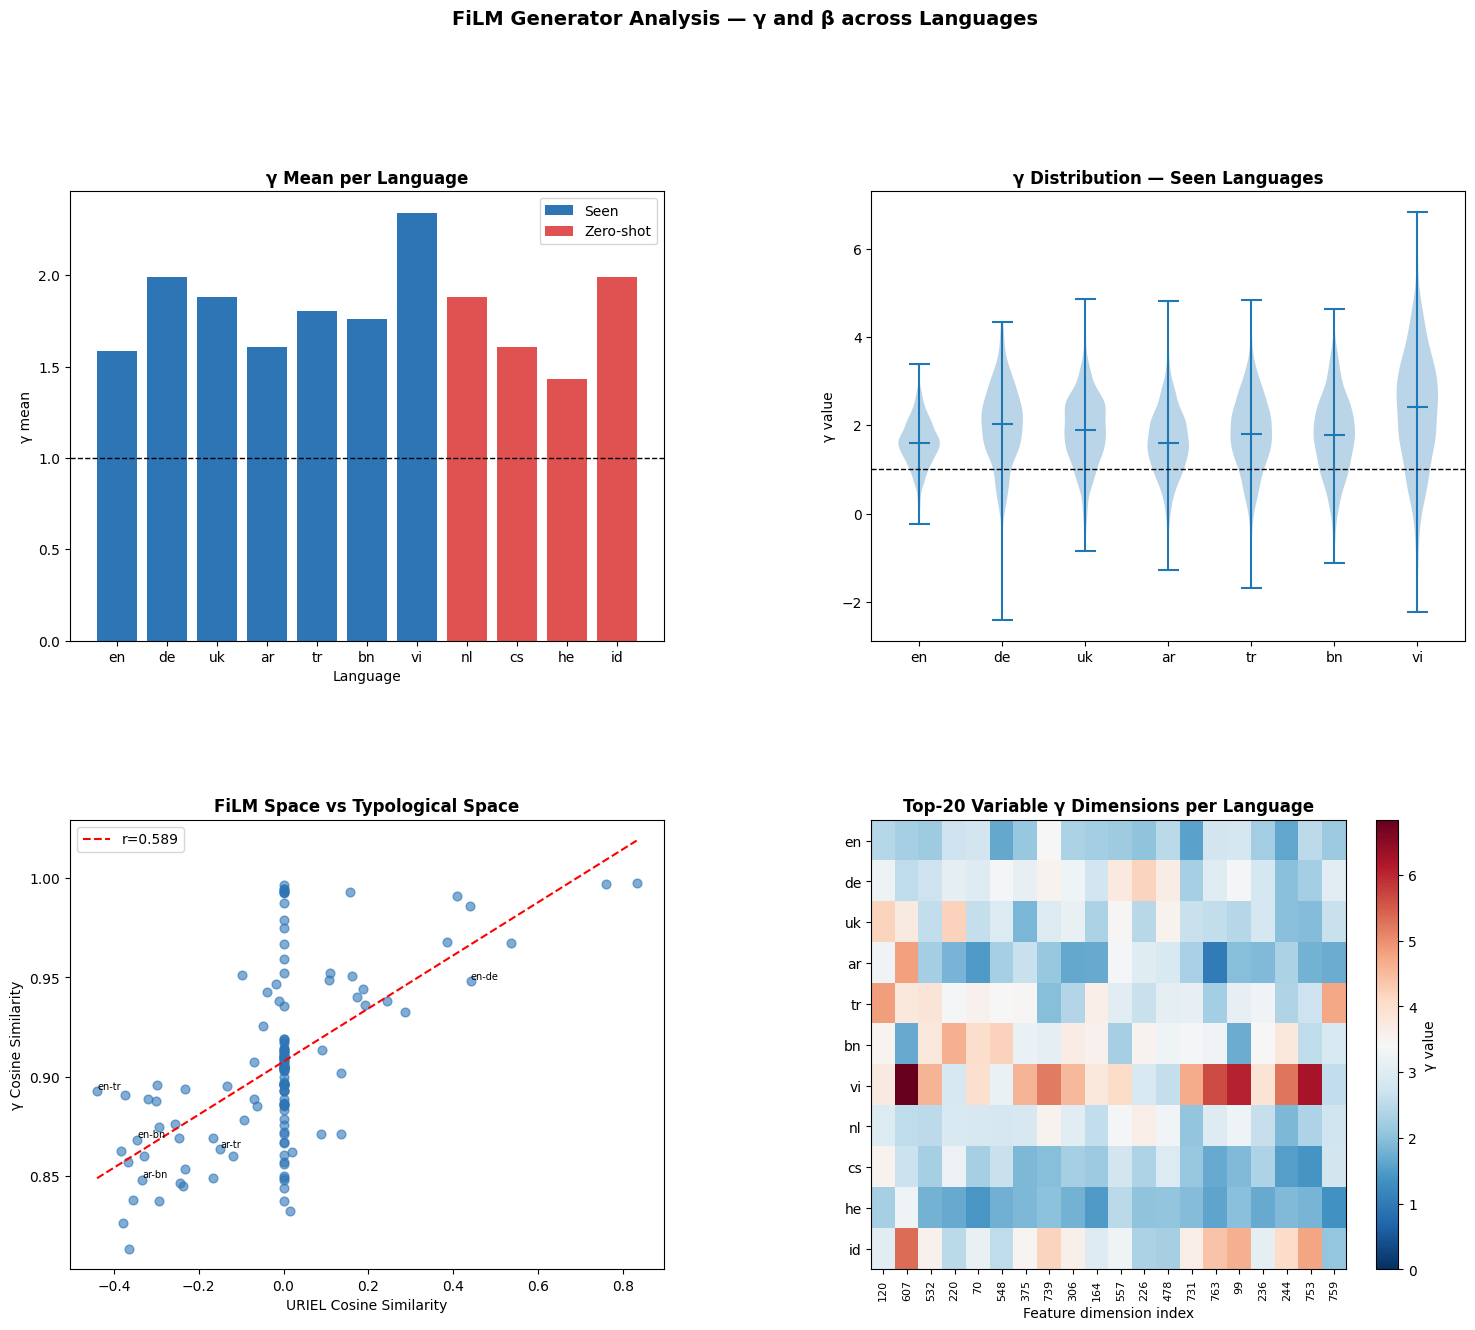


✅ Analysis complete. Plot saved.


In [ ]:
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

ALL_ANALYSIS_LANGS = {
    "en": "English (seen)",   "de": "German (seen)",
    "uk": "Ukrainian (seen)", "ar": "Arabic (seen)",
    "tr": "Turkish (seen)",   "bn": "Bengali (seen)",
    "vi": "Vietnamese (seen)",
    "nl": "Dutch (zero)",     "cs": "Czech (zero)",
    "he": "Hebrew (zero)",    "id": "Indonesian (zero)",
    # Exploded languages included for completeness — flagged in output
    "pl": "Polish (zero)",  "hu": "Hungarian (zero)",
    "te": "Telugu (zero)",  "hi": "Hindi (zero)",
    "mi": "Maori (zero)",   "sw": "Swahili (zero)",
}

# Non-exploded languages used for plots (exploded values break axis scales)
PLOT_LANGS   = ["en","de","uk","ar","tr","bn","vi","nl","cs","he","id"]
SEEN         = ["en","de","uk","ar","tr","bn","vi"]
ZERO_NONEXPL = ["nl","cs","he","id"]

# ── Extract γ and β ───────────────────────────────────────────────────────────
film_generator.eval()
gammas = {}
betas  = {}

with torch.no_grad():
    for lang in ALL_ANALYSIS_LANGS:
        if lang not in LANG_TYPO_VECS:
            print(f"  Skipping {lang} — no URIEL vector")
            continue
        uv = LANG_TYPO_VECS[lang].unsqueeze(0).to(device)
        g, b = film_generator(uv)
        gammas[lang] = g.squeeze(0).cpu().numpy()   # (768,)
        betas[lang]  = b.squeeze(0).cpu().numpy()   # (768,)

print(f"Extracted γ and β for {len(gammas)} languages\n")

# ── 1. Summary statistics ─────────────────────────────────────────────────────
print("── 1. γ Summary Statistics ──────────────────────────────────────────")
print(f"{'Lang':<6} {'γ mean':>8} {'γ std':>8} {'γ min':>8} "
      f"{'γ max':>8} {'β mean':>8} {'β std':>8}")
print("─" * 60)
for lang, label in ALL_ANALYSIS_LANGS.items():
    if lang not in gammas:
        continue
    g   = gammas[lang]
    b   = betas[lang]
    tag = "(seen)" if lang in SEEN else "(zero)"
    print(f"{lang:<6} {g.mean():>8.4f} {g.std():>8.4f} {g.min():>8.4f} "
          f"{g.max():>8.4f} {b.mean():>8.4f} {b.std():>8.4f}  {tag}")

# ── 2. Pairwise cosine similarity of γ vectors (non-exploded only) ────────────
print("\n── 2. Pairwise Cosine Similarity of γ vectors ───────────────────────")
plot_langs_avail = [l for l in PLOT_LANGS if l in gammas]
gamma_matrix     = np.stack([gammas[l] for l in plot_langs_avail])
gamma_tensor     = torch.tensor(gamma_matrix)
sim_matrix       = F.cosine_similarity(
    gamma_tensor.unsqueeze(1), gamma_tensor.unsqueeze(0), dim=2
).numpy()

print(f"{'':>6}", end="")
for l in plot_langs_avail:
    print(f"{l:>7}", end="")
print()
for i, l1 in enumerate(plot_langs_avail):
    print(f"{l1:<6}", end="")
    for j in range(len(plot_langs_avail)):
        print(f"{sim_matrix[i,j]:>7.3f}", end="")
    print()

# ── 3. γ similarity vs URIEL similarity ──────────────────────────────────────
print("\n── 3. γ Similarity vs URIEL Similarity ──────────────────────────────")
uriel_matrix = np.stack([
    LANG_TYPO_VECS[l].numpy() for l in plot_langs_avail
])
uriel_tensor = torch.tensor(uriel_matrix)
uriel_sim    = F.cosine_similarity(
    uriel_tensor.unsqueeze(1), uriel_tensor.unsqueeze(0), dim=2
).numpy()

n          = len(plot_langs_avail)
gamma_sims = []
uriel_sims = []
pairs      = []
for i in range(n):
    for j in range(i+1, n):
        gamma_sims.append(sim_matrix[i, j])
        uriel_sims.append(uriel_sim[i, j])
        pairs.append(f"{plot_langs_avail[i]}-{plot_langs_avail[j]}")

gamma_sims = np.array(gamma_sims)
uriel_sims = np.array(uriel_sims)
corr       = np.corrcoef(gamma_sims, uriel_sims)[0, 1]
print(f"\nPearson r = {corr:.4f}")
print("(+1 = FiLM perfectly reflects typological distance, 0 = no relationship)")

diffs        = np.abs(gamma_sims - uriel_sims)
sorted_pairs = sorted(zip(diffs, pairs, gamma_sims, uriel_sims))
print("\nMost aligned pairs (γ_sim ≈ URIEL_sim):")
for diff, pair, gs, us in sorted_pairs[:5]:
    print(f"  {pair:<14} γ={gs:.3f}  URIEL={us:.3f}  diff={diff:.3f}")
print("\nLeast aligned pairs (γ_sim >> URIEL_sim):")
for diff, pair, gs, us in sorted_pairs[-5:]:
    print(f"  {pair:<14} γ={gs:.3f}  URIEL={us:.3f}  diff={diff:.3f}")

# ── 4. Top-20 variable γ dimensions ──────────────────────────────────────────
print("\n── 4. Top γ Dimensions by Cross-Language Variance ───────────────────")
gamma_var = gamma_matrix.var(axis=0)
top_dims  = np.argsort(gamma_var)[::-1][:20]

print("\nMean |γ-1| on top-20 variable dimensions:")
for lang in plot_langs_avail:
    top_vals  = gammas[lang][top_dims]
    deviation = np.abs(top_vals - 1.0).mean()
    tag       = "(seen)" if lang in SEEN else "(zero)"
    print(f"  {lang:<6} {deviation:.4f}  {tag}")

# ── 5. Four-panel figure (non-exploded languages only) ────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Panel 1: γ mean per language
ax1    = fig.add_subplot(gs[0, 0])
means  = [gammas[l].mean() for l in plot_langs_avail]
colors = ["#2E75B6" if l in SEEN else "#E05252"
          for l in plot_langs_avail]
ax1.bar(plot_langs_avail, means, color=colors)
ax1.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax1.set_title("γ Mean per Language", fontweight="bold")
ax1.set_ylabel("γ mean")
ax1.set_xlabel("Language")
ax1.legend(handles=[
    Patch(facecolor="#2E75B6", label="Seen"),
    Patch(facecolor="#E05252", label="Zero-shot"),
])

# Panel 2: γ distribution — seen languages
ax2       = fig.add_subplot(gs[0, 1])
data_seen = [gammas[l] for l in SEEN if l in gammas]
ax2.violinplot(data_seen, positions=range(len(SEEN)), showmedians=True)
ax2.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax2.set_xticks(range(len(SEEN)))
ax2.set_xticklabels(SEEN)
ax2.set_title("γ Distribution — Seen Languages", fontweight="bold")
ax2.set_ylabel("γ value")

# Panel 3: FiLM space vs typological space
ax3    = fig.add_subplot(gs[1, 0])
ax3.scatter(uriel_sims, gamma_sims, alpha=0.6, color="#2E75B6", s=40)
z      = np.polyfit(uriel_sims, gamma_sims, 1)
x_line = np.linspace(uriel_sims.min(), uriel_sims.max(), 100)
ax3.plot(x_line, np.poly1d(z)(x_line), "r--",
         linewidth=1.5, label=f"r={corr:.3f}")
ax3.set_xlabel("URIEL Cosine Similarity")
ax3.set_ylabel("γ Cosine Similarity")
ax3.set_title("FiLM Space vs Typological Space", fontweight="bold")
ax3.legend()
for i, pair in enumerate(pairs):
    l1, l2 = pair.split("-")
    if l1 in ["en", "ar"] and l2 in ["de", "tr", "bn"]:
        ax3.annotate(pair, (uriel_sims[i], gamma_sims[i]),
                     fontsize=7, ha="left", va="bottom")

# Panel 4: Top-20 variable γ dimensions heatmap (non-exploded)
ax4          = fig.add_subplot(gs[1, 1])
heatmap_data = np.stack([gammas[l][top_dims[:20]]
                          for l in plot_langs_avail])
im = ax4.imshow(heatmap_data, aspect="auto", cmap="RdBu_r",
                vmin=0, vmax=max(2.0, heatmap_data.max()))
ax4.set_xticks(range(20))
ax4.set_xticklabels([str(d) for d in top_dims[:20]],
                    rotation=90, fontsize=8)
ax4.set_yticks(range(len(plot_langs_avail)))
ax4.set_yticklabels(plot_langs_avail)
ax4.set_title("Top-20 Variable γ Dimensions", fontweight="bold")
ax4.set_xlabel("Feature dimension index")
plt.colorbar(im, ax=ax4, label="γ value")

plt.suptitle("FiLM Generator Analysis — γ and β across Languages",
             fontsize=14, fontweight="bold", y=1.01)

save_path = f"{PROJECT_DIR}/film_analysis.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nAnalysis complete | Figure saved to {save_path}")

## Qualitative Analysis — Azerbaijani (Zero-Shot with Turkish Proxy)

Azerbaijani is a Turkic language — the nearest training language in URIEL
space is Turkish. We use the Turkish lang_embedding as a typological proxy
to steer generation, combined with an Azerbaijani forced_bos token.

This tests whether typological proximity (az ≈ tr in URIEL space) produces
more appropriate output than a mismatched proxy (English lang_embedding).

Three conditions compared per image:
1. Turkish proxy  — Turkish lang_embedding + az forced_bos
2. English proxy  — English lang_embedding + az forced_bos  (wrong family)
3. No lang_emb    — zero lang_embedding + az forced_bos     (Variant A baseline)

In [ ]:
# Cell 1 — Find Azerbaijani forced_bos
candidates = {
    "az_option1": "Azərbaycan:",
    "az_option2": "Azərb:",
    "az_option3": "Azerbaycan:",
    "az_option4": "Azeri:",
    "az_option5": "AZ:",
    "az_option6": "Azərbaycanca:",
}

for label, prefix in candidates.items():
    ids = mt5_tokenizer(prefix, add_special_tokens=False).input_ids
    tokens = mt5_tokenizer.convert_ids_to_tokens(ids)
    first = ids[0]
    unique = first != 259
    print(f"{'✓' if unique else '✗'} {label:<22} '{prefix}' → ids={ids} → first={first}")

✓ az_option1             'Azərbaycan:' → ids=[6948, 267] → first=6948
✗ az_option2             'Azərb:' → ids=[259, 169739, 316, 267] → first=259
✗ az_option3             'Azerbaycan:' → ids=[259, 172433, 267] → first=259
✓ az_option4             'Azeri:' → ids=[203789, 266, 267] → first=203789
✓ az_option5             'AZ:' → ids=[30124, 267] → first=30124
✗ az_option6             'Azərbaycanca:' → ids=[259, 231998, 267] → first=259


In [ ]:
import pandas as pd

assert os.path.exists(AZ_CSV), \
    f"Azerbaijani CSV not found: {AZ_CSV}\n" \
    f"Update AZ_CSV path in the configuration cell."

az_df   = pd.read_csv(AZ_CSV)
az_refs = {
    row["image_id"]: [row["az"]]
    for _, row in az_df.iterrows()
    if pd.notna(row["az"])
}
print(f"Azerbaijani references loaded: {len(az_refs):,} images")
print(f"   Columns: {list(az_df.columns)}")
print(f"   Sample reference: {list(az_refs.values())[0][0][:80]}")

In [ ]:
# Use first 5 images that have both az references and XM3600 features
SAMPLE_IDS_AZ = [
    iid for iid in az_refs
    if iid in feat_id_to_idx
][:5]

if not SAMPLE_IDS_AZ:
    print("No Azerbaijani images found in XM3600 features — check image IDs")
else:
    print("=" * 80)
    print("QUALITATIVE ANALYSIS — Azerbaijani Zero-Shot")
    print(f"forced_bos: {az_bos} = "
          f"'{mt5_tokenizer.convert_ids_to_tokens([az_bos])[0]}'")
    print("Three conditions: Turkish proxy | English proxy | No lang_emb")
    print("=" * 80)

    for i, iid in enumerate(SAMPLE_IDS_AZ):
        features = xm_features[feat_id_to_idx[iid]].unsqueeze(0).to(device)
        en_ref   = lang_refs["en"].get(iid, ["?"])[0]
        az_ref   = az_refs[iid][0]

        # Turkish proxy — typologically closest training language
        tr_lid = torch.tensor([LANG_TO_ID["tr"]], device=device)
        # English proxy — typologically mismatched, control condition
        en_lid = torch.tensor([LANG_TO_ID["en"]], device=device)

        with torch.no_grad():
            # Condition 1: Turkish lang_embedding + az forced_bos
            projected_tr = projection(features)
            lang_emb_tr  = lang_embedding(tr_lid).unsqueeze(1)
            enc_tr       = torch.cat([lang_emb_tr, projected_tr], dim=1)
            out_tr = mt5_model.generate(
                inputs_embeds=enc_tr,
                forced_bos_token_id=az_bos,
                max_new_tokens=50,
                num_beams=4,
            )

            # Condition 2: English lang_embedding + az forced_bos
            projected_en = projection(features)
            lang_emb_en  = lang_embedding(en_lid).unsqueeze(1)
            enc_en       = torch.cat([lang_emb_en, projected_en], dim=1)
            out_en = mt5_model.generate(
                inputs_embeds=enc_en,
                forced_bos_token_id=az_bos,
                max_new_tokens=50,
                num_beams=4,
            )

            # Condition 3: No lang_embedding + az forced_bos (Variant A)
            enc_none = encode_zero_shot(features)
            out_none = mt5_model.generate(
                inputs_embeds=enc_none,
                forced_bos_token_id=az_bos,
                max_new_tokens=50,
                num_beams=4,
            )

        pred_tr   = mt5_tokenizer.decode(out_tr[0],   skip_special_tokens=True)
        pred_en   = mt5_tokenizer.decode(out_en[0],   skip_special_tokens=True)
        pred_none = mt5_tokenizer.decode(out_none[0], skip_special_tokens=True)

        print(f"\n  Image {i+1:02d}: {iid}")
        print(f"  EN ref:       {en_ref[:75]}")
        print(f"  AZ ref:       {az_ref[:75]}")
        print(f"  Turkish prx:  {pred_tr[:100]}")
        print(f"  English prx:  {pred_en[:100]}")
        print(f"  No lang_emb:  {pred_none[:100]}")

    print(f"\nAzerbaijani qualitative analysis complete")

In [ ]:
# Azerbaijani qualitative examples — zero-shot
SAMPLE_IDS_AZ = list(az_refs.keys())[:5]  # first 5 images that have az references

print(f"Azerbaijani qualitative examples (zero-shot)")
print(f"forced_bos: {az_bos} = '{mt5_tokenizer.convert_ids_to_tokens([az_bos])[0]}'")
print()

for iid in SAMPLE_IDS_AZ:
    if iid not in feat_id_to_idx:
        continue
    feat_idx = feat_id_to_idx[iid]
    features = xm_features[feat_idx].unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_input = encode_zero_shot(features)
        out = mt5_model.generate(
            inputs_embeds=encoder_input,
            forced_bos_token_id=az_bos,
            max_new_tokens=50,
            num_beams=4,
        )

    pred_az = mt5_tokenizer.decode(out[0], skip_special_tokens=True)
    ref_az  = az_refs.get(iid, ["?"])[0]
    ref_en  = lang_refs["en"].get(iid, ["?"])[0]

    print(f"Image: {iid}")
    print(f"  EN ref:  {ref_en}")
    print(f"  AZ ref:  {ref_az}")
    print(f"  AZ pred: {pred_az}")
    print()

# **New way (Typology Soft Prompt + Decoder LoRA)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Paths**

In [ ]:
import os

# ── Root ──────────────────────────────────────────────────────────────────────
DRIVE_ROOT  = "/content/drive/MyDrive/MLP Project/MLP Group"

# ── Project directories ───────────────────────────────────────────────────────
PROJECT_DIR = f"{DRIVE_ROOT}/mlp_project"
DATASET_DIR = f"{PROJECT_DIR}/datasets"
XM3600_DIR  = f"{PROJECT_DIR}/xm3600"
CHECKPOINT_DIR = f"{DRIVE_ROOT}/checkpoints"

# ── Feature files ─────────────────────────────────────────────────────────────
MULTILINGUAL_FEATURES = f"{PROJECT_DIR}/multilingual_features.pt"
XM3600_FEATURES       = f"{PROJECT_DIR}/xm3600_features.pt"

TYPOLOGY_FEATURES     = f"{PROJECT_DIR}/typology_features.pt"
LANG_NEAREST_FILE     = f"{PROJECT_DIR}/nearest_seen_lang_map.json"

# ── Checkpoints ───────────────────────────────────────────────────────────────
CKPT_O1 = f"{CHECKPOINT_DIR}/best_multilingual.pt"
CKPT_O2 = f"{CHECKPOINT_DIR}/best_multilingual_film.pt"

# ── Prediction files ──────────────────────────────────────────────────────────
O1_PREDS_FILE     = f"{CHECKPOINT_DIR}/o1_preds_subset.json"
O2_PREDS_FILE     = f"{CHECKPOINT_DIR}/o2_typology_prompt_preds_subset.json"
UNSEEN_PREDS_FILE = f"{CHECKPOINT_DIR}/unseen_typology_prompt_preds.json"

# ── Azerbaijani dataset ───────────────────────────────────────────────────────
AZ_CSV = f"{PROJECT_DIR}/xm3600_azerbaijani_full_checked.csv"


print("DRIVE_ROOT       =", DRIVE_ROOT)
print("PROJECT_DIR      =", PROJECT_DIR)
print("DATASET_DIR      =", DATASET_DIR)
print("CHECKPOINT_DIR   =", CHECKPOINT_DIR)
print("XM3600_DIR       =", XM3600_DIR)

DRIVE_ROOT       = /content/drive/MyDrive/MLP Project/MLP Group
PROJECT_DIR      = /content/drive/MyDrive/MLP Project/MLP Group/mlp_project
DATASET_DIR      = /content/drive/MyDrive/MLP Project/MLP Group/mlp_project/datasets
CHECKPOINT_DIR   = /content/drive/MyDrive/MLP Project/MLP Group/checkpoints
XM3600_DIR       = /content/drive/MyDrive/MLP Project/MLP Group/mlp_project/xm3600


In [ ]:
import json
import os
import pandas as pd

base = DATASET_DIR
results = []

def safe_exists(path):
    return os.path.exists(path)

# Turkish
turkish_json = os.path.join(base, "turkish", "tasviret8k_captions.json")
if safe_exists(turkish_json):
    with open(turkish_json, "r", encoding="utf-8") as f:
        data = json.load(f)
    results.append((
        "Turkish",
        len(data["images"]),
        sum(len(img["sentences"]) for img in data["images"]),
        "Flickr8k"
    ))
else:
    print(f"Missing: {turkish_json}")

# Arabic
arabic_txt = os.path.join(base, "arabic", "Flickr8k.arabic.full.txt")
if safe_exists(arabic_txt):
    with open(arabic_txt, "r", encoding="utf-8") as f:
        lines = [l.strip() for l in f if l.strip()]
    ar_files = set(l.split("\t")[0].split("#")[0] for l in lines if "\t" in l)
    results.append(("Arabic", len(ar_files), len(lines), "Flickr8k"))
else:
    print(f"Missing: {arabic_txt}")

# Bengali
bengali_csv = os.path.join(base, "bengali", "BAN-Cap_captiondata.csv")
if safe_exists(bengali_csv):
    df = pd.read_csv(bengali_csv)
    bn_files = set(df["caption_id"].astype(str).apply(lambda x: x.split("#")[0]))
    results.append(("Bengali", len(bn_files), len(df), "Flickr8k"))
else:
    print(f"Missing: {bengali_csv}")

# English
en_total = 0
en_ok = True
for split in ["train", "val", "test"]:
    en_file = os.path.join(base, "english", f"{split}.en")
    if safe_exists(en_file):
        with open(en_file, "r", encoding="utf-8") as f:
            en_total += len(f.readlines())
    else:
        print(f"Missing: {en_file}")
        en_ok = False
if en_ok:
    results.append(("English", "~31K (Flickr30k)", en_total, "Flickr30k"))

# German
de_total = 0
de_ok = True
for split in ["train", "val", "test"]:
    de_file = os.path.join(base, "german", f"{split}.de")
    if safe_exists(de_file):
        with open(de_file, "r", encoding="utf-8") as f:
            de_total += len(f.readlines())
    else:
        print(f"Missing: {de_file}")
        de_ok = False
if de_ok:
    results.append(("German", "~31K (Flickr30k)", de_total, "Flickr30k"))

# Ukrainian
uk_total = 0
uk_ok = True
for fname in ["train.json", "test_2016_flickr.json", "test_2017_flickr.json"]:
    uk_file = os.path.join(base, "ukrainian", fname)
    if safe_exists(uk_file):
        with open(uk_file, "r", encoding="utf-8") as f:
            uk_total += sum(1 for line in f if line.strip())
    else:
        print(f"Missing: {uk_file}")
        uk_ok = False
if uk_ok:
    results.append(("Ukrainian", "~31K (Flickr30k)", uk_total, "Flickr30k"))

# Vietnamese
vi_imgs = 0
vi_caps = 0
vi_ok = True
for split in ["train", "dev", "test"]:
    vi_file = os.path.join(base, "vietnamese", f"vi_{split}.json")
    if safe_exists(vi_file):
        with open(vi_file, "r", encoding="utf-8") as f:
            data = json.load(f)
        vi_imgs += len(data)
        vi_caps += sum(len(v["captions"]) for v in data.values())
    else:
        print(f"Missing: {vi_file}")
        vi_ok = False
if vi_ok:
    results.append(("Vietnamese", vi_imgs, vi_caps, "UIT-OpenViIC"))

# Print summary
print(f"{'Language':<12} {'Images':>14} {'Captions':>10} {'Source':<15}")
print("-" * 60)

total_caps = 0
for lang, imgs, caps, src in results:
    print(f"{lang:<12} {str(imgs):>14} {caps:>10} {src:<15}")
    total_caps += caps

print("-" * 60)
print(f"{'TOTAL':<12} {'':>14} {total_caps:>10}")

Language             Images   Captions Source         
------------------------------------------------------------
Turkish                8000      16037 Flickr8k       
Arabic                 8091      24274 Flickr8k       
Bengali                8091      40455 Flickr8k       
English      ~31K (Flickr30k)      31014 Flickr30k      
German       ~31K (Flickr30k)      31014 Flickr30k      
Ukrainian    ~31K (Flickr30k)      31000 Flickr30k      
Vietnamese            13100      61241 UIT-OpenViIC   
------------------------------------------------------------
TOTAL                           235035


In [ ]:
### Verify files exist before proceeding

checks = {
    "O1 checkpoint":          CKPT_O1,
    "O2 checkpoint":          CKPT_O2,
    "Multilingual features":  MULTILINGUAL_FEATURES,
    "XM3600 features":        XM3600_FEATURES,
    "Azerbaijani CSV":        AZ_CSV,
}

all_ok = True
for name, path in checks.items():
    exists = os.path.exists(path)
    size   = f"{os.path.getsize(path)/1e9:.2f} GB" if exists else "not found"
    status = "found" if exists else "missing"
    print(f"{status} {name:<28} {size}")
    if not exists:
        all_ok = False

print()
print("All files present — ready to proceed." if all_ok else
      "Missing files above — update paths before continuing.")


### Verify files exist before proceeding

def format_file_status(path):
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1e6
        if size_mb >= 1024:
            return "found", f"{size_mb/1024:.2f} GB"
        return "found", f"{size_mb:.1f} MB"
    return "missing", "not found"


# ── Required input files: must exist now ──────────────────────────────────────
required_inputs = {
    "O1 baseline checkpoint": CKPT_O1,
    "Multilingual features": MULTILINGUAL_FEATURES,
    "XM3600 features": XM3600_FEATURES,
    "Azerbaijani CSV": AZ_CSV,
}


# ── Optional output files: OK if missing before training/inference ───────────
optional_outputs = {
    "Typology features cache": TYPOLOGY_FEATURES,
    "O2 checkpoint": CKPT_O2,
    "O1 predictions": O1_PREDS_FILE,
    "O2 predictions": O2_PREDS_FILE,
    "Unseen-language predictions": UNSEEN_PREDS_FILE,
    "Nearest seen-language mapping": LANG_NEAREST_FILE,
}


print("=== Required input files ===")
all_required_ok = True
for name, path in required_inputs.items():
    status, size = format_file_status(path)
    print(f"{status:<8} {name:<34} {size}")
    if status == "missing":
        all_required_ok = False

print("\n=== Optional output / cache files ===")
for name, path in optional_outputs.items():
    status, size = format_file_status(path)
    print(f"{status:<8} {name:<34} {size}")

print()
if all_required_ok:
    print("All required input files are present — ready to proceed.")
else:
    print("Some required input files are missing — update paths before continuing.")

found O1 checkpoint                3.88 GB
found O2 checkpoint                3.88 GB
found Multilingual features        5.13 GB
found XM3600 features              0.35 GB
found Azerbaijani CSV              0.00 GB

All files present — ready to proceed.
=== Required input files ===
found    O1 baseline checkpoint             3.79 GB
found    Multilingual features              5.01 GB
found    XM3600 features                    354.0 MB
found    Azerbaijani CSV                    0.5 MB

=== Optional output / cache files ===
missing  Typology features cache            not found
found    O2 checkpoint                      3.79 GB
missing  O1 predictions                     not found
missing  O2 predictions                     not found
missing  Unseen-language predictions        not found
missing  Nearest seen-language mapping      not found

All required input files are present — ready to proceed.


## **Dataset Loader**

In [ ]:
%%writefile "/content/drive/MyDrive/MLP Project/MLP Group/multilingual_dataset.py"

"""
Multilingual Dataset Loader for Task 1 — Typology-Agnostic Baseline

Loads all 7 language datasets from Google Drive, unifies them into a common
format, and provides a PyTorch Dataset compatible with the training pipeline
from english_model_lora.py.

Each sample: (image_path, caption, language_code)

Languages:
  1. English   (en) — Multi30k, Flickr30k images
  2. German    (de) — Multi30k, Flickr30k images
  3. Ukrainian (uk) — Multi30k-uk, Flickr30k images
  4. Arabic    (ar) — Flickr8k Arabic, Flickr8k images
  5. Turkish   (tr) — TasvirEt, Flickr8k images
  6. Bengali   (bn) — BAN-Cap, Flickr8k images
  7. Vietnamese(vi) — UIT-OpenViIC, own images

Usage in Colab:
    from multilingual_dataset import load_all_datasets, MultilingualCaptionDataset

    samples = load_all_datasets(base_path="/content/drive/MyDrive/mlp_project/datasets")
    dataset = MultilingualCaptionDataset(samples, tokenizer, max_length=64)
"""

import json
import os
import pandas as pd
from torch.utils.data import Dataset


# ── Language prompt prefixes (used by mT5 to know which language to generate) ─
LANG_PREFIXES = {
    "en": "<lang=en> ",
    "de": "<lang=de> ",
    "uk": "<lang=uk> ",
    "ar": "<lang=ar> ",
    "tr": "<lang=tr> ",
    "bn": "<lang=bn> ",
    "vi": "<lang=vi> ",
}


def load_english(base_path):
    """Load English Multi30k captions. Returns list of (image_path, caption, 'en')."""
    samples = []
    img_dir = os.path.join(base_path, "images", "flickr30k")

    # Multi30k uses line number = image index
    # We need the image filename list — Multi30k images are named by their Flickr ID
    # The image order file maps line numbers to filenames
    # For Multi30k, images are ordered — line 0 = first image, etc.
    # We'll load the image filenames from the directory sorted, matching Multi30k order

    # Multi30k provides a separate file for image order, but we don't have it
    # Instead, we use the Flickr30k standard: train_images.txt etc.
    # For now, load captions and pair with image index (to be resolved during feature precompute)

    for split in ["train", "val", "test"]:
        caption_file = os.path.join(base_path, "english", f"{split}.en")
        with open(caption_file, "r", encoding="utf-8") as f:
            for line_idx, line in enumerate(f):
                caption = line.strip()
                if caption:
                    # Image path will be resolved later using Multi30k image order
                    samples.append({
                        "image_source": "flickr30k",
                        "image_id": f"multi30k_{split}_{line_idx}",
                        "caption": caption,
                        "lang": "en",
                    })

    print(f"  English: {len(samples)} samples loaded")
    return samples


def load_german(base_path):
    """Load German Multi30k captions."""
    samples = []

    for split in ["train", "val", "test"]:
        caption_file = os.path.join(base_path, "german", f"{split}.de")
        with open(caption_file, "r", encoding="utf-8") as f:
            for line_idx, line in enumerate(f):
                caption = line.strip()
                if caption:
                    samples.append({
                        "image_source": "flickr30k",
                        "image_id": f"multi30k_{split}_{line_idx}",
                        "caption": caption,
                        "lang": "de",
                    })

    print(f"  German: {len(samples)} samples loaded")
    return samples


def load_ukrainian(base_path):
    """Load Ukrainian Multi30k-uk captions (JSONL format)."""
    samples = []

    files = ["train.json", "test_2016_flickr.json", "test_2017_flickr.json"]
    split_names = ["train", "test2016", "test2017"]

    for fname, split_name in zip(files, split_names):
        filepath = os.path.join(base_path, "ukrainian", fname)
        with open(filepath, "r", encoding="utf-8") as f:
            for line_idx, line in enumerate(f):
                line = line.strip()
                if not line:
                    continue
                item = json.loads(line)
                uk_caption = item.get("uk", "")
                if uk_caption:
                    samples.append({
                        "image_source": "flickr30k",
                        "image_id": f"multi30k_{split_name}_{line_idx}",
                        "caption": uk_caption,
                        "lang": "uk",
                    })

    print(f"  Ukrainian: {len(samples)} samples loaded")
    return samples


def load_arabic(base_path):
    """Load Arabic Flickr8k captions. Format: filename#N<tab>caption"""
    samples = []

    filepath = os.path.join(base_path, "arabic", "Flickr8k.arabic.full.txt")
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or "\t" not in line:
                continue
            parts = line.split("\t", 1)
            img_id = parts[0].split("#")[0]  # e.g. "1000268201_693b08cb0e.jpg"
            caption = parts[1]
            samples.append({
                "image_source": "flickr8k",
                "image_id": img_id,
                "caption": caption,
                "lang": "ar",
            })

    print(f"  Arabic: {len(samples)} samples loaded")
    return samples


def load_turkish(base_path):
    """Load Turkish TasvirEt captions. JSON with images list."""
    samples = []

    filepath = os.path.join(base_path, "turkish", "tasviret8k_captions.json")
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

    for img in data["images"]:
        filename = img["filename"]
        for sent in img["sentences"]:
            caption = sent["raw"]
            samples.append({
                "image_source": "flickr8k",
                "image_id": filename,
                "caption": caption,
                "lang": "tr",
            })

    print(f"  Turkish: {len(samples)} samples loaded")
    return samples


def load_bengali(base_path):
    """Load Bengali BAN-Cap captions. CSV with caption_id, english_caption, bengali_caption."""
    samples = []

    filepath = os.path.join(base_path, "bengali", "BAN-Cap_captiondata.csv")
    df = pd.read_csv(filepath)

    for _, row in df.iterrows():
        img_id = row["caption_id"].split("#")[0]
        caption = row["bengali_caption"]
        if pd.notna(caption) and str(caption).strip():
            samples.append({
                "image_source": "flickr8k",
                "image_id": img_id,
                "caption": str(caption).strip(),
                "lang": "bn",
            })

    print(f"  Bengali: {len(samples)} samples loaded")
    return samples


def load_vietnamese(base_path):
    """Load Vietnamese UIT-OpenViIC captions. JSON with filename -> {captions: [...]}."""
    samples = []

    for split in ["train", "dev", "test"]:
        filepath = os.path.join(base_path, "vietnamese", f"vi_{split}.json")
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)

        for filename, entry in data.items():
            for caption in entry["captions"]:
                samples.append({
                    "image_source": "vietnamese",
                    "image_id": filename,
                    "caption": caption,
                    "lang": "vi",
                })

    print(f"  Vietnamese: {len(samples)} samples loaded")
    return samples


def load_all_datasets(base_path):
    """
    Load all 7 language datasets and return a unified list of samples.

    Each sample is a dict:
        {
            "image_source": "flickr8k" | "flickr30k" | "vietnamese",
            "image_id": str,   # filename or multi30k index
            "caption": str,
            "lang": str,       # ISO code: en, de, uk, ar, tr, bn, vi
        }
    """
    print("Loading all datasets...")

    all_samples = []
    all_samples.extend(load_english(base_path))
    all_samples.extend(load_german(base_path))
    all_samples.extend(load_ukrainian(base_path))
    all_samples.extend(load_arabic(base_path))
    all_samples.extend(load_turkish(base_path))
    all_samples.extend(load_bengali(base_path))
    all_samples.extend(load_vietnamese(base_path))

    # Summary
    print(f"\n{'='*50}")
    print(f"TOTAL: {len(all_samples)} samples across 7 languages")
    print(f"{'='*50}")

    lang_counts = {}
    for s in all_samples:
        lang_counts[s["lang"]] = lang_counts.get(s["lang"], 0) + 1
    for lang, count in sorted(lang_counts.items()):
        print(f"  {lang}: {count:>6} samples")

    return all_samples


def get_image_path(sample, base_path):
    """
    Resolve the full image path for a sample.

    For flickr8k/vietnamese: image_id is the actual filename.
    For flickr30k (multi30k): needs the image order file (handled separately).
    """
    source = sample["image_source"]
    img_id = sample["image_id"]

    if source == "flickr8k":
        return os.path.join(base_path, "images", "flickr8k", img_id)
    elif source == "vietnamese":
        return os.path.join(base_path, "images", "vietnamese", img_id)
    elif source == "flickr30k":
        # Multi30k images need special handling — see build_multi30k_image_map()
        return None  # resolved later
    return None


def build_multi30k_image_map(base_path):
    """
    Build a mapping from multi30k line indices to Flickr30k image filenames.

    Multi30k images are ordered — we need the image order file.
    This is typically train_images.txt, val_images.txt, test_images.txt
    with one filename per line.

    If these files don't exist, we'll need to download them separately.
    Returns: dict mapping "multi30k_{split}_{line_idx}" -> "filename.jpg"
    """
    img_map = {}
    img_dir = os.path.join(base_path, "images", "flickr30k")

    # Try to load image order files
    for split, order_file in [("train", "train_images.txt"),
                               ("val", "val_images.txt"),
                               ("test", "test_images.txt")]:
        order_path = os.path.join(base_path, "flickr30k_order", order_file)
        if os.path.exists(order_path):
            with open(order_path, "r") as f:
                for line_idx, line in enumerate(f):
                    fname = line.strip()
                    if fname:
                        key = f"multi30k_{split}_{line_idx}"
                        img_map[key] = os.path.join(img_dir, fname)

    if not img_map:
        print("  Multi30k image order files not found!")
        print("  Need to download train_images.txt, val_images.txt, test_images.txt")
        print("  from https://github.com/multi30k/dataset/tree/master/data/task1/image_splits/")

    return img_map


class MultilingualCaptionDataset(Dataset):
    """
    PyTorch Dataset for multilingual captioning.

    Each item returns:
        - image_path (str): full path to the image file
        - caption (str): caption text with language prefix
        - lang (str): language code
    """
    def __init__(self, samples, add_lang_prefix=True):
        self.samples = samples
        self.add_lang_prefix = add_lang_prefix

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        caption = sample["caption"]
        lang = sample["lang"]

        if self.add_lang_prefix:
            caption = LANG_PREFIXES.get(lang, f"<lang={lang}> ") + caption

        return {
            "image_source": sample["image_source"],
            "image_id": sample["image_id"],
            "caption": caption,
            "lang": lang,
        }


# ── Quick test ────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    import sys

    base = (
        sys.argv[1]
        if len(sys.argv) > 1
        else "/content/drive/MyDrive/MLP Project/MLP Group/mlp_project/datasets"
    )

    if not os.path.exists(base):
        print(f"Path not found: {base}")
        print("Usage: python multilingual_dataset.py /path/to/datasets")
        sys.exit(1)

    samples = load_all_datasets(base)

    # Show a few samples per language
    print("\nSample captions:")
    shown = set()
    for s in samples:
      if s["lang"] not in shown:
          shown.add(s["lang"])
          prefix = LANG_PREFIXES.get(s["lang"], f"<lang={s['lang']}> ")
          print(f"  [{s['lang']}] {prefix}{s['caption'][:80]}...")
      if len(shown) == 7:
          break


Overwriting /content/drive/MyDrive/MLP Project/MLP Group/multilingual_dataset.py


In [ ]:
import sys
sys.path.append("/content/drive/MyDrive/MLP Project/MLP Group")

from multilingual_dataset import load_all_datasets
samples = load_all_datasets(base)

Loading all datasets...
  English: 31014 samples loaded
  German: 31014 samples loaded
  Ukrainian: 31000 samples loaded
  Arabic: 24273 samples loaded
  Turkish: 16037 samples loaded
  Bengali: 40455 samples loaded
  Vietnamese: 61241 samples loaded

TOTAL: 235034 samples across 7 languages
  ar:  24273 samples
  bn:  40455 samples
  de:  31014 samples
  en:  31014 samples
  tr:  16037 samples
  uk:  31000 samples
  vi:  61241 samples


In [ ]:
from multilingual_dataset import get_image_path, build_multi30k_image_map

# Build Multi30k image mapping
img_map = build_multi30k_image_map(base)
print(f"Multi30k image map: {len(img_map)} entries")


# Test each language - check if images actually exist
import random
random.seed(42)

errors = []
for lang in ["en", "de", "uk", "ar", "tr", "bn", "vi"]:
    lang_samples = [s for s in samples if s["lang"] == lang]
    test_samples = random.sample(lang_samples, min(20, len(lang_samples)))

    missing = 0
    for s in test_samples:
        if s["image_source"] == "flickr30k":
            path = img_map.get(s["image_id"])
        else:
            path = get_image_path(s, base)

        if path is None or not os.path.exists(path):
            missing += 1
            if missing <= 2:
                print(f"  [{lang}] missing: {s['image_id']} → {path}")

    status = "found" if missing == 0 else f"{missing}/20 missing"
    print(f"  {lang}: {status}")
    if missing > 0:
        errors.append(lang)

if not errors:
    print("\n All image mappings verified! Ready for feature precomputation.")
else:
    print(f"\n Issues found for: {errors}")

Multi30k image map: 31014 entries
  en: found
  de: found
  uk: found
  ar: found
  tr: found
  bn: found
  vi: found

 All image mappings verified! Ready for feature precomputation.


### **check how many images missing**

In [ ]:
missing_files = []

for key, path in img_map.items():
    if not os.path.exists(path):
        missing_files.append((key, path))

print(f"Total mapped images: {len(img_map)}")
print(f"Missing image files: {len(missing_files)}")

for item in missing_files[:10]:
    print(item)

Total mapped images: 31014
Missing image files: 0


### **GPU and environment**

In [ ]:
import os
import gc
import torch

# GPU info
!nvidia-smi

# Clear any leftover GPU memory from previous runs
gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name} | VRAM: {props.total_memory / 1e9:.1f} GB")

Tue Mar 24 23:59:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             48W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# # Verify required checkpoints exist before running anything
# CHECKPOINT_O1   = "/content/drive/MyDrive/checkpoints_to_download/best_multilingual.pt"
# CHECKPOINT_O2   = "/content/drive/MyDrive/checkpoints_to_download/best_multilingual_film.pt"
# FEATURE_FILE    = "/content/drive/MyDrive/mlp_project/multilingual_features.pt"
# XM3600_FEATURES = "/content/drive/MyDrive/mlp_project/xm3600_features.pt"

# for name, path in [
#     ("O1 checkpoint",    CHECKPOINT_O1),
#     ("O2 checkpoint",    CHECKPOINT_O2),
#     ("Train features",   FEATURE_FILE),
#     ("XM3600 features",  XM3600_FEATURES),
# ]:
#     exists = os.path.exists(path)
#     size   = f"{os.path.getsize(path)/1e9:.1f} GB" if exists else ""
#     print(f"{'found' if exists else 'not found'} {name:<20} {size}")


# Verify required checkpoints exist before running anything
CHECKPOINT_O1   = f"{CHECKPOINT_DIR}/best_multilingual.pt"
CHECKPOINT_O2   = f"{CHECKPOINT_DIR}/best_multilingual_film.pt"   # old O2 / FiLM
FEATURE_FILE    = f"{PROJECT_DIR}/multilingual_features.pt"
XM3600_FEATURES = f"{PROJECT_DIR}/xm3600_features.pt"

for name, path in [
    ("O1 checkpoint",    CHECKPOINT_O1),
    ("O2 checkpoint",    CHECKPOINT_O2),
    ("Train features",   FEATURE_FILE),
    ("XM3600 features",  XM3600_FEATURES),
]:
    exists = os.path.exists(path)
    size   = f"{os.path.getsize(path)/1e9:.1f} GB" if exists else ""
    print(f"{'found' if exists else 'not found'} {name:<20} {size}")

found O1 checkpoint        3.9 GB
found O2 checkpoint        3.9 GB
found Train features       5.1 GB
found XM3600 features      0.4 GB


### **Dependencies**

In [ ]:
import subprocess

subprocess.run(["pip", "install", "lang2vec",       "-q"], check=True)
subprocess.run(["pip", "install", "pycocoevalcap",  "-q"], check=True)
subprocess.run(["pip", "install", "peft",           "-q"], check=True)

print("Dependencies installed")

Dependencies installed


## **Training**

### **Typology Vectors**

In [ ]:
# ── Typology Vectors ──────────────────────────────────────────────────
import torch
import subprocess
subprocess.run(["pip", "install", "lang2vec", "-q"], check=True)

import lang2vec.lang2vec as l2v
import numpy as np

TYPO_LANGS = ["en", "de", "uk", "ar", "tr", "bn", "vi"]

def get_raw(lang, fs):
    """Get raw feature vector for a single language — may contain '--' strings."""
    return l2v.get_features([lang], fs)[lang]

def build_typology_matrix(langs):
    """
    Build a clean typology matrix:
      - Primary: syntax_average
      - Fallback per dimension: syntax_knn where syntax_average == '--'
    Returns:
      mat: (len(langs), 103) float32
      fallback_counts: dict(lang -> number of fallback dimensions)
    """
    mat = []
    fallback_counts = {}

    for lang in langs:
        avg = get_raw(lang, "syntax_average")
        knn = get_raw(lang, "syntax_knn")

        vec = []
        n_fallback = 0
        for a, k in zip(avg, knn):
            if a == "--":
                vec.append(float(k))
                n_fallback += 1
            else:
                vec.append(float(a))

        mat.append(vec)
        fallback_counts[lang] = n_fallback

    mat = np.array(mat, dtype=np.float32)

    assert not np.isnan(mat).any(), "NaNs remain in typology matrix"
    assert not np.isinf(mat).any(), "Infs remain in typology matrix"

    return mat, fallback_counts


print("\n── Step 1: Typology Vectors " + "─" * 42)
print("  Building matrix (syntax_average + syntax_knn fallback)...")
typo_matrix_raw, fallback_counts = build_typology_matrix(TYPO_LANGS)
TYPO_DIM = typo_matrix_raw.shape[1]

print(f"\n  Matrix shape: {typo_matrix_raw.shape} | NaNs: {np.isnan(typo_matrix_raw).any()}")
print(f"\n  {'Lang':<6} {'Observed':>10}  {'KNN fallback':>12}")
print(f"  {'─'*32}")
for lang in TYPO_LANGS:
    fb = fallback_counts[lang]
    obs = TYPO_DIM - fb
    bar = "█" * (fb // 3)
    print(f"  {lang:<6} {obs:>7}/{TYPO_DIM}   {fb:>7}/{TYPO_DIM}  {bar}")

# Z-score normalise across languages, per feature dimension
mean = typo_matrix_raw.mean(axis=0)
std  = typo_matrix_raw.std(axis=0) + 1e-8
typo_matrix_norm = (typo_matrix_raw - mean) / std

LANG_TYPO_VECS = {
    lang: torch.tensor(typo_matrix_norm[i], dtype=torch.float32)
    for i, lang in enumerate(TYPO_LANGS)
}

def cosine_sim(a, b):
    return float(
        torch.nn.functional.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0))
    )

print(f"\nURIEL vectors computed for {len(LANG_TYPO_VECS)} languages")
print(f"Vector dim: {typo_matrix_norm.shape[1]}")
print(f"\n  Cosine similarity to English:")
en_vec = LANG_TYPO_VECS["en"]
for lang in ["de", "uk", "ar", "tr", "bn", "vi"]:
    sim = cosine_sim(en_vec, LANG_TYPO_VECS[lang])
    bar = "█" * int((sim + 1) * 10)
    print(f"    en–{lang}  {sim:+.3f}  {bar}")


── Step 1: Typology Vectors ──────────────────────────────────────────
  Building matrix (syntax_average + syntax_knn fallback)...

  Matrix shape: (7, 103) | NaNs: False

  Lang     Observed  KNN fallback
  ────────────────────────────────
  en         103/103         0/103  
  de          87/103        16/103  █████
  uk          77/103        26/103  ████████
  ar          98/103         5/103  █
  tr          89/103        14/103  ████
  bn          52/103        51/103  █████████████████
  vi          93/103        10/103  ███

URIEL vectors computed for 7 languages
Vector dim: 103

  Cosine similarity to English:
    en–de  +0.441  ██████████████
    en–uk  +0.192  ███████████
    en–ar  -0.300  ███████
    en–tr  -0.440  █████
    en–bn  -0.345  ██████
    en–vi  +0.089  ██████████


### **Model Components**

In [ ]:
import torch
import torch.nn as nn

class ProjectionMLP(nn.Module):
    """
    Kept identical to O1 checkpoint architecture.
    """
    def __init__(self, in_dim=768, out_dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.GELU(),
            nn.LayerNorm(out_dim),
            nn.Linear(out_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class TypologyPromptGenerator(nn.Module):
    """
    Maps a 103-d URIEL typology vector to k soft prompt tokens.

    Input:
      uriel: (B, 103)

    Output:
      prompts: (B, prompt_len, d_model)
    """
    def __init__(self, uriel_dim=103, hidden_dim=256, prompt_len=8, d_model=768):
        super().__init__()
        self.prompt_len = prompt_len
        self.d_model = d_model
        self.net = nn.Sequential(
            nn.Linear(uriel_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, prompt_len * d_model),
        )

    def forward(self, uriel):
        out = self.net(uriel)  # (B, prompt_len * d_model)
        return out.view(uriel.size(0), self.prompt_len, self.d_model)

### **Training Pipeline (Typology Soft Prompt + Decoder LoRA)**

**Route**

In [ ]:
SAVE_DIR = os.path.join(DRIVE_ROOT, "my_checkpoints")
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Checkpoint directory: {SAVE_DIR}")

Checkpoint directory: /content/drive/MyDrive/MLP Project/MLP Group/my_checkpoints


**Test Pipeline (test if Full Pipeline can run)**

In [ ]:
import os
import sys
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import get_peft_model, LoraConfig, TaskType
from tqdm import tqdm

# ── Debug config: small subset to smoke-test the full pipeline ───────────────
DEBUG_SUBSET = True
DEBUG_PER_LANG = 50          # 20 / 50 / 100 are good smoke-test sizes
DEBUG_BATCH_SIZE = 4
DEBUG_EPOCHS = 1

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name} | VRAM: {props.total_memory / 1e9:.1f} GB")

# ── Language config ───────────────────────────────────────────────────────────
LANG_TO_ID = {"en": 0, "de": 1, "uk": 2, "ar": 3, "tr": 4, "bn": 5, "vi": 6}
ID_TO_LANG = {v: k for k, v in LANG_TO_ID.items()}
NUM_LANGS = len(LANG_TO_ID)

LANG_PREFIXES = {
    "en": "<lang=en> ",
    "de": "<lang=de> ",
    "uk": "<lang=uk> ",
    "ar": "<lang=ar> ",
    "tr": "<lang=tr> ",
    "bn": "<lang=bn> ",
    "vi": "<lang=vi> ",
}

PROMPT_LEN = 8
MAX_LENGTH = 64

# ── 1. Load precomputed features ──────────────────────────────────────────────
print("\n── 1. Load Precomputed Features ─────────────────────────────────────")
assert os.path.exists(MULTILINGUAL_FEATURES), f"Not found: {MULTILINGUAL_FEATURES}"

saved = torch.load(MULTILINGUAL_FEATURES, weights_only=False)
all_features = saved["features"]          # expected shape: (N, 32, 768)
image_ids = saved["image_ids"]
image_id_to_feat_idx = {iid: i for i, iid in enumerate(image_ids)}

print(f"  {len(image_ids):,} image features | shape: {all_features.shape}")
assert not torch.isnan(all_features).any(), "NaN detected in features"
print("  Feature health check passed")

# ── 2. Load multilingual dataset ──────────────────────────────────────────────
print("\n── 2. Load Multilingual Dataset ──────────────────────────────────────")
sys.path.append("/content/drive/MyDrive/MLP Project/MLP Group")

from multilingual_dataset import load_all_datasets, build_multi30k_image_map

all_samples = load_all_datasets(DATASET_DIR)
img_map = build_multi30k_image_map(DATASET_DIR)

resolved_samples = []
skipped = 0

for s in all_samples:
    img_id = s["image_id"]
    if img_id not in image_id_to_feat_idx:
        skipped += 1
        continue

    lang = s["lang"]
    resolved_samples.append({
        "feat_idx": image_id_to_feat_idx[img_id],
        "caption": LANG_PREFIXES[lang] + s["caption"],
        "lang": lang,
        "lang_id": LANG_TO_ID[lang],
    })

print(f"  Resolved: {len(resolved_samples):,} samples (skipped {skipped})")

lang_counts_tmp = {}
for s in resolved_samples:
    lang_counts_tmp[s["lang"]] = lang_counts_tmp.get(s["lang"], 0) + 1
for lang in sorted(lang_counts_tmp.keys()):
    print(f"    {lang}: {lang_counts_tmp[lang]:>6,}")

# ── 2b. Debug subset (optional, recommended for smoke test) ──────────────────
if DEBUG_SUBSET:
    debug_samples = []
    for lang in sorted(LANG_TO_ID.keys()):
        lang_subset = [s for s in resolved_samples if s["lang"] == lang][:DEBUG_PER_LANG]
        debug_samples.extend(lang_subset)

    resolved_samples = debug_samples

    print(f"\n[DEBUG MODE] Using small subset only")
    print(f"  Per language: up to {DEBUG_PER_LANG}")
    print(f"  Total debug samples: {len(resolved_samples):,}")

    lang_counts_tmp = {}
    for s in resolved_samples:
        lang_counts_tmp[s["lang"]] = lang_counts_tmp.get(s["lang"], 0) + 1
    for lang in sorted(lang_counts_tmp.keys()):
        print(f"    {lang}: {lang_counts_tmp[lang]:>6,}")

# ── 3. Load mT5 + LoRA ────────────────────────────────────────────────────────
print("\n── 3. Load mT5-base + LoRA ───────────────────────────────────────────")
mt5_tokenizer = AutoTokenizer.from_pretrained("google/mt5-base")
mt5_model = AutoModelForSeq2SeqLM.from_pretrained("google/mt5-base").to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q", "v"],
)
mt5_model = get_peft_model(mt5_model, lora_config)
mt5_model.print_trainable_parameters()

# ── 4. Initialise model components ────────────────────────────────────────────
print("\n── 4. Initialise Model Components ───────────────────────────────────")
projection = ProjectionMLP(
    in_dim=all_features.shape[-1],
    out_dim=768,
).to(device)

lang_embedding = nn.Embedding(NUM_LANGS, 768).to(device)

prompt_generator = TypologyPromptGenerator(
    uriel_dim=TYPO_DIM,
    hidden_dim=256,
    prompt_len=PROMPT_LEN,
    d_model=768,
).to(device)

print(f"  ProjectionMLP params:       {sum(p.numel() for p in projection.parameters()):,}")
print(f"  LangEmbedding params:       {sum(p.numel() for p in lang_embedding.parameters()):,}")
print(f"  TypologyPromptGenerator:    {sum(p.numel() for p in prompt_generator.parameters()):,}")

# ── 5. Load O1 checkpoint ─────────────────────────────────────────────────────
print("\n── 5. Load O1 Checkpoint ─────────────────────────────────────────────")
assert os.path.exists(CKPT_O1), f"Not found: {CKPT_O1}"

ckpt = torch.load(CKPT_O1, weights_only=True, map_location=device)
projection.load_state_dict(ckpt["projection"])
mt5_model.load_state_dict(ckpt["lora"])
lang_embedding.load_state_dict(ckpt["lang_embedding"])
print(f"  Loaded from: {CKPT_O1}")

# Freeze projection + language embedding
# Keep decoder LoRA trainable
for p in projection.parameters():
    p.requires_grad = False
for p in lang_embedding.parameters():
    p.requires_grad = False

trainable_mt5 = sum(p.numel() for p in mt5_model.parameters() if p.requires_grad)
trainable_prompt = sum(p.numel() for p in prompt_generator.parameters() if p.requires_grad)
frozen_proj_lang = (
    sum(p.numel() for p in projection.parameters()) +
    sum(p.numel() for p in lang_embedding.parameters())
)

print(f"  Frozen params (projection + lang emb): {frozen_proj_lang:,}")
print(f"  Trainable params (mt5 LoRA):           {trainable_mt5:,}")
print(f"  Trainable params (prompt generator):   {trainable_prompt:,}")

# ── Helper: batch typology lookup ─────────────────────────────────────────────
def get_batch_typology(lang_ids):
    """
    lang_ids: (B,)
    returns: (B, TYPO_DIM)
    """
    vecs = []
    for lid in lang_ids.tolist():
        lang = ID_TO_LANG[int(lid)]
        vecs.append(LANG_TYPO_VECS[lang])
    return torch.stack(vecs, dim=0).to(device)

def encode_with_lang_prompt(features, lang_ids):
    """
    features: (B, 32, feat_dim)
    lang_ids: (B,)

    Returns:
      inputs_embeds of shape (B, PROMPT_LEN + 1 + 32, 768)

    Layout:
      [typology prompt tokens] + [language embedding token] + [projected visual tokens]
    """
    visual_tokens = projection(features)                 # (B, 32, 768)
    typology_vecs = get_batch_typology(lang_ids)         # (B, TYPO_DIM)
    prompt_tokens = prompt_generator(typology_vecs)      # (B, PROMPT_LEN, 768)
    lang_token = lang_embedding(lang_ids).unsqueeze(1)   # (B, 1, 768)

    encoder_input = torch.cat([prompt_tokens, lang_token, visual_tokens], dim=1)
    return encoder_input

# ── 6. Image-level train/val split ────────────────────────────────────────────
print("\n── 6. Train/Val Split (image-level, no leakage) ─────────────────────")
all_feat_idxs = [s["feat_idx"] for s in resolved_samples]
unique_feat_idxs = sorted(set(all_feat_idxs))

g = torch.Generator().manual_seed(42)
perm = torch.randperm(len(unique_feat_idxs), generator=g).tolist()
shuffled = [unique_feat_idxs[i] for i in perm]

split = int(0.9 * len(shuffled))
train_feat_set = set(shuffled[:split])
val_feat_set = set(shuffled[split:])

train_indices = [i for i, s in enumerate(resolved_samples) if s["feat_idx"] in train_feat_set]
val_indices   = [i for i, s in enumerate(resolved_samples) if s["feat_idx"] in val_feat_set]

train_imgs = {resolved_samples[i]["feat_idx"] for i in train_indices}
val_imgs   = {resolved_samples[i]["feat_idx"] for i in val_indices}
assert len(train_imgs & val_imgs) == 0, "❌ IMAGE LEAKAGE DETECTED"

print(f"  Train: {len(train_imgs):,} images, {len(train_indices):,} samples")
print(f"  Val:   {len(val_imgs):,} images, {len(val_indices):,} samples")
print("  No image overlap ✅")

# ── 7. Dataset and DataLoaders ────────────────────────────────────────────────
print("\n── 7. Dataset and DataLoaders ────────────────────────────────────────")

class MultilingualPrecomputedDataset(Dataset):
    def __init__(self, samples, features, tokenizer, max_length=64):
        self.samples = samples
        self.features = features
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        feature = self.features[s["feat_idx"]]   # (32, 768)

        labels = self.tokenizer(
            s["caption"],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)

        return feature, labels, s["lang_id"]

full_dataset = MultilingualPrecomputedDataset(
    resolved_samples, all_features, mt5_tokenizer, max_length=MAX_LENGTH
)
train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
val_dataset   = torch.utils.data.Subset(full_dataset, val_indices)

# Balanced sampler
train_lang_counts = {}
for idx in train_indices:
    lang = resolved_samples[idx]["lang"]
    train_lang_counts[lang] = train_lang_counts.get(lang, 0) + 1

sample_weights = [
    1.0 / train_lang_counts[resolved_samples[i]["lang"]]
    for i in train_indices
]
min_lang_count = min(train_lang_counts.values())
samples_per_epoch = NUM_LANGS * min_lang_count

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=samples_per_epoch,
    replacement=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=DEBUG_BATCH_SIZE if DEBUG_SUBSET else 16,
    sampler=sampler,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=DEBUG_BATCH_SIZE if DEBUG_SUBSET else 16,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"  ~{min_lang_count:,} samples/language/epoch")
print(f"  Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# ── 8. Caption preview helper ─────────────────────────────────────────────────
preview_samples = {}
preview_limit = 1 if DEBUG_SUBSET else 2

for idx in val_dataset.indices:
    s = resolved_samples[idx]
    lang = s["lang"]
    if lang not in preview_samples:
        preview_samples[lang] = []
    if len(preview_samples[lang]) < preview_limit:
        preview_samples[lang].append(idx)

def preview_captions(epoch_label="untrained"):
    projection.eval()
    mt5_model.eval()
    lang_embedding.eval()
    prompt_generator.eval()

    print(f"\n  ── Caption preview [{epoch_label}] ───────────────────────────")
    for lang in sorted(preview_samples.keys()):
        for idx in preview_samples[lang]:
            s = resolved_samples[idx]
            feature = all_features[s["feat_idx"]].unsqueeze(0).to(device)
            lid = torch.tensor([s["lang_id"]], device=device)

            with torch.no_grad():
                enc = encode_with_lang_prompt(feature, lid)
                out = mt5_model.generate(
                    inputs_embeds=enc,
                    max_new_tokens=30 if DEBUG_SUBSET else 50,
                    num_beams=2 if DEBUG_SUBSET else 4,
                )
            pred = mt5_tokenizer.decode(out[0], skip_special_tokens=True)
            print(f"  [{lang}] PRED: {pred}")
            print(f"         REF:  {s['caption'][:100]}")
    print()

# ── 9. Training and validation loops ─────────────────────────────────────────
def train_epoch(loader, optimizer):
    projection.eval()
    lang_embedding.eval()
    prompt_generator.train()
    mt5_model.train()

    total_loss = 0.0
    total_gnorm = 0.0

    for features, labels, lang_ids in tqdm(loader, desc="Train", leave=False):
        features = features.to(device)
        labels   = labels.to(device)
        lang_ids = lang_ids.to(device)

        encoder_input = encode_with_lang_prompt(features, lang_ids)

        labels_for_loss = labels.clone()
        labels_for_loss[labels_for_loss == mt5_tokenizer.pad_token_id] = -100

        loss = mt5_model(
            inputs_embeds=encoder_input,
            labels=labels_for_loss,
        ).loss

        if torch.isnan(loss) or torch.isinf(loss):
            raise RuntimeError("NaN/Inf loss detected")

        optimizer.zero_grad()
        loss.backward()

        trainable_params = list(prompt_generator.parameters()) + [
            p for p in mt5_model.parameters() if p.requires_grad
        ]
        gnorm = torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        total_gnorm += float(gnorm)

    return total_loss / len(loader), total_gnorm / len(loader)

@torch.no_grad()
def val_epoch(loader):
    projection.eval()
    lang_embedding.eval()
    prompt_generator.eval()
    mt5_model.eval()

    total_loss = 0.0

    for features, labels, lang_ids in tqdm(loader, desc="Val", leave=False):
        features = features.to(device)
        labels   = labels.to(device)
        lang_ids = lang_ids.to(device)

        encoder_input = encode_with_lang_prompt(features, lang_ids)

        labels_for_loss = labels.clone()
        labels_for_loss[labels_for_loss == mt5_tokenizer.pad_token_id] = -100

        loss = mt5_model(
            inputs_embeds=encoder_input,
            labels=labels_for_loss,
        ).loss
        total_loss += loss.item()

    return total_loss / len(loader)

# ── 10. Training loop ─────────────────────────────────────────────────────────
EPOCHS = DEBUG_EPOCHS if DEBUG_SUBSET else 10
LR = 1e-4

trainable_params = list(prompt_generator.parameters()) + [
    p for p in mt5_model.parameters() if p.requires_grad
]

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=LR,
    weight_decay=1e-2,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
)

start_epoch = 0
best_val_loss = float("inf")

preview_captions(epoch_label=f"epoch {start_epoch} — before training")

for epoch in range(start_epoch, EPOCHS):
    train_loss, gnorm = train_epoch(train_loader, optimizer)
    val_loss = val_epoch(val_loader)
    scheduler.step()

    print(
        f"Epoch {epoch+1:2d}/{EPOCHS} | "
        f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
        f"GradNorm: {gnorm:.3f} | lr: {scheduler.get_last_lr()[0]:.2e}"
    )

    # Monitor prompt statistics
    prompt_generator.eval()
    with torch.no_grad():
        for lang in ["ar", "de", "bn"]:
            uv = LANG_TYPO_VECS[lang].unsqueeze(0).to(device)
            pv = prompt_generator(uv)
            print(
                f"    [{lang}] prompt mean={pv.mean():.4f} "
                f"std={pv.std():.4f} | norm={pv.norm(dim=-1).mean():.4f}"
            )

    latest_ckpt_name = (
        "latest_checkpoint_typology_prompt_debug.pt"
        if DEBUG_SUBSET else
        "latest_checkpoint_typology_prompt.pt"
    )

    torch.save(
        {
            "projection": projection.state_dict(),
            "prompt_generator": prompt_generator.state_dict(),
            "lora": mt5_model.state_dict(),
            "lang_embedding": lang_embedding.state_dict(),
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "best_val_loss": best_val_loss,
        },
        os.path.join(SAVE_DIR, latest_ckpt_name),
    )

    # Save best checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        best_ckpt_path = (
            os.path.join(SAVE_DIR, "best_multilingual_typology_prompt_debug.pt")
            if DEBUG_SUBSET else
            os.path.join(SAVE_DIR, os.path.basename(CKPT_O2))
        )

        torch.save(
            {
                "projection": projection.state_dict(),
                "prompt_generator": prompt_generator.state_dict(),
                "lora": mt5_model.state_dict(),
                "lang_embedding": lang_embedding.state_dict(),
                "epoch": epoch + 1,
                "val_loss": val_loss,
            },
            best_ckpt_path,
        )
        print(f"  Best model saved (val_loss={val_loss:.4f})")

    preview_captions(epoch_label=f"epoch {epoch+1}")

print(f"\nTraining complete | Best val loss: {best_val_loss:.4f}")
if DEBUG_SUBSET:
    print("Smoke test finished successfully ✅")
else:
    print(f"Checkpoint: {CKPT_O2}")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB | VRAM: 42.4 GB

── 1. Load Precomputed Features ─────────────────────────────────────
  52,205 image features | shape: torch.Size([52205, 32, 768])
  Feature health check passed ✅

── 2. Load Multilingual Dataset ──────────────────────────────────────
Loading all datasets...
  English: 31014 samples loaded
  German: 31014 samples loaded
  Ukrainian: 31000 samples loaded
  Arabic: 24273 samples loaded
  Turkish: 16037 samples loaded
  Bengali: 40455 samples loaded
  Vietnamese: 61241 samples loaded

TOTAL: 235034 samples across 7 languages
  ar:  24273 samples
  bn:  40455 samples
  de:  31014 samples
  en:  31014 samples
  tr:  16037 samples
  uk:  31000 samples
  vi:  61241 samples
  Resolved: 233,034 samples (skipped 2000)
    ar: 24,273
    bn: 40,455
    de: 31,014
    en: 31,014
    tr: 16,037
    uk: 29,000
    vi: 61,241

[DEBUG MODE] Using small subset only
  Per language: up to 50
  Total debug samples: 350
    ar:     50
    bn:     50

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


trainable params: 1,769,472 || all params: 968,342,784 || trainable%: 0.1827

── 4. Initialise Model Components ───────────────────────────────────
  ProjectionMLP params:       1,182,720
  LangEmbedding params:       5,376
  TypologyPromptGenerator:    1,606,144

── 5. Load O1 Checkpoint ─────────────────────────────────────────────


Error during conversion: ReadTimeout('The read operation timed out')


  Loaded from: /content/drive/MyDrive/MLP Project/MLP Group/checkpoints/best_multilingual.pt
  Frozen params (projection + lang emb): 1,188,096
  Trainable params (mt5 LoRA):           1,769,472
  Trainable params (prompt generator):   1,606,144

── 6. Train/Val Split (image-level, no leakage) ─────────────────────
  Train: 91 images, 318 samples
  Val:   11 images, 32 samples
  No image overlap ✅

── 7. Dataset and DataLoaders ────────────────────────────────────────
  ~38 samples/language/epoch
  Train batches: 67 | Val batches: 8

  ── Caption preview [epoch 0 — before training] ───────────────────────────
  [ar] PRED: Arabic: رجل يرتدي قميصا أزرق يرتدي نظارة شمسية
         REF:  <lang=ar> رجل يرتدي قبعة برتقالية


model.safetensors:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

  [bn] PRED: Bengali: একজন লোক একটি লাল রঙের জামা পরে আছে
         REF:  <lang=bn> কমলা টুপি পরিহিত একজন পুরুষ কোনোকিছুর দিকে তাকিয়ে আছে ।
  [de] PRED: German: Ein Mann in einem blauen Hemd und einem schwarzen Hemd steht auf einem roten Baum.
         REF:  <lang=de> Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
  [en] PRED: English: Two men are walking on a tree in a park.
         REF:  <lang=en> Two young, White males are outside near many bushes.
  [tr] PRED: Turkish: İki köpek birbirlerine koşuyor.
         REF:  <lang=tr> Sarı ve siyah tüylü iki köpek karda koşuyor.
  [uk] PRED: Ukrainian: Двоє чоловіків йдуть по вулиці.
         REF:  <lang=uk> Двоє молодих білих чоловіків біля багатьох кущів.




Train: 100%|██████████| 67/67 [00:12<00:00,  5.76it/s]


Epoch  1/1 | Train: 3.5288 | Val: 2.4626 | GradNorm: 4.042 | lr: 0.00e+00
    [ar] prompt mean=-0.0019 std=0.5883 | norm=16.2990
    [de] prompt mean=-0.0028 std=0.5886 | norm=16.3080
    [bn] prompt mean=0.0030 std=0.5742 | norm=15.9077
  Best model saved (val_loss=2.4626)

  ── Caption preview [epoch 1] ───────────────────────────
  [ar] PRED: Arabic: رجل يرتدي قميصاً طويلاً يرتدي قميصاً طويلاً يرتدي
         REF:  <lang=ar> رجل يرتدي قبعة برتقالية
  [bn] PRED: Bengali: একজন লোক একটি লাল রঙের পোশাক পরিহিত একটি ছোট জামা পরে আছে
         REF:  <lang=bn> কমলা টুপি পরিহিত একজন পুরুষ কোনোকিছুর দিকে তাকিয়ে আছে ।
  [de] PRED: German: Ein junger Mann mit einem blauen Hemd und einem blauen Hemd steht neben einem Garten.
         REF:  <lang=de> Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
  [en] PRED: English: A man in a red shirt is walking on the sidewalk.
         REF:  <lang=en> Two young, White males are outside near many bushes.
  [tr] PRED: Turkish: Bir köpek birb

**Full Pipeline**

In [ ]:
import os
import sys
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import get_peft_model, LoraConfig, TaskType
from tqdm import tqdm

# ── Save directory ────────────────────────────────────────────────────────────
SAVE_DIR = os.path.join(DRIVE_ROOT, "my_checkpoints")
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Saving checkpoints to: {SAVE_DIR}")

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name} | VRAM: {props.total_memory / 1e9:.1f} GB")

# ── Language config ───────────────────────────────────────────────────────────
LANG_TO_ID = {"en": 0, "de": 1, "uk": 2, "ar": 3, "tr": 4, "bn": 5, "vi": 6}
ID_TO_LANG = {v: k for k, v in LANG_TO_ID.items()}
NUM_LANGS = len(LANG_TO_ID)

LANG_PREFIXES = {
    "en": "<lang=en> ",
    "de": "<lang=de> ",
    "uk": "<lang=uk> ",
    "ar": "<lang=ar> ",
    "tr": "<lang=tr> ",
    "bn": "<lang=bn> ",
    "vi": "<lang=vi> ",
}

PROMPT_LEN = 8
MAX_LENGTH = 64
EPOCHS = 10
LR = 1e-4
BATCH_SIZE = 16

# ── 1. Load precomputed features ──────────────────────────────────────────────
print("\n── 1. Load Precomputed Features ─────────────────────────────────────")
assert os.path.exists(MULTILINGUAL_FEATURES), f"Not found: {MULTILINGUAL_FEATURES}"

saved = torch.load(MULTILINGUAL_FEATURES, weights_only=False)
all_features = saved["features"]          # expected: (N, 32, 768)
image_ids = saved["image_ids"]
image_id_to_feat_idx = {iid: i for i, iid in enumerate(image_ids)}

print(f"  {len(image_ids):,} image features | shape: {all_features.shape}")
assert not torch.isnan(all_features).any(), "NaN detected in features"
print("  Feature health check passed")

# ── 2. Load multilingual dataset ──────────────────────────────────────────────
print("\n── 2. Load Multilingual Dataset ──────────────────────────────────────")
sys.path.append("/content/drive/MyDrive/MLP Project/MLP Group")

from multilingual_dataset import load_all_datasets, build_multi30k_image_map

all_samples = load_all_datasets(DATASET_DIR)
img_map = build_multi30k_image_map(DATASET_DIR)

resolved_samples = []
skipped = 0

for s in all_samples:
    img_id = s["image_id"]
    if img_id not in image_id_to_feat_idx:
        skipped += 1
        continue

    lang = s["lang"]
    resolved_samples.append({
        "feat_idx": image_id_to_feat_idx[img_id],
        "caption": LANG_PREFIXES[lang] + s["caption"],
        "lang": lang,
        "lang_id": LANG_TO_ID[lang],
    })

print(f"  Resolved: {len(resolved_samples):,} samples (skipped {skipped})")
lang_counts_tmp = {}
for s in resolved_samples:
    lang_counts_tmp[s["lang"]] = lang_counts_tmp.get(s["lang"], 0) + 1
for lang in sorted(lang_counts_tmp.keys()):
    print(f"    {lang}: {lang_counts_tmp[lang]:>6,}")

# ── 3. Load mT5 + LoRA ────────────────────────────────────────────────────────
print("\n── 3. Load mT5-base + LoRA ───────────────────────────────────────────")
mt5_tokenizer = AutoTokenizer.from_pretrained("google/mt5-base")
mt5_model = AutoModelForSeq2SeqLM.from_pretrained("google/mt5-base").to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q", "v"],
)
mt5_model = get_peft_model(mt5_model, lora_config)
mt5_model.print_trainable_parameters()

# ── 4. Initialise model components ────────────────────────────────────────────
print("\n── 4. Initialise Model Components ───────────────────────────────────")
projection = ProjectionMLP(
    in_dim=all_features.shape[-1],
    out_dim=768,
).to(device)

lang_embedding = nn.Embedding(NUM_LANGS, 768).to(device)

prompt_generator = TypologyPromptGenerator(
    uriel_dim=TYPO_DIM,
    hidden_dim=256,
    prompt_len=PROMPT_LEN,
    d_model=768,
).to(device)

print(f"  ProjectionMLP params:       {sum(p.numel() for p in projection.parameters()):,}")
print(f"  LangEmbedding params:       {sum(p.numel() for p in lang_embedding.parameters()):,}")
print(f"  TypologyPromptGenerator:    {sum(p.numel() for p in prompt_generator.parameters()):,}")

# ── 5. Load O1 checkpoint ─────────────────────────────────────────────────────
print("\n── 5. Load O1 Checkpoint ─────────────────────────────────────────────")
assert os.path.exists(CKPT_O1), f"Not found: {CKPT_O1}"

ckpt = torch.load(CKPT_O1, weights_only=True, map_location=device)
projection.load_state_dict(ckpt["projection"])
mt5_model.load_state_dict(ckpt["lora"])
lang_embedding.load_state_dict(ckpt["lang_embedding"])
print(f"  Loaded from: {CKPT_O1}")

# Freeze projection + language embedding
for p in projection.parameters():
    p.requires_grad = False
for p in lang_embedding.parameters():
    p.requires_grad = False

trainable_mt5 = sum(p.numel() for p in mt5_model.parameters() if p.requires_grad)
trainable_prompt = sum(p.numel() for p in prompt_generator.parameters() if p.requires_grad)
frozen_proj_lang = (
    sum(p.numel() for p in projection.parameters()) +
    sum(p.numel() for p in lang_embedding.parameters())
)

print(f"  Frozen params (projection + lang emb): {frozen_proj_lang:,}")
print(f"  Trainable params (mt5 LoRA):           {trainable_mt5:,}")
print(f"  Trainable params (prompt generator):   {trainable_prompt:,}")

# ── Helper: batch typology lookup ─────────────────────────────────────────────
def get_batch_typology(lang_ids):
    vecs = []
    for lid in lang_ids.tolist():
        lang = ID_TO_LANG[int(lid)]
        vecs.append(LANG_TYPO_VECS[lang])
    return torch.stack(vecs, dim=0).to(device)

def encode_with_lang_prompt(features, lang_ids):
    """
    features: (B, 32, feat_dim)
    lang_ids: (B,)
    returns: (B, PROMPT_LEN + 1 + 32, 768)
    """
    visual_tokens = projection(features)                 # (B, 32, 768)
    typology_vecs = get_batch_typology(lang_ids)         # (B, TYPO_DIM)
    prompt_tokens = prompt_generator(typology_vecs)      # (B, PROMPT_LEN, 768)
    lang_token = lang_embedding(lang_ids).unsqueeze(1)   # (B, 1, 768)

    encoder_input = torch.cat([prompt_tokens, lang_token, visual_tokens], dim=1)
    return encoder_input

# ── 6. Image-level train/val split ────────────────────────────────────────────
print("\n── 6. Train/Val Split (image-level, no leakage) ─────────────────────")
all_feat_idxs = [s["feat_idx"] for s in resolved_samples]
unique_feat_idxs = sorted(set(all_feat_idxs))

g = torch.Generator().manual_seed(42)
perm = torch.randperm(len(unique_feat_idxs), generator=g).tolist()
shuffled = [unique_feat_idxs[i] for i in perm]

split = int(0.9 * len(shuffled))
train_feat_set = set(shuffled[:split])
val_feat_set = set(shuffled[split:])

train_indices = [i for i, s in enumerate(resolved_samples) if s["feat_idx"] in train_feat_set]
val_indices   = [i for i, s in enumerate(resolved_samples) if s["feat_idx"] in val_feat_set]

train_imgs = {resolved_samples[i]["feat_idx"] for i in train_indices}
val_imgs   = {resolved_samples[i]["feat_idx"] for i in val_indices}
assert len(train_imgs & val_imgs) == 0, "IMAGE LEAKAGE DETECTED"

print(f"  Train: {len(train_imgs):,} images, {len(train_indices):,} samples")
print(f"  Val:   {len(val_imgs):,} images, {len(val_indices):,} samples")
print("  No image overlap ✅")

# ── 7. Dataset and DataLoaders ────────────────────────────────────────────────
print("\n── 7. Dataset and DataLoaders ────────────────────────────────────────")

class MultilingualPrecomputedDataset(Dataset):
    def __init__(self, samples, features, tokenizer, max_length=64):
        self.samples = samples
        self.features = features
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        feature = self.features[s["feat_idx"]]   # (32, 768)

        labels = self.tokenizer(
            s["caption"],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)

        return feature, labels, s["lang_id"]

full_dataset = MultilingualPrecomputedDataset(
    resolved_samples, all_features, mt5_tokenizer, max_length=MAX_LENGTH
)
train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
val_dataset   = torch.utils.data.Subset(full_dataset, val_indices)

# Balanced sampler
train_lang_counts = {}
for idx in train_indices:
    lang = resolved_samples[idx]["lang"]
    train_lang_counts[lang] = train_lang_counts.get(lang, 0) + 1

sample_weights = [
    1.0 / train_lang_counts[resolved_samples[i]["lang"]]
    for i in train_indices
]
min_lang_count = min(train_lang_counts.values())
samples_per_epoch = NUM_LANGS * min_lang_count

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=samples_per_epoch,
    replacement=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"  ~{min_lang_count:,} samples/language/epoch")
print(f"  Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# ── 8. Caption preview helper ─────────────────────────────────────────────────
preview_samples = {}
preview_limit = 2

for idx in val_dataset.indices:
    s = resolved_samples[idx]
    lang = s["lang"]
    if lang not in preview_samples:
        preview_samples[lang] = []
    if len(preview_samples[lang]) < preview_limit:
        preview_samples[lang].append(idx)

def preview_captions(epoch_label="untrained"):
    projection.eval()
    mt5_model.eval()
    lang_embedding.eval()
    prompt_generator.eval()

    print(f"\n  ── Caption preview [{epoch_label}] ───────────────────────────")
    for lang in sorted(preview_samples.keys()):
        for idx in preview_samples[lang]:
            s = resolved_samples[idx]
            feature = all_features[s["feat_idx"]].unsqueeze(0).to(device)
            lid = torch.tensor([s["lang_id"]], device=device)

            with torch.no_grad():
                enc = encode_with_lang_prompt(feature, lid)
                out = mt5_model.generate(
                    inputs_embeds=enc,
                    max_new_tokens=50,
                    num_beams=4,
                )
            pred = mt5_tokenizer.decode(out[0], skip_special_tokens=True)
            print(f"  [{lang}] PRED: {pred}")
            print(f"         REF:  {s['caption'][:100]}")
    print()

# ── 9. Training and validation loops ─────────────────────────────────────────
def train_epoch(loader, optimizer):
    projection.eval()
    lang_embedding.eval()
    prompt_generator.train()
    mt5_model.train()

    total_loss = 0.0
    total_gnorm = 0.0

    for features, labels, lang_ids in tqdm(loader, desc="Train", leave=False):
        features = features.to(device)
        labels   = labels.to(device)
        lang_ids = lang_ids.to(device)

        encoder_input = encode_with_lang_prompt(features, lang_ids)

        labels_for_loss = labels.clone()
        labels_for_loss[labels_for_loss == mt5_tokenizer.pad_token_id] = -100

        loss = mt5_model(
            inputs_embeds=encoder_input,
            labels=labels_for_loss,
        ).loss

        if torch.isnan(loss) or torch.isinf(loss):
            raise RuntimeError("NaN/Inf loss detected")

        optimizer.zero_grad()
        loss.backward()

        trainable_params = list(prompt_generator.parameters()) + [
            p for p in mt5_model.parameters() if p.requires_grad
        ]
        gnorm = torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        total_gnorm += float(gnorm)

    return total_loss / len(loader), total_gnorm / len(loader)

@torch.no_grad()
def val_epoch(loader):
    projection.eval()
    lang_embedding.eval()
    prompt_generator.eval()
    mt5_model.eval()

    total_loss = 0.0

    for features, labels, lang_ids in tqdm(loader, desc="Val", leave=False):
        features = features.to(device)
        labels   = labels.to(device)
        lang_ids = lang_ids.to(device)

        encoder_input = encode_with_lang_prompt(features, lang_ids)

        labels_for_loss = labels.clone()
        labels_for_loss[labels_for_loss == mt5_tokenizer.pad_token_id] = -100

        loss = mt5_model(
            inputs_embeds=encoder_input,
            labels=labels_for_loss,
        ).loss
        total_loss += loss.item()

    return total_loss / len(loader)

# ── 10. Training loop ─────────────────────────────────────────────────────────
trainable_params = list(prompt_generator.parameters()) + [
    p for p in mt5_model.parameters() if p.requires_grad
]

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=LR,
    weight_decay=1e-2,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
)

start_epoch = 0
best_val_loss = float("inf")

preview_captions(epoch_label=f"epoch {start_epoch} — before training")

for epoch in range(start_epoch, EPOCHS):
    train_loss, gnorm = train_epoch(train_loader, optimizer)
    val_loss = val_epoch(val_loader)
    scheduler.step()

    print(
        f"Epoch {epoch+1:2d}/{EPOCHS} | "
        f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
        f"GradNorm: {gnorm:.3f} | lr: {scheduler.get_last_lr()[0]:.2e}"
    )

    prompt_generator.eval()
    with torch.no_grad():
        for lang in ["ar", "de", "bn"]:
            uv = LANG_TYPO_VECS[lang].unsqueeze(0).to(device)
            pv = prompt_generator(uv)
            print(
                f"    [{lang}] prompt mean={pv.mean():.4f} "
                f"std={pv.std():.4f} | norm={pv.norm(dim=-1).mean():.4f}"
            )

    latest_ckpt_path = os.path.join(SAVE_DIR, "latest_checkpoint_typology_prompt.pt")
    torch.save(
        {
            "projection": projection.state_dict(),
            "prompt_generator": prompt_generator.state_dict(),
            "lora": mt5_model.state_dict(),
            "lang_embedding": lang_embedding.state_dict(),
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "best_val_loss": best_val_loss,
        },
        latest_ckpt_path,
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_ckpt_path = os.path.join(SAVE_DIR, "best_multilingual_typology_prompt.pt")
        torch.save(
            {
                "projection": projection.state_dict(),
                "prompt_generator": prompt_generator.state_dict(),
                "lora": mt5_model.state_dict(),
                "lang_embedding": lang_embedding.state_dict(),
                "epoch": epoch + 1,
                "val_loss": val_loss,
            },
            best_ckpt_path,
        )
        print(f"  Best model saved (val_loss={val_loss:.4f})")

    if (epoch + 1) % 2 == 0 or epoch == EPOCHS - 1:
        preview_captions(epoch_label=f"epoch {epoch+1}")

print(f"\nTraining complete | Best val loss: {best_val_loss:.4f}")
print(f"Checkpoint directory: {SAVE_DIR}")
print(f"Best checkpoint target name: {os.path.basename(CKPT_O2)}")

Saving checkpoints to: /content/drive/MyDrive/MLP Project/MLP Group/my_checkpoints
Device: cuda
GPU: NVIDIA A100-SXM4-40GB | VRAM: 42.4 GB

── 1. Load Precomputed Features ─────────────────────────────────────
  52,205 image features | shape: torch.Size([52205, 32, 768])
  Feature health check passed ✅

── 2. Load Multilingual Dataset ──────────────────────────────────────
Loading all datasets...
  English: 31014 samples loaded
  German: 31014 samples loaded
  Ukrainian: 31000 samples loaded
  Arabic: 24273 samples loaded
  Turkish: 16037 samples loaded
  Bengali: 40455 samples loaded
  Vietnamese: 61241 samples loaded

TOTAL: 235034 samples across 7 languages
  ar:  24273 samples
  bn:  40455 samples
  de:  31014 samples
  en:  31014 samples
  tr:  16037 samples
  uk:  31000 samples
  vi:  61241 samples
  Resolved: 233,034 samples (skipped 2000)
    ar: 24,273
    bn: 40,455
    de: 31,014
    en: 31,014
    tr: 16,037
    uk: 29,000
    vi: 61,241

── 3. Load mT5-base + LoRA ────────

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


trainable params: 1,769,472 || all params: 968,342,784 || trainable%: 0.1827

── 4. Initialise Model Components ───────────────────────────────────
  ProjectionMLP params:       1,182,720
  LangEmbedding params:       5,376
  TypologyPromptGenerator:    1,606,144

── 5. Load O1 Checkpoint ─────────────────────────────────────────────
  Loaded from: /content/drive/MyDrive/MLP Project/MLP Group/checkpoints/best_multilingual.pt
  Frozen params (projection + lang emb): 1,188,096
  Trainable params (mt5 LoRA):           1,769,472
  Trainable params (prompt generator):   1,606,144

── 6. Train/Val Split (image-level, no leakage) ─────────────────────
  Train: 46,984 images, 209,891 samples
  Val:   5,221 images, 23,143 samples
  No image overlap ✅

── 7. Dataset and DataLoaders ────────────────────────────────────────


Error during conversion: ReadTimeout('The read operation timed out')


...

Epoch  6/10 | Train: 2.0817 | Val: 1.7165 | GradNorm: 1.313 | lr: 3.45e-05
    [ar] prompt mean=-0.0298 std=1.3702 | norm=37.8583
    [de] prompt mean=0.0451 std=1.8592 | norm=51.1748
    [bn] prompt mean=-0.0187 std=1.3960 | norm=38.4963
  Best model saved (val_loss=1.7165)

  ── Caption preview [epoch 6] ───────────────────────────
  [ar] PRED: <lang=ar> كلب أسود يركض في الماء
         REF:  <lang=ar> كلب يقفز في الماء
  [ar] PRED: <lang=ar> كلب أسود يركض في الماء
         REF:  <lang=ar> الكلب الاسود يمر عبر الماء
  [bn] PRED: <lang=bn> একটি কুকুর পানিতে দৌাচ্ছে
         REF:  <lang=bn> একটি কালো কুকুর পানির কিনারায় দৌড়াচ্ছে ।
  [bn] PRED: <lang=bn> একটি কুকুর পানিতে দৌাচ্ছে
         REF:  <lang=bn> একটি কালো কুকুর তার গলার বাধাবুলি নিয়ে সাগরের পানিতে খেলা করছে
  [de] PRED: <lang=de> Ein Mann in einem weißen Oberteil steht auf einem Fenster.
         REF:  <lang=de> Ein Mann in einem blauen Hemd steht auf einer Leiter und putzt ein Fenster.
  [de] PRED: <lang=de> Ein Mann in einem

Epoch  7/10 | Train: 2.0684 | Val: 1.7104 | GradNorm: 1.314 | lr: 2.06e-05
    [ar] prompt mean=-0.0328 std=1.4136 | norm=39.0564
    [de] prompt mean=0.0502 std=1.8897 | norm=51.9914
    [bn] prompt mean=-0.0195 std=1.3797 | norm=38.0245
  Best model saved (val_loss=1.7104)


Epoch  8/10 | Train: 2.0622 | Val: 1.7078 | GradNorm: 1.322 | lr: 9.55e-06
    [ar] prompt mean=-0.0328 std=1.4186 | norm=39.1882
    [de] prompt mean=0.0512 std=1.9181 | norm=52.7478
    [bn] prompt mean=-0.0168 std=1.4064 | norm=38.7670
  Best model saved (val_loss=1.7078)

  ── Caption preview [epoch 8] ───────────────────────────
  [ar] PRED: <lang=ar> كلب أسود يركض في الماء
         REF:  <lang=ar> كلب يقفز في الماء
  [ar] PRED: <lang=ar> كلب أسود يركض في الماء
         REF:  <lang=ar> الكلب الاسود يمر عبر الماء
  [bn] PRED: <lang=bn> একটি কুকুর পানিতে দৌাচ্ছে
         REF:  <lang=bn> একটি কালো কুকুর পানির কিনারায় দৌড়াচ্ছে ।
  [bn] PRED: <lang=bn> একটি কুকুর পানিতে দৌাচ্ছে
         REF:  <lang=bn> একটি কালো কুকুর তার গলার বাধাবুলি নিয়ে সাগরের পানিতে খেলা করছে
  [de] PRED: <lang=de> Ein Mann in einem blauen Hemd steht auf einem Fenster.
         REF:  <lang=de> Ein Mann in einem blauen Hemd steht auf einer Leiter und putzt ein Fenster.
  [de] PRED: <lang=de> Ein Mann in einem bla

Epoch  9/10 | Train: 2.0602 | Val: 1.7057 | GradNorm: 1.324 | lr: 2.45e-06
    [ar] prompt mean=-0.0325 std=1.4284 | norm=39.4587
    [de] prompt mean=0.0515 std=1.9124 | norm=52.5797
    [bn] prompt mean=-0.0173 std=1.3956 | norm=38.4657
  Best model saved (val_loss=1.7057)


Epoch 10/10 | Train: 2.0548 | Val: 1.7042 | GradNorm: 1.326 | lr: 0.00e+00
    [ar] prompt mean=-0.0326 std=1.4272 | norm=39.4277
    [de] prompt mean=0.0517 std=1.9112 | norm=52.5444
    [bn] prompt mean=-0.0174 std=1.3965 | norm=38.4892
  Best model saved (val_loss=1.7042)

  ── Caption preview [epoch 10] ───────────────────────────
  [ar] PRED: <lang=ar> كلب أسود يركض في الماء
         REF:  <lang=ar> كلب يقفز في الماء
  [ar] PRED: <lang=ar> كلب أسود يركض في الماء
         REF:  <lang=ar> الكلب الاسود يمر عبر الماء
  [bn] PRED: <lang=bn> একটি কুকুর পানিতে দৌাচ্ছে
         REF:  <lang=bn> একটি কালো কুকুর পানির কিনারায় দৌড়াচ্ছে ।
  [bn] PRED: <lang=bn> একটি কুকুর পানিতে দৌাচ্ছে
         REF:  <lang=bn> একটি কালো কুকুর তার গলার বাধাবুলি নিয়ে সাগরের পানিতে খেলা করছে
  [de] PRED: <lang=de> Ein Mann in einem blauen Hemd steht auf einem Fenster.
         REF:  <lang=de> Ein Mann in einem blauen Hemd steht auf einer Leiter und putzt ein Fenster.
  [de] PRED: <lang=de> Ein Mann in einem bl

## **Load O2 Checkpoint for Evaluation**

In [ ]:
import os
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import get_peft_model, LoraConfig, TaskType

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── Language config ───────────────────────────────────────────────────────────
LANG_TO_ID = {"en": 0, "de": 1, "uk": 2, "ar": 3, "tr": 4, "bn": 5, "vi": 6}
ID_TO_LANG = {v: k for k, v in LANG_TO_ID.items()}
NUM_LANGS  = len(LANG_TO_ID)

PROMPT_LEN = 8
TYPO_DIM = 103

# ── Checkpoint path ───────────────────────────────────────────────────────────
CKPT_TYP_PROMPT = os.path.join(
    DRIVE_ROOT,
    "my_checkpoints",
    "best_multilingual_typology_prompt.pt"
)

# ── mT5 + LoRA ────────────────────────────────────────────────────────────────
mt5_tokenizer = AutoTokenizer.from_pretrained("google/mt5-base")
mt5_model = AutoModelForSeq2SeqLM.from_pretrained("google/mt5-base").to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q", "v"],
)
mt5_model = get_peft_model(mt5_model, lora_config)

# ── Model components ──────────────────────────────────────────────────────────
projection = ProjectionMLP(in_dim=768, out_dim=768).to(device)
lang_embedding = nn.Embedding(NUM_LANGS, 768).to(device)

prompt_generator = TypologyPromptGenerator(
    uriel_dim=TYPO_DIM,
    hidden_dim=256,
    prompt_len=PROMPT_LEN,
    d_model=768,
).to(device)

# ── Load checkpoint ───────────────────────────────────────────────────────────
assert os.path.exists(CKPT_TYP_PROMPT), f"Not found: {CKPT_TYP_PROMPT}"

ckpt = torch.load(CKPT_TYP_PROMPT, weights_only=True, map_location=device)

projection.load_state_dict(ckpt["projection"])
mt5_model.load_state_dict(ckpt["lora"])
lang_embedding.load_state_dict(ckpt["lang_embedding"])
prompt_generator.load_state_dict(ckpt["prompt_generator"])

projection.eval()
mt5_model.eval()
lang_embedding.eval()
prompt_generator.eval()

print(f"Typology Prompt checkpoint loaded from {CKPT_TYP_PROMPT}")

if "epoch" in ckpt and "val_loss" in ckpt:
    print(f"   Saved at epoch {ckpt['epoch']} | val_loss={ckpt['val_loss']:.4f}")
elif "epoch" in ckpt:
    print(f"   Saved at epoch {ckpt['epoch']}")
elif "val_loss" in ckpt:
    print(f"   val_loss={ckpt['val_loss']:.4f}")

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

...

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 116, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 95, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 71, in get_conversion_pr_reference
    spawn_conversion(token, private, model_id)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 48, in spawn_con

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

NameError: name 'ProjectionMLP' is not defined

## **XM3600 Evaluation Dataset**

**Check data availability**

In [ ]:
import os

XM3600_DATA = "/content/drive/MyDrive/MLP Project/MLP Group/mlp_project/xm3600/data"
files = os.listdir(XM3600_DATA)

targets = ["en", "de", "uk", "ar", "tr", "bn", "vi", "nl", "cs", "pl", "he", "hu", "te", "hi", "id", "mi", "sw"]
for lang in targets:
    found = any(f.startswith(f"{lang}-") for f in files)
    print(f"{lang}: {'found' if found else 'missing'}")

en: found
de: found
uk: found
ar: found
tr: found
bn: found
vi: found
nl: found
cs: found
pl: found
he: found
hu: found
te: found
hi: found
id: found
mi: found
sw: found


In [ ]:
import os
from datasets import load_dataset, Image as HFImage

XM3600_DATA = f"{XM3600_DIR}/data"

SEEN_LANGS = ["en", "de", "uk", "ar", "tr", "bn", "vi"]
ZERO_SHOT_LANGS = ["nl", "cs", "pl", "he", "hu", "te", "hi", "id", "mi", "sw"]
ALL_LANGS = SEEN_LANGS + ZERO_SHOT_LANGS

# Load images from English split
print("Loading XM3600 images...")
ds_en = load_dataset("parquet", data_files={"en": f"{XM3600_DATA}/en-*.parquet"}, split="en")
ds_en = ds_en.cast_column("image", HFImage())
print(f"  {len(ds_en)} images | columns: {ds_en.column_names}")

image_id_to_idx = {sample["image_id"]: i for i, sample in enumerate(ds_en)}

# Load captions for all 17 languages
print("\nLoading captions...")
lang_refs = {}
for lang in ALL_LANGS:
    ds_lang = load_dataset("parquet", data_files={lang: f"{XM3600_DATA}/{lang}-*.parquet"}, split=lang)
    refs = {}
    for sample in ds_lang:
        refs[sample["image_id"]] = sample["captions"]
    lang_refs[lang] = refs
    print(f"  {lang}: {len(refs)} images, {sum(len(v) for v in refs.values())} captions")

print("\nAll 17 languages loaded")

Loading XM3600 images...


Generating en split: 0 examples [00:00, ? examples/s]

  3600 images | columns: ['image_id', 'image_locale', 'captions', 'captions_tokenized', 'captions_tokenized_lowercase', 'image']

Loading captions...
  en: 3600 images, 7200 captions


Generating de split: 0 examples [00:00, ? examples/s]

  de: 3600 images, 8643 captions


...

  id: 3600 images, 7126 captions


Generating mi split: 0 examples [00:00, ? examples/s]

  mi: 3600 images, 4732 captions


Generating sw split: 0 examples [00:00, ? examples/s]

  sw: 3600 images, 7046 captions

All 17 languages loaded


In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import get_peft_model, LoraConfig, TaskType
from tqdm import tqdm
# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name} | VRAM: {props.total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB | VRAM: 42.4 GB


In [ ]:
import gc
import torch
from transformers import Blip2Processor, Blip2Model
from tqdm import tqdm

FEATURE_FILE = XM3600_FEATURES

if os.path.exists(FEATURE_FILE):
    print("Found cached XM3600 features, loading...")
    saved = torch.load(FEATURE_FILE, weights_only=False)
    xm_features = saved["features"]
    xm_image_ids = saved["image_ids"]
    print(f"  {len(xm_features)} features loaded")
else:
    print("Cached XM3600 features not found, extracting with BLIP-2...")
    blip2_processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
    blip2_model = Blip2Model.from_pretrained(
        "Salesforce/blip2-opt-2.7b",
        torch_dtype=torch.float16,
        device_map="auto",
    )
    for p in blip2_model.parameters():
        p.requires_grad = False
    blip2_model.eval()

    n_images = len(ds_en)
    images = [ds_en[i]["image"] for i in range(n_images)]
    xm_image_ids = [ds_en[i]["image_id"] for i in range(n_images)]
    all_feats = []

    for i in tqdm(range(0, n_images, 32), desc="Extracting XM3600 features"):
        batch_imgs = images[i : i + 32]
        inputs = blip2_processor(images=batch_imgs, return_tensors="pt").to(device)

        with torch.no_grad():
            vision_out = blip2_model.vision_model(
                pixel_values=inputs.pixel_values.half(),
                return_dict=True
            )
            image_embeds = vision_out.last_hidden_state
            image_attn = torch.ones(image_embeds.shape[:-1], dtype=torch.long, device=device)
            query_tokens = blip2_model.query_tokens.expand(image_embeds.shape[0], -1, -1)

            qformer_out = blip2_model.qformer(
                query_embeds=query_tokens,
                encoder_hidden_states=image_embeds,
                encoder_attention_mask=image_attn,
                return_dict=True,
            )
            all_feats.append(qformer_out.last_hidden_state.cpu().float())

    xm_features = torch.cat(all_feats, dim=0)
    print(f"  Features: {xm_features.shape}")

    torch.save({"features": xm_features, "image_ids": xm_image_ids}, FEATURE_FILE)
    print(f"  Saved to {FEATURE_FILE}")

    del blip2_model, blip2_processor
    gc.collect()
    torch.cuda.empty_cache()

feat_id_to_idx = {iid: i for i, iid in enumerate(xm_image_ids)}
print(f"XM3600 features ready: {len(xm_features)}")

Found cached XM3600 features, loading...
  3600 features loaded
✅ XM3600 features ready: 3600


## **Zero-shot URIEL vectors (not FILM now)**

In [ ]:
print("── Zero-shot URIEL vectors ───────────────────────────────────────────")
print(f"{'Lang':<6} {'Status':<10} {'Note'}")
print("─" * 55)

for lang in ZERO_SHOT_LANGS:
    if lang in LANG_TYPO_VECS:
        print(f"{lang:<6} {'cached':<10}")
        continue
    try:
        raw, _ = build_typology_matrix([lang])   # (1, 103)
        vec_norm = (raw[0] - mean) / std         # same normalisation as training
        LANG_TYPO_VECS[lang] = torch.tensor(vec_norm, dtype=torch.float32)
        print(f"{lang:<6} {'computed':<10}")
    except Exception as e:
        print(f"{lang:<6} {'FAILED':<10} {e}")

print(f"\nLANG_TYPO_VECS now covers {len(LANG_TYPO_VECS)} languages")

── Zero-shot URIEL vectors ───────────────────────────────────────────
Lang   Status     Note
───────────────────────────────────────────────────────
nl     computed   ✅
cs     computed   ✅
pl     computed   ✅
he     computed   ✅
hu     computed   ✅
te     computed   ✅
hi     computed   ✅
id     computed   ✅
mi     computed   ✅
sw     computed   ✅

✅ LANG_TYPO_VECS now covers 17 languages


## **Seen Language Evaluation — Typology Soft Prompt**

In [ ]:
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.bleu.bleu import Bleu
from tqdm import tqdm
import torch

EVAL_BATCH = 8
results_seen = {}

print("── Seen Language Evaluation — Typology Soft Prompt ──────────────────")


# XM3600 evaluation images
eval_image_ids = list(image_id_to_idx.keys())
print(f"Evaluation images: {len(eval_image_ids)}")


def encode_with_lang_prompt(features, lang_ids):
    """
    Seen-language forward:
    [typology prompt tokens] + [language token] + [visual tokens]
    """
    visual_tokens = projection(features)                 # (B, 32, 768)

    vecs = []
    for lid in lang_ids.tolist():
        lang = ID_TO_LANG[int(lid)]
        vecs.append(LANG_TYPO_VECS[lang])
    typology_vecs = torch.stack(vecs, dim=0).to(device) # (B, 103)

    prompt_tokens = prompt_generator(typology_vecs)      # (B, P, 768)
    lang_token = lang_embedding(lang_ids).unsqueeze(1)   # (B, 1, 768)

    return torch.cat([prompt_tokens, lang_token, visual_tokens], dim=1)

projection.eval()
mt5_model.eval()
lang_embedding.eval()
prompt_generator.eval()

for lang in SEEN_LANGS:
    lang_id_int   = LANG_TO_ID[lang]
    refs_for_lang = lang_refs[lang]
    preds_dict    = {}
    refs_dict     = {}

    for start in tqdm(range(0, len(eval_image_ids), EVAL_BATCH),
                      desc=f"{lang}", leave=False):
        batch_ids = eval_image_ids[start : start + EVAL_BATCH]
        feat_idx  = [feat_id_to_idx[iid] for iid in batch_ids]
        features  = torch.stack([xm_features[i] for i in feat_idx]).to(device)

        with torch.no_grad():
            lang_ids = torch.full(
                (features.shape[0],),
                lang_id_int,
                dtype=torch.long,
                device=device,
            )
            encoder_input = encode_with_lang_prompt(features, lang_ids)
            out = mt5_model.generate(
                inputs_embeds=encoder_input,
                max_new_tokens=50,
                num_beams=4,
            )

        for k, iid in enumerate(batch_ids):
            pred = mt5_tokenizer.decode(out[k], skip_special_tokens=True)
            refs = refs_for_lang.get(iid, [])
            if not refs:
                continue
            g = start + k
            preds_dict[g] = [pred]
            refs_dict[g]  = refs

    cider_score, _ = Cider().compute_score(refs_dict, preds_dict)
    bleu_scores, _ = Bleu(4).compute_score(refs_dict, preds_dict)

    results_seen[lang] = {
        "cider": round(cider_score * 100, 2),
        "bleu1": round(bleu_scores[0] * 100, 2),
        "bleu4": round(bleu_scores[3] * 100, 2),
    }

    print(
        f"  {lang}: CIDEr={results_seen[lang]['cider']:.2f} | "
        f"BLEU-1={results_seen[lang]['bleu1']:.2f} | "
        f"BLEU-4={results_seen[lang]['bleu4']:.2f}"
    )

print("\n" + "=" * 55)
print(f"{'Lang':<6} {'CIDEr':>8} {'BLEU-1':>8} {'BLEU-4':>8}")
print("-" * 55)
for lang in SEEN_LANGS:
    r = results_seen[lang]
    print(f"{lang:<6} {r['cider']:>8.2f} {r['bleu1']:>8.2f} {r['bleu4']:>8.2f}")
print("=" * 55)
print("Seen language evaluation complete")

── Seen Language Evaluation — Typology Soft Prompt ──────────────────
Evaluation images: 3600


{'testlen': 37164, 'reflen': 33873, 'guess': [37164, 33564, 29964, 26364], 'correct': [11433, 2707, 677, 208]}
ratio: 1.0971570277211615
  en: CIDEr=16.38 | BLEU-1=30.76 | BLEU-4=4.59


{'testlen': 35084, 'reflen': 35897, 'guess': [35084, 31484, 27884, 24284], 'correct': [8098, 1386, 163, 23]}
ratio: 0.9773518678440823
  de: CIDEr=6.10 | BLEU-1=22.55 | BLEU-4=1.50


{'testlen': 34135, 'reflen': 32171, 'guess': [34135, 30535, 26935, 23335], 'correct': [3286, 189, 6, 0]}
ratio: 1.0610487706319025
  uk: CIDEr=2.29 | BLEU-1=9.63 | BLEU-4=0.00


{'testlen': 24787, 'reflen': 24257, 'guess': [24787, 21187, 17587, 13987], 'correct': [3024, 443, 46, 2]}
ratio: 1.0218493630704117
  ar: CIDEr=5.96 | BLEU-1=12.20 | BLEU-4=0.56


{'testlen': 28756, 'reflen': 28252, 'guess': [28756, 25156, 21556, 17957], 'correct': [3980, 338, 30, 3]}
ratio: 1.0178394449950086
  tr: CIDEr=3.67 | BLEU-1=13.84 | BLEU-4=0.46


{'testlen': 38057, 'reflen': 40599, 'guess': [38057, 34457, 30857, 27257], 'correct': [5165, 398, 58, 1]}
ratio: 0.9373876203847156
  bn: CIDEr=5.00 | BLEU-1=12.69 | BLEU-4=0.30


{'testlen': 50723, 'reflen': 57383, 'guess': [50723, 47123, 43523, 39923], 'correct': [17534, 5120, 1539, 436]}
ratio: 0.8839377515988902
  vi: CIDEr=10.79 | BLEU-1=30.31 | BLEU-4=5.41

Lang      CIDEr   BLEU-1   BLEU-4
-------------------------------------------------------
en        16.38    30.76     4.59
de         6.10    22.55     1.50
uk         2.29     9.63     0.00
ar         5.96    12.20     0.56
tr         3.67    13.84     0.46
bn         5.00    12.69     0.30
vi        10.79    30.31     5.41
Seen language evaluation complete


## **Zero-Shot Evaluation — Typology Soft Prompt**

In [ ]:
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.bleu.bleu import Bleu
from tqdm import tqdm
import torch

EVAL_BATCH = 8
results_zero = {}

# You can revise this mapping later if you have a better linguistic rationale
ZERO_SHOT_NEAREST = {
    "nl": "de",
    "cs": "uk",
    "pl": "uk",
    "he": "ar",
    "hu": "uk",
    "te": "bn",
    "hi": "bn",
    "id": "vi",
    "mi": "en",
    "sw": "en",
}

print("── Zero-Shot Evaluation — Typology Soft Prompt ──────────────────────")

def encode_zero_shot_prompt(features, target_lang, scaffold_lang):
    """
    Zero-shot forward:
    [target typology prompt] + [nearest seen language token] + [visual tokens]
    """
    visual_tokens = projection(features)   # (B, 32, 768)
    batch_size = features.shape[0]

    typology_vec = LANG_TYPO_VECS[target_lang].unsqueeze(0).repeat(batch_size, 1).to(device)
    prompt_tokens = prompt_generator(typology_vec)   # (B, P, 768)

    scaffold_ids = torch.full(
        (batch_size,),
        LANG_TO_ID[scaffold_lang],
        dtype=torch.long,
        device=device,
    )
    lang_token = lang_embedding(scaffold_ids).unsqueeze(1)  # (B, 1, 768)

    return torch.cat([prompt_tokens, lang_token, visual_tokens], dim=1)

projection.eval()
mt5_model.eval()
lang_embedding.eval()
prompt_generator.eval()

for lang in ZERO_SHOT_LANGS:
    refs_for_lang = lang_refs.get(lang, {})

    if not refs_for_lang:
        print(f"  {lang}: no references — skipping")
        continue

    if lang not in LANG_TYPO_VECS:
        print(f"  {lang}: no URIEL vector — skipping")
        continue

    if lang not in ZERO_SHOT_NEAREST:
        print(f"  {lang}: no scaffold mapping — skipping")
        continue

    scaffold = ZERO_SHOT_NEAREST[lang]
    preds_dict = {}
    refs_dict  = {}

    for start in tqdm(range(0, len(eval_image_ids), EVAL_BATCH),
                      desc=f"{lang}", leave=False):
        batch_ids = eval_image_ids[start : start + EVAL_BATCH]
        feat_idx  = [feat_id_to_idx[iid] for iid in batch_ids]
        features  = torch.stack([xm_features[i] for i in feat_idx]).to(device)

        with torch.no_grad():
            encoder_input = encode_zero_shot_prompt(
                features,
                target_lang=lang,
                scaffold_lang=scaffold,
            )
            out = mt5_model.generate(
                inputs_embeds=encoder_input,
                max_new_tokens=50,
                num_beams=4,
            )

        for k, iid in enumerate(batch_ids):
            pred = mt5_tokenizer.decode(out[k], skip_special_tokens=True)
            refs = refs_for_lang.get(iid, [])
            if not refs:
                continue
            g = start + k
            preds_dict[g] = [pred]
            refs_dict[g]  = refs

    cider_score, _ = Cider().compute_score(refs_dict, preds_dict)
    bleu_scores, _ = Bleu(4).compute_score(refs_dict, preds_dict)

    results_zero[lang] = {
        "scaffold": scaffold,
        "cider": round(cider_score * 100, 2),
        "bleu1": round(bleu_scores[0] * 100, 2),
        "bleu4": round(bleu_scores[3] * 100, 2),
    }

    print(
        f"  {lang}: scaffold={scaffold} | "
        f"CIDEr={results_zero[lang]['cider']:.2f} | "
        f"BLEU-1={results_zero[lang]['bleu1']:.2f} | "
        f"BLEU-4={results_zero[lang]['bleu4']:.2f}"
    )

print("\n" + "=" * 75)
print(f"{'Lang':<6} {'Scaffold':<10} {'CIDEr':>8} {'BLEU-1':>8} {'BLEU-4':>8}")
print("-" * 75)
for lang in ZERO_SHOT_LANGS:
    if lang not in results_zero:
        continue
    r = results_zero[lang]
    print(f"{lang:<6} {r['scaffold']:<10} {r['cider']:>8.2f} {r['bleu1']:>8.2f} {r['bleu4']:>8.2f}")
print("=" * 75)
print("Zero-shot evaluation complete")

── Zero-Shot Evaluation — Typology Soft Prompt ──────────────────────


{'testlen': 35073, 'reflen': 30526, 'guess': [35073, 31473, 27873, 24273], 'correct': [557, 0, 0, 0]}
ratio: 1.1489549891895057
  nl: scaffold=de | CIDEr=0.12 | BLEU-1=1.59 | BLEU-4=0.00


{'testlen': 34068, 'reflen': 23206, 'guess': [34068, 30468, 26868, 23268], 'correct': [0, 0, 0, 0]}
ratio: 1.4680686029474503
  cs: scaffold=uk | CIDEr=0.00 | BLEU-1=0.00 | BLEU-4=0.00


{'testlen': 34617, 'reflen': 30238, 'guess': [34617, 31017, 27417, 23817], 'correct': [2, 0, 0, 0]}
ratio: 1.1448177789535967
  pl: scaffold=uk | CIDEr=0.00 | BLEU-1=0.01 | BLEU-4=0.00


{'testlen': 24907, 'reflen': 28488, 'guess': [24907, 21307, 17707, 14107], 'correct': [0, 0, 0, 0]}
ratio: 0.8742979500140103
  he: scaffold=ar | CIDEr=0.00 | BLEU-1=0.00 | BLEU-4=0.00


...

{'testlen': 39182, 'reflen': 27361, 'guess': [39182, 35582, 31982, 28382], 'correct': [0, 0, 0, 0]}
ratio: 1.4320383026935626
  te: scaffold=bn | CIDEr=0.00 | BLEU-1=0.00 | BLEU-4=0.00


{'testlen': 39040, 'reflen': 43362, 'guess': [39040, 35440, 31840, 28240], 'correct': [0, 0, 0, 0]}
ratio: 0.9003274756699208
  hi: scaffold=bn | CIDEr=0.00 | BLEU-1=0.00 | BLEU-4=0.00


{'testlen': 50713, 'reflen': 48770, 'guess': [50713, 47113, 43513, 39913], 'correct': [32, 0, 0, 0]}
ratio: 1.0398400656140858
  id: scaffold=vi | CIDEr=0.01 | BLEU-1=0.06 | BLEU-4=0.00


{'testlen': 36625, 'reflen': 41580, 'guess': [36625, 33025, 29425, 25825], 'correct': [89, 0, 0, 0]}
ratio: 0.8808321308321098
  mi: scaffold=en | CIDEr=0.08 | BLEU-1=0.21 | BLEU-4=0.00


{'testlen': 36945, 'reflen': 34223, 'guess': [36945, 33345, 29745, 26145], 'correct': [12, 0, 0, 0]}
ratio: 1.079537153376353
  sw: scaffold=en | CIDEr=0.04 | BLEU-1=0.03 | BLEU-4=0.00

Lang   Scaffold      CIDEr   BLEU-1   BLEU-4
---------------------------------------------------------------------------
nl     de             0.12     1.59     0.00
cs     uk             0.00     0.00     0.00
pl     uk             0.00     0.01     0.00
he     ar             0.00     0.00     0.00
hu     uk             0.04     0.12     0.00
te     bn             0.00     0.00     0.00
hi     bn             0.00     0.00     0.00
id     vi             0.01     0.06     0.00
mi     en             0.08     0.21     0.00
sw     en             0.04     0.03     0.00
Zero-shot evaluation complete


## **QUALITATIVE ANALYSIS — Seen Languages (Typology Soft Prompt)**

In [ ]:
import random
import torch

random.seed(42)

# Sample 20 images from XM3600 — random but reproducible
SAMPLE_IDS = random.sample(eval_image_ids, 20)

SEEN_LANGS_ORDERED = ["en", "de", "uk", "ar", "tr", "bn", "vi"]

LANG_PREFIXES = {
    "en": "<lang=en> ",
    "de": "<lang=de> ",
    "uk": "<lang=uk> ",
    "ar": "<lang=ar> ",
    "tr": "<lang=tr> ",
    "bn": "<lang=bn> ",
    "vi": "<lang=vi> ",
}

print("=" * 80)
print("QUALITATIVE ANALYSIS — Seen Languages (Typology Soft Prompt)")
print("=" * 80)

projection.eval()
mt5_model.eval()
lang_embedding.eval()
prompt_generator.eval()

def strip_lang_prefix(text):
    text_clean = text.strip()
    for prefix in LANG_PREFIXES.values():
        if text_clean.startswith(prefix):
            text_clean = text_clean[len(prefix):].strip()
            break
    return text_clean

for i, iid in enumerate(SAMPLE_IDS):
    feat_idx = feat_id_to_idx[iid]
    features = xm_features[feat_idx].unsqueeze(0).to(device)
    en_ref   = lang_refs["en"].get(iid, ["?"])[0]

    print(f"\n{'─'*80}")
    print(f"Image {i+1:02d} | ID: {iid}")
    print(f"EN ref: {en_ref}")
    print()

    for lang in SEEN_LANGS_ORDERED:
        ref = lang_refs[lang].get(iid, ["?"])[0]

        with torch.no_grad():
            lang_ids = torch.tensor([LANG_TO_ID[lang]], dtype=torch.long, device=device)
            enc = encode_with_lang_prompt(features, lang_ids)
            out = mt5_model.generate(
                inputs_embeds=enc,
                max_new_tokens=50,
                num_beams=4,
            )

        pred = mt5_tokenizer.decode(out[0], skip_special_tokens=True)
        pred_clean = strip_lang_prefix(pred)

        print(f"  [{lang}] PRED: {pred_clean}")
        print(f"        REF:  {ref[:90]}")
    print()

QUALITATIVE ANALYSIS — Seen Languages (Typology Soft Prompt)

────────────────────────────────────────────────────────────────────────────────
Image 01 | ID: c7fa0a5cc7e48100
EN ref: An aerial view of two cities divided by a river.

  [en] PRED: A large scenic area with a large scenic landscape surrounded by mountains.
        REF:  An aerial view of two cities divided by a river.
  [de] PRED: Eine große Stadt liegt auf einem steilen Blick.
        REF:  Weite Aufnahme einer Stadt am Fluss mit Schiffen, Stadt am anderen Ufer.
  [uk] PRED: Група людей в блакитній сорочці стоїть біля будівлі.
        REF:  Прибережне місто з висоти пташиного польоту
  [ar] PRED: مجموعة من الناس يجلسون على الرصيف
        REF:  منظر المدينةمن مبانى سكنية وشاطئ البحر
  [tr] PRED: Yüksek bir deniz kenarında yürüyen insanlar.
        REF:  Yüksek bir yerden İstanbul boğaz manzarası
  [bn] PRED: পাহাড়ের মধ্যে একটি নৌকা হাঁটছে
        REF:  অনেক ঘরবাড়ি ও গাছপালাময় এলাকার এরিয়াল দৃশ্য এবং দূরে নদী আছে
  [vi] PR

## **QUALITATIVE ANALYSIS — Zero-Shot (Typology Soft Prompt)**

In [ ]:
import random
import torch

random.seed(42)

SAMPLE_IDS_ZS = random.sample(eval_image_ids, 10)

# Same scaffold map as zero-shot quantitative evaluation
ZERO_SHOT_NEAREST = {
    "nl": "de",
    "cs": "uk",
    "pl": "uk",
    "he": "ar",
    "hu": "uk",
    "te": "bn",
    "hi": "bn",
    "id": "vi",
    "mi": "en",
    "sw": "en",
}

# Pick a few representative zero-shot languages
EVAL_ZERO_SHOT = ["nl", "cs", "he", "id", "hi"]

def encode_zero_shot_prompt(features, target_lang, scaffold_lang):
    """
    Zero-shot forward:
    [target typology prompt] + [nearest seen language token] + [visual tokens]
    """
    visual_tokens = projection(features)   # (B, 32, 768)
    batch_size = features.shape[0]

    typology_vec = LANG_TYPO_VECS[target_lang].unsqueeze(0).repeat(batch_size, 1).to(device)
    prompt_tokens = prompt_generator(typology_vec)   # (B, P, 768)

    scaffold_ids = torch.full(
        (batch_size,),
        LANG_TO_ID[scaffold_lang],
        dtype=torch.long,
        device=device,
    )
    lang_token = lang_embedding(scaffold_ids).unsqueeze(1)  # (B, 1, 768)

    return torch.cat([prompt_tokens, lang_token, visual_tokens], dim=1)

print("=" * 80)
print("QUALITATIVE ANALYSIS — Zero-Shot (Typology Soft Prompt)")
print("=" * 80)

projection.eval()
mt5_model.eval()
lang_embedding.eval()
prompt_generator.eval()

for lang in EVAL_ZERO_SHOT:
    if lang not in LANG_TYPO_VECS:
        print(f"\n⚠ {lang}: no URIEL vector — skipping")
        continue

    if lang not in ZERO_SHOT_NEAREST:
        print(f"\n⚠ {lang}: no scaffold mapping — skipping")
        continue

    scaffold = ZERO_SHOT_NEAREST[lang]

    print(f"\n{'═'*80}")
    print(f"Language: {lang.upper()} | scaffold: {scaffold}")
    print(f"{'═'*80}")

    for i, iid in enumerate(SAMPLE_IDS_ZS):
        features = xm_features[feat_id_to_idx[iid]].unsqueeze(0).to(device)
        en_ref = lang_refs["en"].get(iid, ["?"])[0]
        tgt_ref = lang_refs[lang].get(iid, ["?"])[0] if lang in lang_refs else "?"

        with torch.no_grad():
            enc = encode_zero_shot_prompt(
                features,
                target_lang=lang,
                scaffold_lang=scaffold,
            )
            out = mt5_model.generate(
                inputs_embeds=enc,
                max_new_tokens=50,
                num_beams=4,
            )

        pred = mt5_tokenizer.decode(out[0], skip_special_tokens=True)

        print(f"\n  Image {i+1:02d}: {iid}")
        print(f"  EN ref:   {en_ref[:80]}")
        print(f"  {lang} ref: {tgt_ref[:80]}")
        print(f"  Pred:     {pred[:100]}")

QUALITATIVE ANALYSIS — Zero-Shot (Typology Soft Prompt)

════════════════════════════════════════════════════════════════════════════════
Language: NL | scaffold: de
════════════════════════════════════════════════════════════════════════════════

  Image 01: c7fa0a5cc7e48100
  EN ref:   An aerial view of two cities divided by a river.
  nl ref: Een uitzicht van oude huizen en gebouwen aan de kust van het strand
  Pred:     <lang=de> Eine große Stadt liegt auf einem steilen Blick.

  Image 02: 335eb45678a545cc
  EN ref:   The food item in the plate.
  nl ref: Eten op porseleinen opscheplepel op een bord op een tafel
  Pred:     <lang=de> Ein kleiner Kuchen steht auf einem Tisch und hält einen Kuchen.

  Image 03: 0c1be464d6a90b72
  EN ref:   A portrait view of a yellow flower in the grass.
  nl ref: Een gele bloem in het veld.
  Pred:     <lang=de> Ein grüner Baum steht auf einer grünen Wiese.

  Image 04: e0e85564556bb784
  EN ref:   The small stones on the rocky mountains.
  nl ref: 

## Length Truncation Experiment

Determines whether O2 degradation relative to O1 is a **length problem**
(correct content, over-generated) or a **content problem** (wrong content
from the first token regardless of length).

Method: generate predictions from both O1 and O2 for a 500-image subset,
truncate each O2 prediction to the word length of the corresponding O1
prediction, and re-score CIDEr on the truncated O2 predictions.

Interpretation:
- Large positive recovery → length problem (FiLM adds extra tokens)
- Near-zero or negative recovery → content problem (FiLM changes content)
- O2 CIDEr > O1 CIDEr → FiLM improved this language

In [ ]:
import json
import random
import os
from tqdm import tqdm

random.seed(42)
EVAL_SUBSET = random.sample(eval_image_ids, 500)

# choose your own writable path
O1_PREDS_FILE = os.path.join(SAVE_DIR, "o1_preds_subset.json")

print("Loading O1 checkpoint for prediction generation...")
ckpt_o1 = torch.load(CKPT_O1, weights_only=True, map_location=device)
projection.load_state_dict(ckpt_o1["projection"])
mt5_model.load_state_dict(ckpt_o1["lora"])
lang_embedding.load_state_dict(ckpt_o1["lang_embedding"])

projection.eval()
mt5_model.eval()
lang_embedding.eval()

print(f"O1 loaded (epoch {ckpt_o1.get('epoch', '?')})")

o1_preds = {lang: {} for lang in SEEN_LANGS}

for lang in SEEN_LANGS:
    lang_id_int = LANG_TO_ID[lang]
    print(f"  Generating O1 {lang}...")
    for iid in tqdm(EVAL_SUBSET, leave=False):
        features = xm_features[feat_id_to_idx[iid]].unsqueeze(0).to(device)
        lang_ids = torch.tensor([lang_id_int], device=device)

        with torch.no_grad():
            projected = projection(features)
            lang_emb = lang_embedding(lang_ids).unsqueeze(1)
            enc = torch.cat([lang_emb, projected], dim=1)
            out = mt5_model.generate(
                inputs_embeds=enc,
                max_new_tokens=50,
                num_beams=4,
            )

        o1_preds[lang][iid] = mt5_tokenizer.decode(out[0], skip_special_tokens=True)

with open(O1_PREDS_FILE, "w", encoding="utf-8") as f:
    json.dump(o1_preds, f, ensure_ascii=False)

print(f"\nO1 predictions saved to {O1_PREDS_FILE}")

Loading O1 checkpoint for prediction generation...
✅ O1 loaded (epoch 10)
  Generating O1 en...


  Generating O1 de...


  Generating O1 uk...


  Generating O1 ar...


  Generating O1 tr...


  Generating O1 bn...


  Generating O1 vi...



✅ O1 predictions saved to /content/drive/MyDrive/MLP Project/MLP Group/my_checkpoints/o1_preds_subset.json


In [ ]:
# choose your own writable path
O2_PREDS_FILE = os.path.join(SAVE_DIR, "o2_typology_prompt_preds_subset.json")

print("Loading Typology Soft Prompt checkpoint...")
ckpt_o2 = torch.load(
    os.path.join(SAVE_DIR, "best_multilingual_typology_prompt.pt"),
    weights_only=True,
    map_location=device,
)

projection.load_state_dict(ckpt_o2["projection"])
mt5_model.load_state_dict(ckpt_o2["lora"])
lang_embedding.load_state_dict(ckpt_o2["lang_embedding"])
prompt_generator.load_state_dict(ckpt_o2["prompt_generator"])

projection.eval()
mt5_model.eval()
lang_embedding.eval()
prompt_generator.eval()

print(f"Typology Prompt O2 loaded (epoch {ckpt_o2.get('epoch', '?')})")

o2_preds = {lang: {} for lang in SEEN_LANGS}

for lang in SEEN_LANGS:
    lang_id_int = LANG_TO_ID[lang]
    print(f"  Generating O2-prompt {lang}...")
    for iid in tqdm(EVAL_SUBSET, leave=False):
        features = xm_features[feat_id_to_idx[iid]].unsqueeze(0).to(device)
        lang_ids = torch.tensor([lang_id_int], device=device)

        with torch.no_grad():
            enc = encode_with_lang_prompt(features, lang_ids)
            out = mt5_model.generate(
                inputs_embeds=enc,
                max_new_tokens=50,
                num_beams=4,
            )

        o2_preds[lang][iid] = mt5_tokenizer.decode(out[0], skip_special_tokens=True)

with open(O2_PREDS_FILE, "w", encoding="utf-8") as f:
    json.dump(o2_preds, f, ensure_ascii=False)

print(f"\nO2 prompt predictions saved to {O2_PREDS_FILE}")

Loading Typology Soft Prompt checkpoint...
✅ Typology Prompt O2 loaded (epoch 9)
  Generating O2-prompt en...


  Generating O2-prompt de...


  Generating O2-prompt uk...


  Generating O2-prompt ar...


  Generating O2-prompt tr...


 49%|████▉     | 244/500 [03:09<03:02,  1.40it/s]

**Run the below one before experiment if you just want to load the data and run the experiment**

In [ ]:
# if you load directly (which means you skip the previous parts), run this
from datasets import load_dataset

SAVE_DIR = os.path.join(DRIVE_ROOT, "my_checkpoints")
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Checkpoint directory: {SAVE_DIR}")


O1_PREDS_FILE = os.path.join(SAVE_DIR, "o1_preds_subset.json")
O2_PREDS_FILE = os.path.join(SAVE_DIR, "o2_typology_prompt_preds_subset.json")

SEEN_LANGS = ["en", "de", "uk", "ar", "tr", "bn", "vi"]
ZERO_SHOT_LANGS = ["nl", "cs", "pl", "he", "hu", "te", "hi", "id", "mi", "sw"]
ALL_LANGS = SEEN_LANGS + ZERO_SHOT_LANGS

XM3600_DATA = "/content/drive/MyDrive/MLP Project/MLP Group/mlp_project/xm3600/data"

lang_refs = {}
for lang in SEEN_LANGS:
    ds_lang = load_dataset(
        "parquet",
        data_files={lang: f"{XM3600_DATA}/{lang}-*.parquet"},
        split=lang
    )

    refs = {}
    for sample in ds_lang:
        refs[sample["image_id"]] = sample["captions"]

    lang_refs[lang] = refs
    print(f"  {lang}: {len(refs)} images loaded")

print("\nlang_refs ready")

Checkpoint directory: /content/drive/MyDrive/MLP Project/MLP Group/my_checkpoints


Generating en split: 0 examples [00:00, ? examples/s]

  en: 3600 images loaded


Generating de split: 0 examples [00:00, ? examples/s]

  de: 3600 images loaded


...

  tr: 3600 images loaded


Generating bn split: 0 examples [00:00, ? examples/s]

  bn: 3600 images loaded


Generating vi split: 0 examples [00:00, ? examples/s]

  vi: 3600 images loaded

✅ lang_refs ready


**Experiment**

In [ ]:
import json
from pycocoevalcap.cider.cider import Cider

# Load saved predictions if running this cell independently
if "o1_preds" not in dir():
    with open(O1_PREDS_FILE, encoding="utf-8") as f:
        o1_preds = json.load(f)
if "o2_preds" not in dir():
    with open(O2_PREDS_FILE, encoding="utf-8") as f:
        o2_preds = json.load(f)

def score_preds(preds_dict, lang):
    """Score a dict of {image_id: prediction} against lang_refs."""
    refs_dict = {}
    scored_dict = {}
    for g, (iid, pred) in enumerate(preds_dict.items()):
        refs = lang_refs[lang].get(iid, [])
        if not refs:
            continue
        scored_dict[g] = [pred]
        refs_dict[g] = refs
    cider_score, _ = Cider().compute_score(refs_dict, scored_dict)
    return round(cider_score * 100, 2), refs_dict

print(f"\n{'Lang':<6} {'O1':>9} {'O2-prompt':>11} {'O2 trunc':>10} "
      f"{'Recovery':>10}  Interpretation")
print("─" * 72)

for lang in SEEN_LANGS:
    o1_score, _ = score_preds(o1_preds[lang], lang)
    o2_score, _ = score_preds(o2_preds[lang], lang)

    # Truncate each O2 prediction to the word length of the O1 prediction
    o2_trunc = {}
    for iid, o2_pred in o2_preds[lang].items():
        o1_pred = o1_preds[lang].get(iid, "")
        o1_len = max(len(o1_pred.split()), 1)
        o2_trunc[iid] = " ".join(o2_pred.split()[:o1_len])

    o2_trunc_score, _ = score_preds(o2_trunc, lang)

    gap = o1_score - o2_score
    recovery = o2_trunc_score - o2_score

    if o2_score > o1_score:
        interp = "O2 improved"
    elif gap > 0 and recovery > 0.3 * abs(gap):
        interp = "length problem"
    elif recovery < 0:
        interp = "content problem"
    else:
        interp = "mixed"

    print(f"{lang:<6} {o1_score:>9.2f} {o2_score:>11.2f} "
          f"{o2_trunc_score:>10.2f} {recovery:>+10.2f}  {interp}")

print("\nNote: scores from 500-image subset — higher than full XM3600 eval.")
print("Relative patterns matter more than absolute values.")
print("Length truncation experiment complete")


Lang          O1   O2-prompt   O2 trunc   Recovery  Interpretation
────────────────────────────────────────────────────────────────────────
en         18.59       19.14      19.07      -0.07  O2 improved
de          7.36        8.02       8.15      +0.13  O2 improved
uk          2.43        2.86       2.86      +0.00  O2 improved
ar          5.93        6.80       6.71      -0.09  O2 improved
tr          4.41        4.15       4.09      -0.06  content problem
bn          5.92        7.09       7.10      +0.01  O2 improved
vi         12.41       13.41      12.90      -0.51  O2 improved

Note: scores from 500-image subset — higher than full XM3600 eval.
Relative patterns matter more than absolute values.
Length truncation experiment complete


## **Analyse if language structure is learned**

Extracts the learned typology soft prompts for all analysis languages by passing each language’s URIEL vector through the trained prompt_generator.
Produces:
1. Summary statistics of prompt values and token norms per language
2.  Pairwise cosine similarity of prompt vectors across languages
3. Pearson correlation between prompt similarity and URIEL typological similarity
4. Top-20 variable prompt dimensions across languages
5. A four-panel figure saved to Drive





**Run the below blocks to set up the analysis experiment**

In [ ]:
import os
import torch
import torch.nn as nn

MY_TYPOLOGY_DIR = f"{DRIVE_ROOT}/my_typology"
TYPOLOGY_FEATURES = f"{MY_TYPOLOGY_DIR}/typology_features.pt"

# ── Minimal setup for prompt analysis ────────────────────────────────────────
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

if "TYPO_DIM" not in globals():
    TYPO_DIM = 103

if "PROMPT_LEN" not in globals():
    PROMPT_LEN = 8

# Load typology vectors if missing
if "LANG_TYPO_VECS" not in globals():
    assert os.path.exists(TYPOLOGY_FEATURES), f"Not found: {TYPOLOGY_FEATURES}"
    LANG_TYPO_VECS = torch.load(TYPOLOGY_FEATURES, map_location="cpu")
    print(f"Loaded {len(LANG_TYPO_VECS)} typology vectors from {TYPOLOGY_FEATURES}")

# Rebuild class only if missing
if "TypologyPromptGenerator" not in globals():
    class TypologyPromptGenerator(nn.Module):
        def __init__(self, uriel_dim=103, hidden_dim=256, prompt_len=8, d_model=768):
            super().__init__()
            self.prompt_len = prompt_len
            self.d_model = d_model
            self.net = nn.Sequential(
                nn.Linear(uriel_dim, hidden_dim),
                nn.GELU(),
                nn.LayerNorm(hidden_dim),
                nn.Linear(hidden_dim, prompt_len * d_model),
            )

        def forward(self, uriel):
            out = self.net(uriel)
            return out.view(uriel.size(0), self.prompt_len, self.d_model)

# Load prompt generator if missing
if "prompt_generator" not in globals():
    CKPT_TYP_PROMPT = os.path.join(SAVE_DIR, "best_multilingual_typology_prompt.pt")
    assert os.path.exists(CKPT_TYP_PROMPT), f"Not found: {CKPT_TYP_PROMPT}"

    prompt_generator = TypologyPromptGenerator(
        uriel_dim=TYPO_DIM,
        hidden_dim=256,
        prompt_len=PROMPT_LEN,
        d_model=768,
    ).to(device)

    ckpt = torch.load(CKPT_TYP_PROMPT, weights_only=True, map_location=device)
    prompt_generator.load_state_dict(ckpt["prompt_generator"])
    prompt_generator.eval()

    print(f"prompt_generator loaded from {CKPT_TYP_PROMPT}")
else:
    prompt_generator.eval()
    print("Using existing loaded prompt_generator")

Loaded 7 typology vectors from /content/drive/MyDrive/MLP Project/MLP Group/my_typology/typology_features.pt
✅ prompt_generator loaded from /content/drive/MyDrive/MLP Project/MLP Group/my_checkpoints/best_multilingual_typology_prompt.pt


In [ ]:
import subprocess
import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Install lang2vec if needed
try:
    import lang2vec.lang2vec as l2v
except ImportError:
    subprocess.run(["pip", "install", "lang2vec", "-q"], check=True)
    import lang2vec.lang2vec as l2v

# Languages used during training to compute normalization stats
TYPO_LANGS = ["en", "de", "uk", "ar", "tr", "bn", "vi"]

def get_raw(lang, fs):
    """Get raw feature vector for a single language."""
    return l2v.get_features([lang], fs)[lang]

def build_typology_matrix(langs):
    """
    Build 103-d URIEL syntax vector using:
      - syntax_average
      - syntax_knn fallback for missing dimensions
    """
    mat = []
    fallback_counts = {}

    for lang in langs:
        avg = get_raw(lang, "syntax_average")
        knn = get_raw(lang, "syntax_knn")

        vec = []
        n_fallback = 0

        for a, k in zip(avg, knn):
            if a == "--":
                vec.append(float(k))
                n_fallback += 1
            else:
                vec.append(float(a))

        mat.append(vec)
        fallback_counts[lang] = n_fallback

    mat = np.array(mat, dtype=np.float32)
    assert not np.isnan(mat).any(), "NaNs remain in typology matrix"
    assert not np.isinf(mat).any(), "Infs remain in typology matrix"

    return mat, fallback_counts

# Rebuild mean/std exactly like training
typo_matrix_raw, fallback_counts = build_typology_matrix(TYPO_LANGS)
mean = typo_matrix_raw.mean(axis=0)
std = typo_matrix_raw.std(axis=0) + 1e-8

print("Training-time typology normalization rebuilt")
print("Matrix shape:", typo_matrix_raw.shape)
print("Mean/std shape:", mean.shape, std.shape)

# Rebuild LANG_TYPO_VECS for all analysis languages
ANALYSIS_LANGS = [
    "en", "de", "uk", "ar", "tr", "bn", "vi",
    "nl", "cs", "pl", "he", "hu", "te", "hi", "id", "mi", "sw"
]

LANG_TYPO_VECS = {}

for lang in ANALYSIS_LANGS:
    raw, _ = build_typology_matrix([lang])   # (1, 103)
    vec_norm = (raw[0] - mean) / std
    LANG_TYPO_VECS[lang] = torch.tensor(vec_norm, dtype=torch.float32)

print(f"Rebuilt LANG_TYPO_VECS for {len(LANG_TYPO_VECS)} languages")
print("Example shape:", LANG_TYPO_VECS["en"].shape)

Using device: cuda
✅ Training-time typology normalization rebuilt
Matrix shape: (7, 103)
Mean/std shape: (103,) (103,)
✅ Rebuilt LANG_TYPO_VECS for 17 languages
Example shape: torch.Size([103])


In [ ]:
print(type(LANG_TYPO_VECS))
print(list(LANG_TYPO_VECS.keys())[:5])
print(LANG_TYPO_VECS["en"].shape)

<class 'dict'>
['en', 'de', 'uk', 'ar', 'tr']
torch.Size([103])


**Experiment**

Extracted prompts for 17 languages

── 1. Prompt Summary Statistics ─────────────────────────────────────
Lang       mean      std      min      max     avg‖p‖
────────────────────────────────────────────────────────────
en       0.0442   1.8071  -6.7301   7.6219    49.6264  (seen)
de       0.0515   1.9122  -6.9655   7.9224    52.5797  (seen)
uk       0.0051   1.7364  -7.8736   6.6186    47.9032  (seen)
ar      -0.0325   1.4283  -6.1528   5.9568    39.4587  (seen)
tr      -0.0160   1.3729  -5.7074   4.6097    37.9064  (seen)
bn      -0.0173   1.3955  -5.2465   5.6398    38.4657  (seen)
vi       0.0041   1.4791  -5.8335   6.1651    40.6911  (seen)
nl       0.0451   1.7897  -6.4969   7.8027    49.2141  (zero)
cs      -0.0051   1.1891  -5.4619   3.9485    32.9196  (zero)
he      -0.0065   1.1415  -4.3911   3.9553    31.5897  (zero)
id       0.0061   1.3245  -5.0893   4.7721    36.4816  (zero)
pl      -0.0031   0.6218  -2.2335   2.0807    17.2263  (zero)
hu       0.0028   0.5689  -1.9770  

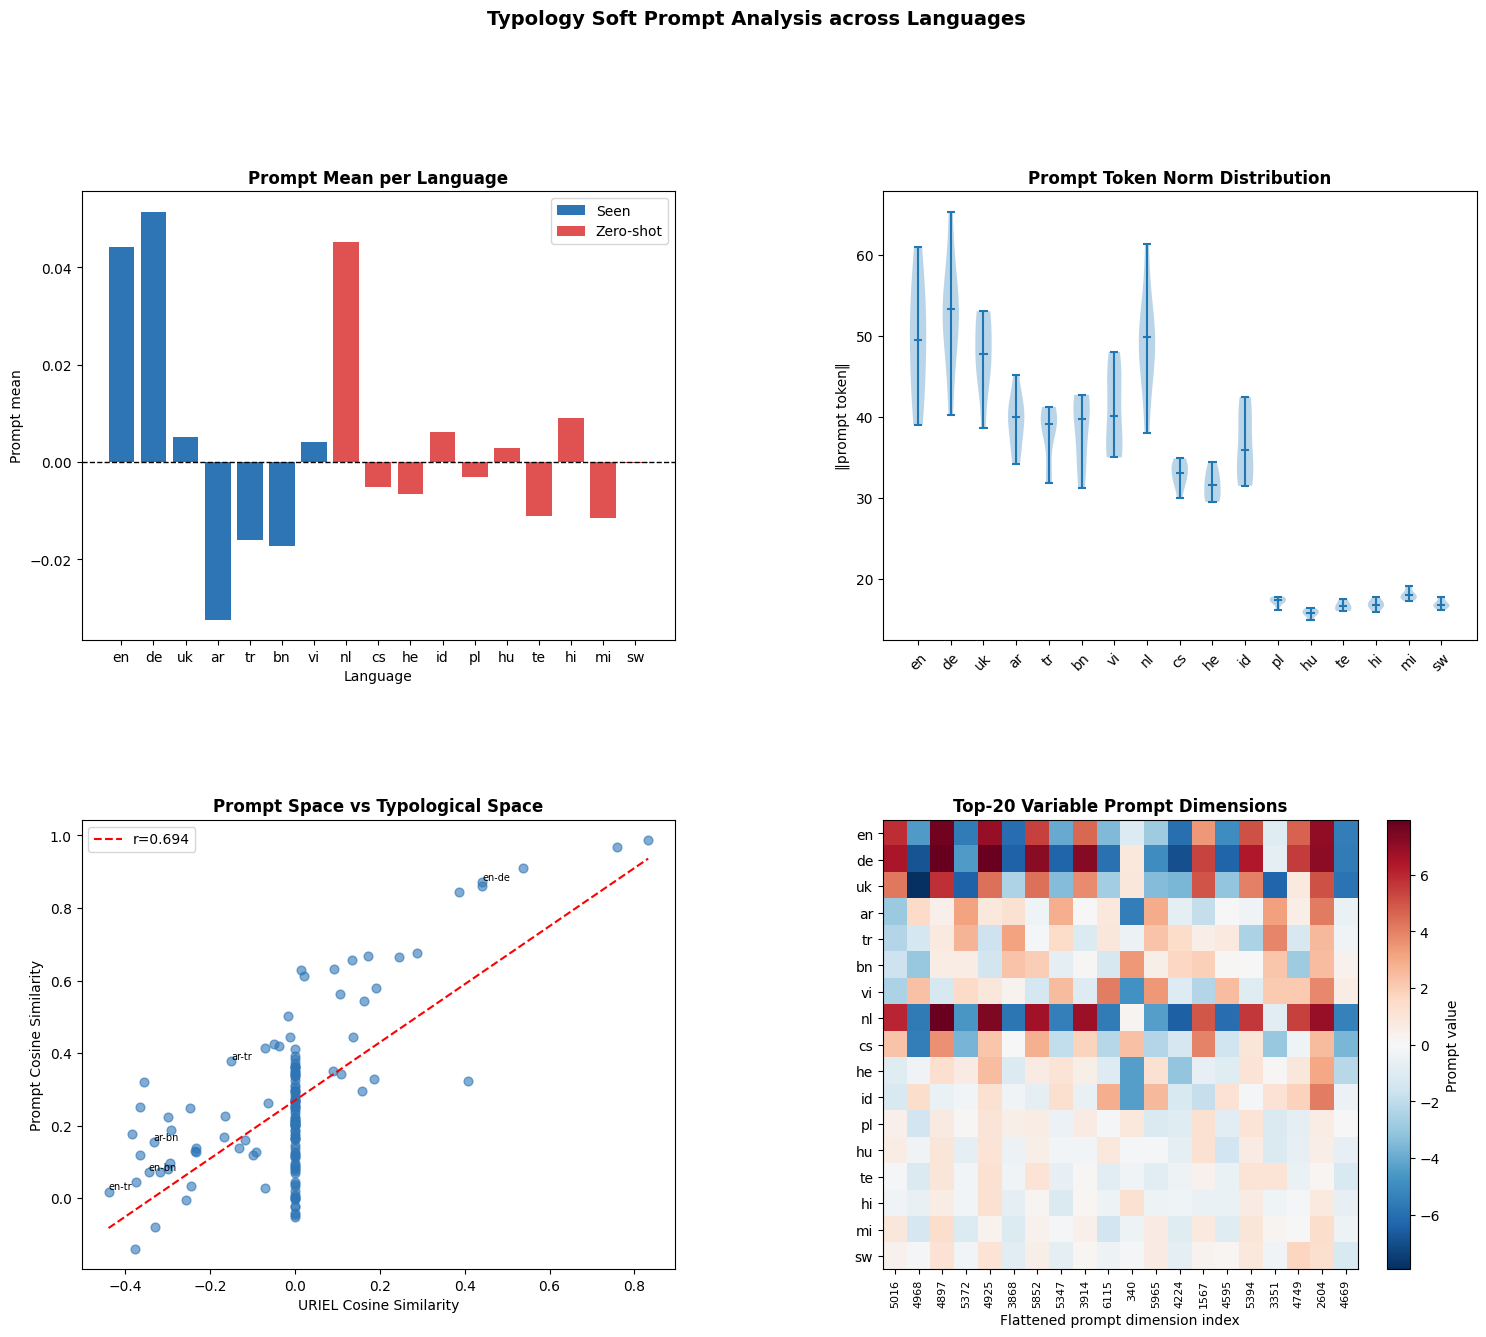


✅ Prompt analysis complete | Figure saved to /content/drive/MyDrive/MLP Project/MLP Group/my_checkpoints/prompt_analysis.png


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

ALL_ANALYSIS_LANGS = {
    "en": "English (seen)",   "de": "German (seen)",
    "uk": "Ukrainian (seen)", "ar": "Arabic (seen)",
    "tr": "Turkish (seen)",   "bn": "Bengali (seen)",
    "vi": "Vietnamese (seen)",
    "nl": "Dutch (zero)",     "cs": "Czech (zero)",
    "he": "Hebrew (zero)",    "id": "Indonesian (zero)",
    "pl": "Polish (zero)",    "hu": "Hungarian (zero)",
    "te": "Telugu (zero)",    "hi": "Hindi (zero)",
    "mi": "Maori (zero)",     "sw": "Swahili (zero)",
}

SEEN = ["en", "de", "uk", "ar", "tr", "bn", "vi"]
ZERO = ["nl", "cs", "pl", "he", "hu", "te", "hi", "id", "mi", "sw"]

# draw all
PLOT_LANGS = [l for l in ALL_ANALYSIS_LANGS if l in LANG_TYPO_VECS]

# ── Extract prompt representations ───────────────────────────────────────────
prompt_generator.eval()
prompt_tensors = {}
prompt_flat = {}

with torch.no_grad():
    for lang in ALL_ANALYSIS_LANGS:
        if lang not in LANG_TYPO_VECS:
            print(f"  Skipping {lang} — no URIEL vector")
            continue

        uv = LANG_TYPO_VECS[lang].unsqueeze(0).to(device)   # (1, 103)
        p = prompt_generator(uv).squeeze(0).cpu()           # (prompt_len, 768)

        prompt_tensors[lang] = p
        prompt_flat[lang] = p.flatten().numpy()             # (prompt_len*768,)

print(f"Extracted prompts for {len(prompt_tensors)} languages\n")

# ── 1. Summary statistics ────────────────────────────────────────────────────
print("── 1. Prompt Summary Statistics ─────────────────────────────────────")
print(f"{'Lang':<6} {'mean':>8} {'std':>8} {'min':>8} {'max':>8} {'avg‖p‖':>10}")
print("─" * 60)

for lang, label in ALL_ANALYSIS_LANGS.items():
    if lang not in prompt_tensors:
        continue
    p = prompt_tensors[lang].numpy()      # (P, 768)
    token_norms = np.linalg.norm(p, axis=1)
    tag = "(seen)" if lang in SEEN else "(zero)"
    print(
        f"{lang:<6} {p.mean():>8.4f} {p.std():>8.4f} {p.min():>8.4f} "
        f"{p.max():>8.4f} {token_norms.mean():>10.4f}  {tag}"
    )

# ── 2. Pairwise cosine similarity of prompt vectors ─────────────────────────
print("\n── 2. Pairwise Cosine Similarity of Prompt Vectors ─────────────────")
plot_langs_avail = [l for l in PLOT_LANGS if l in prompt_flat]

prompt_matrix = np.stack([prompt_flat[l] for l in plot_langs_avail])   # (L, P*768)
prompt_tensor = torch.tensor(prompt_matrix, dtype=torch.float32)

sim_matrix = F.cosine_similarity(
    prompt_tensor.unsqueeze(1), prompt_tensor.unsqueeze(0), dim=2
).numpy()

print(f"{'':>6}", end="")
for l in plot_langs_avail:
    print(f"{l:>7}", end="")
print()

for i, l1 in enumerate(plot_langs_avail):
    print(f"{l1:<6}", end="")
    for j in range(len(plot_langs_avail)):
        print(f"{sim_matrix[i, j]:>7.3f}", end="")
    print()

# ── 3. Prompt similarity vs URIEL similarity ────────────────────────────────
print("\n── 3. Prompt Similarity vs URIEL Similarity ───────────────────────")

uriel_matrix = np.stack([
    LANG_TYPO_VECS[l].numpy() for l in plot_langs_avail
])
uriel_tensor = torch.tensor(uriel_matrix, dtype=torch.float32)

uriel_sim = F.cosine_similarity(
    uriel_tensor.unsqueeze(1), uriel_tensor.unsqueeze(0), dim=2
).numpy()

n = len(plot_langs_avail)
prompt_sims = []
uriel_sims = []
pairs = []

for i in range(n):
    for j in range(i + 1, n):
        prompt_sims.append(sim_matrix[i, j])
        uriel_sims.append(uriel_sim[i, j])
        pairs.append(f"{plot_langs_avail[i]}-{plot_langs_avail[j]}")

prompt_sims = np.array(prompt_sims)
uriel_sims = np.array(uriel_sims)

corr = np.corrcoef(prompt_sims, uriel_sims)[0, 1]
print(f"\nPearson r = {corr:.4f}")
print("(+1 = prompt space strongly reflects typological similarity, 0 = no relationship)")

diffs = np.abs(prompt_sims - uriel_sims)
sorted_pairs = sorted(zip(diffs, pairs, prompt_sims, uriel_sims))

print("\nMost aligned pairs (prompt_sim ≈ URIEL_sim):")
for diff, pair, ps, us in sorted_pairs[:5]:
    print(f"  {pair:<14} prompt={ps:.3f}  URIEL={us:.3f}  diff={diff:.3f}")

print("\nLeast aligned pairs:")
for diff, pair, ps, us in sorted_pairs[-5:]:
    print(f"  {pair:<14} prompt={ps:.3f}  URIEL={us:.3f}  diff={diff:.3f}")

# ── 4. Top variable prompt dimensions ────────────────────────────────────────
print("\n── 4. Top Prompt Dimensions by Cross-Language Variance ─────────────")

prompt_var = prompt_matrix.var(axis=0)
top_dims = np.argsort(prompt_var)[::-1][:20]

print("\nMean absolute value on top-20 variable prompt dimensions:")
for lang in plot_langs_avail:
    vals = prompt_flat[lang][top_dims]
    magnitude = np.abs(vals).mean()
    tag = "(seen)" if lang in SEEN else "(zero)"
    print(f"  {lang:<6} {magnitude:.4f}  {tag}")

# ── 5. Four-panel figure ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Panel 1: prompt mean per language
ax1 = fig.add_subplot(gs[0, 0])
means = [prompt_tensors[l].numpy().mean() for l in plot_langs_avail]
colors = ["#2E75B6" if l in SEEN else "#E05252" for l in plot_langs_avail]

ax1.bar(plot_langs_avail, means, color=colors)
ax1.axhline(0.0, color="black", linestyle="--", linewidth=1)
ax1.set_title("Prompt Mean per Language", fontweight="bold")
ax1.set_ylabel("Prompt mean")
ax1.set_xlabel("Language")
ax1.legend(handles=[
    Patch(facecolor="#2E75B6", label="Seen"),
    Patch(facecolor="#E05252", label="Zero-shot"),
])

# Panel 2: prompt token norm distribution
ax2 = fig.add_subplot(gs[0, 1])
data_norms = [np.linalg.norm(prompt_tensors[l].numpy(), axis=1) for l in plot_langs_avail]
ax2.violinplot(data_norms, positions=range(len(plot_langs_avail)), showmedians=True)
ax2.set_xticks(range(len(plot_langs_avail)))
ax2.set_xticklabels(plot_langs_avail, rotation=45)
ax2.set_title("Prompt Token Norm Distribution", fontweight="bold")
ax2.set_ylabel("‖prompt token‖")

# Panel 3: prompt space vs typological space
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(uriel_sims, prompt_sims, alpha=0.6, color="#2E75B6", s=40)

z = np.polyfit(uriel_sims, prompt_sims, 1)
x_line = np.linspace(uriel_sims.min(), uriel_sims.max(), 100)
ax3.plot(x_line, np.poly1d(z)(x_line), "r--", linewidth=1.5, label=f"r={corr:.3f}")

ax3.set_xlabel("URIEL Cosine Similarity")
ax3.set_ylabel("Prompt Cosine Similarity")
ax3.set_title("Prompt Space vs Typological Space", fontweight="bold")
# ax3.legend()

# 可选标注一些 pair
for i, pair in enumerate(pairs):
    l1, l2 = pair.split("-")
    if l1 in ["en", "ar"] and l2 in ["de", "tr", "bn"]:
        ax3.annotate(pair, (uriel_sims[i], prompt_sims[i]),
                     fontsize=20, ha="left", va="bottom")

# Panel 4: top variable prompt dimensions heatmap
ax4 = fig.add_subplot(gs[1, 1])
heatmap_data = np.stack([prompt_flat[l][top_dims[:20]] for l in plot_langs_avail])

im = ax4.imshow(
    heatmap_data,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-np.max(np.abs(heatmap_data)),
    vmax=np.max(np.abs(heatmap_data)),
)

ax4.set_xticks(range(20))
ax4.set_xticklabels([str(d) for d in top_dims[:20]], rotation=90, fontsize=8)
ax4.set_yticks(range(len(plot_langs_avail)))
ax4.set_yticklabels(plot_langs_avail)
ax4.set_title("Top-20 Variable Prompt Dimensions", fontweight="bold")
ax4.set_xlabel("Flattened prompt dimension index")
plt.colorbar(im, ax=ax4, label="Prompt value")

plt.suptitle(
    "Typology Soft Prompt Analysis across Languages",
    fontsize=14,
    fontweight="bold",
    y=1.01
)

save_path = os.path.join(SAVE_DIR, "prompt_analysis.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPrompt analysis complete | Figure saved to {save_path}")

The above info show that typology-conditioned prompts do capture linguistic structure, but their effect is very limited.

First, we can observe a strong correlation (r = 0.694) between prompt similarity and URIEL typological similarity --> the learned prompt space reflects real linguistic relationships. For example, similar languages such as English–German (0.871) and Arabic–Hebrew (0.845) have high prompt similarity.

However, this effect is not consistent across all languages. Some unrelated pairs (e.g., Vietnamese–Indonesian = 0.969) show unexpectedly high similarity. This mean the model may also be influenced by training data bias.

The above pics also suggests that typology signals are weaker and less expressive for unseen languages --> There's a key difference appears between seen and zero-shot languages. Seen languages have much larger prompt norms (e.g., ~50 for English/German), while many zero-shot languages are significantly smaller (e.g., ~16–18 for Hindi, Swahili).

These situations can suggest that:
- Typology is clearly encoded in the prompt representations
- But it is not fully utilized, especially for zero-shot languages
- The decoder likely relies more on learned embeddings than typology